In [1]:
import rioxarray as rio
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import geopandas as gpd
import os

# **Input Variables Data**

In [2]:
# NO2 VCD
# Path Data Time Series NO2 VCD
no2_vcd_path = r'D:\Kuliah UNDIP\Semester 7\TA\DATA TA\DATA_DRIVE\Data\Raster\Daily NO2 TROPOMI' 
no2_vcd_files = glob.glob(os.path.join(no2_vcd_path, 'no2_*.tif'))
no2_vcd_files.sort()


# Read All NO2 VCD
no2_vcd_dataset = []
for file in no2_vcd_files:
    data_no2_vcd = rio.open_rasterio(file)
    no2_vcd_dataset.append(data_no2_vcd)

# Extract Date
dates = [file.split('no2_')[-1].replace('.tif', '') for file in no2_vcd_files]
time_no2= pd.to_datetime(dates, format='%Y_%m_%d')

# Combined Dataset to Xarray
no2_vcd = xr.concat(no2_vcd_dataset, dim='time').squeeze('band')
no2_vcd['time'] = time_no2

# View generate metadata associated with the raster file
print("Bounding Box:", no2_vcd.rio.bounds())
print("The crs of your data is:", no2_vcd.rio.crs)
print("The nodatavalue of your data is:", no2_vcd.rio.nodata)
print("The shape of your data is:", no2_vcd.shape)
print("The spatial resolution for your data is:", no2_vcd.rio.resolution())
print("The metadata for your data is:", no2_vcd.attrs)


Bounding Box: (412997.2, 9210616.800000003, 449732.8, 9240673.200000001)
The crs of your data is: PROJCS["WGS 84 / UTM zone 49S",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",111],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
The nodatavalue of your data is: None
The shape of your data is: (181, 27, 33)
The spatial resolution for your data is: (1113.2, -1113.2)
The metadata for your data is: {'AREA_OR_POINT': 'Area', 'scale_factor': 1.0, 'add_offset': 0.0, 'long_name': 'tropospheric_NO2_column_number_density'}


In [3]:
# CAMS NO2
cams_path = r'D:\Kuliah UNDIP\Semester 7\TA\DATA TA\DATA_DRIVE\Data\Raster\CAMS\no2_cams_*.tif'
cams_files = glob.glob(cams_path)
cams_files.sort()

# Read All CAMS NO2
cams_dataset = []
for file in cams_files:
    data_cams = xr.open_dataset(file)
    cams_dataset.append(data_cams)

# Extract Date
cams_dates = [file.split('no2_cams_')[-1].replace('.tif', '') for file in cams_files]
cams_time = pd.to_datetime(cams_dates, format='%Y_%m_%d')

# Combined Dataset to Xarray
cams_no2 = xr.concat(cams_dataset, dim='time').squeeze('band')
cams_no2['time'] = cams_time

# Convert Unit CAMS
molecular_weight_no2 = 0.046005   # kg/mol
no2_cams_converted = cams_no2['band_data'] / molecular_weight_no2

# Aligning the spatial dimensions of CAMS NO2 with NO2 VCD
cams_no2_resampled = no2_cams_converted.rio.reproject_match(no2_vcd)

# View generate metadata associated with the raster file
print("Bounding Box:", cams_no2_resampled.rio.bounds())
print("The crs of your data is:", cams_no2_resampled.rio.crs)
print("The shape of your data is:", cams_no2_resampled.shape)
print("The spatial resolution for your data is:", cams_no2_resampled.rio.resolution())
print("The metadata for your data is:", cams_no2_resampled.attrs)

cams_no2_resampled.isel(time=4)

Bounding Box: (412997.2, 9210616.800000003, 449732.8, 9240673.200000001)
The crs of your data is: PROJCS["WGS 84 / UTM zone 49S",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",111],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
The shape of your data is: (181, 27, 33)
The spatial resolution for your data is: (1113.2000000000007, -1113.1999999999714)
The metadata for your data is: {'AREA_OR_POINT': 'Area', 'STATISTICS_MAXIMUM': 7.912471119198e-06, 'STATISTICS_MEAN': 7.5413567967145e-06, 'STATISTICS_MINIMUM': 7.1619774644205e-06, 'STATISTICS_STDDEV': 1.6911097334381e-07, 'STATISTICS_VALID_PERCENT': 92.03, 'long_name': 'no2_cam

<xarray.DataArray 'band_data' (y: 27, x: 33)> Size: 4kB
array([[       nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan],
       [0.00018971, 0.00019066, 0.00019161, 0.00019256, 0.00019351,
        0.00019446, 0.00019541, 0.00019636, 0.00019731, 0.00019826,
        0.00019921, 0.00020016, 0.00020111, 0.00020206, 0.00020301,
        0.00020396, 0.00020491, 0.00020586, 0.00020681, 0.00020776,
        0.00020871, 0.00020966, 0.00021061, 0.00021156, 0.00021251,
        0.00021346, 0.00021441, 0.00021536, 0.00021631, 0.00021603,
        0.00021571, 0.00021539, 0.00021506],
       [0.00018859, 0.00018952, 0.00019046, 0.0001914 , 0.00019234,
        0.00019327, 0.00019421, 0.00019515, 0.00019608, 0.00019702,
        0.00019796, 0.0001989 , 0.00019983, 0.00020077, 0.00020171,
        0.00020264, 0.00020358, 0.00020452, 0.00020546, 0.00020639,
        0.00020733, 0.00020827, 0.0002092 , 0.00021014, 0.00021108,
        0.00021202, 0.00021295, 0.00021389, 0.00021483, 0.00021455,
...
        0.00016712, 0.00016777, 0.00016843, 0.00016908, 0.00016974,
        0.00017039, 0.00017104, 0.0001717 , 0.00017235, 0.00017301,
        0.00017366, 0.00017431, 0.00017497, 0.00017562, 0.00017628,
        0.00017693, 0.00017758, 0.00017824, 0.00017889, 0.00017955,
        0.0001802 , 0.00018085, 0.00018151, 0.00018216, 0.00018202,
        0.00018182, 0.00018163, 0.00018144],
       [       nan, 0.00016337, 0.00016401, 0.00016465, 0.00016529,
        0.00016593, 0.00016657, 0.00016721, 0.00016785, 0.0001685 ,
        0.00016914, 0.00016978, 0.00017042, 0.00017106, 0.0001717 ,
        0.00017234, 0.00017298, 0.00017362, 0.00017427, 0.00017491,
        0.00017555, 0.00017619, 0.00017683, 0.00017747, 0.00017811,
        0.00017875, 0.00017939, 0.00018004, 0.00018068, 0.00018054,
        0.00018035, 0.00018016, 0.00017998],
       [       nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan,        nan,        nan,
               nan,        nan,        nan]], dtype=float32)
Coordinates:
  * y            (y) float64 216B 9.24e+06 9.239e+06 ... 9.212e+06 9.211e+06
  * x            (x) float64 264B 4.136e+05 4.147e+05 ... 4.481e+05 4.492e+05
    band         int64 8B 1
    time         datetime64[ns] 8B 2025-01-05
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:             Area
    STATISTICS_MAXIMUM:        7.912471119198e-06
    STATISTICS_MEAN:           7.5413567967145e-06
    STATISTICS_MINIMUM:        7.1619774644205e-06
    STATISTICS_STDDEV:         1.6911097334381e-07
    STATISTICS_VALID_PERCENT:  92.03
    long_name:                 no2_cams
    _FillValue:                nan

In [4]:
import glob
# Time reference to NO2 VCD
time_reference = no2_vcd.time.values

# Meteorology
# Total Percipitation (tp)
# Path Data Time Series tp
tp_path = r"D:\Kuliah UNDIP\Semester 7\TA\DATA TA\DATA_DRIVE\Data\Raster\PRECIPITATION\tp_*"
tp_files = glob.glob(tp_path)
tp_files.sort()

# Read All tp
tp_dataset = []
for file in tp_files:
    data_tp= rio.open_rasterio(file)
    tp_dataset.append(data_tp)

tp_dates = [file.split('tp_')[-1].replace('.tif', '') for file in tp_files]
tp_time = pd.to_datetime(tp_dates, format='%Y_%m_%d')  # FIX: nama variabel spesifik
 
tp = xr.concat(tp_dataset, dim='time').squeeze('band')
tp['time'] = tp_time
tp_resampled = tp.rio.reproject_match(no2_vcd)

# View generate metadata associated with the raster file
print("Bounding Box:", tp.rio.bounds())
print("The crs of your data is:", tp.rio.crs)
print("The nodatavalue of your data is:", tp.rio.nodata)
print("The shape of your data is:", tp.shape)
print("The spatial resolution for your data is:", tp.rio.resolution())
print("The metadata for your data is:", tp.attrs)


Bounding Box: (412997.2, 9210616.800000003, 449732.8, 9240673.200000001)
The crs of your data is: PROJCS["WGS 84 / UTM zone 49S",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",111],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
The nodatavalue of your data is: None
The shape of your data is: (181, 27, 33)
The spatial resolution for your data is: (1113.2, -1113.2)
The metadata for your data is: {'AREA_OR_POINT': 'Area', 'scale_factor': 1.0, 'add_offset': 0.0, 'long_name': 'tp'}


In [5]:
# Humidity (h)
# Path Data Time Series h
h_path = r"D:\Kuliah UNDIP\Semester 7\TA\DATA TA\DATA_DRIVE\Data\Raster\HUMIDITY\h_*"
h_files = glob.glob(h_path)
h_files.sort()

# Read All h
h_dataset = []
for file in h_files:
    data_h= rio.open_rasterio(file)
    h_dataset.append(data_h)

h_dates = [file.split('h_')[-1].replace('.tif', '') for file in h_files]
h_time = pd.to_datetime(h_dates, format='%Y_%m_%d')  # FIX: nama variabel spesifik
 
h = xr.concat(h_dataset, dim='time').squeeze('band')
h['time'] = h_time
h_resampled = h.rio.reproject_match(no2_vcd)

# View generate metadata associated with the raster file
print("Bounding Box:", h.rio.bounds())
print("The crs of your data is:", h.rio.crs)
print("The nodatavalue of your data is:", h.rio.nodata)
print("The shape of your data is:", h.shape)
print("The spatial resolution for your data is:", h.rio.resolution())
print("The metadata for your data is:", h.attrs)

print(h.isel(time=0).values)

Bounding Box: (412997.2, 9210616.800000003, 449732.8, 9240673.200000001)
The crs of your data is: PROJCS["WGS 84 / UTM zone 49S",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",111],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
The nodatavalue of your data is: None
The shape of your data is: (181, 27, 33)
The spatial resolution for your data is: (1113.2, -1113.2)
The metadata for your data is: {'AREA_OR_POINT': 'Area', 'scale_factor': 1.0, 'add_offset': 0.0, 'long_name': 'h'}
[[        nan         nan         nan         nan         nan         nan
          nan         nan         nan         nan         nan         nan
   

In [6]:
 # Temperature (temp)
 # Path Data Time Series temp
temp_path = r"D:\Kuliah UNDIP\Semester 7\TA\DATA TA\DATA_DRIVE\Data\Raster\TEMPERATURE\temp_*"
temp_files = glob.glob(temp_path)
temp_files.sort()

# Read All h
temp_dataset = []
for file in temp_files:
    data_temp= rio.open_rasterio(file)
    temp_dataset.append(data_temp)

temp_dates = [file.split('temp_')[-1].replace('.tif', '') for file in temp_files]
temp_time = pd.to_datetime(temp_dates, format='%Y_%m_%d')  # FIX
 
temp = xr.concat(temp_dataset, dim='time').squeeze('band')
temp['time'] = temp_time
temp_resampled = temp.rio.reproject_match(no2_vcd)

# View generate metadata associated with the raster file
print("Bounding Box:", temp.rio.bounds())
print("The crs of your data is:", temp.rio.crs)
print("The nodatavalue of your data is:", temp.rio.nodata)
print("The shape of your data is:", temp_resampled.shape)
print("The spatial resolution for your data is:", temp.rio.resolution())
print("The metadata for your data is:", temp.attrs)

Bounding Box: (412997.2, 9210616.800000003, 449732.8, 9240673.200000001)
The crs of your data is: PROJCS["WGS 84 / UTM zone 49S",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",111],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
The nodatavalue of your data is: None
The shape of your data is: (181, 27, 33)
The spatial resolution for your data is: (1113.2, -1113.2)
The metadata for your data is: {'AREA_OR_POINT': 'Area', 'scale_factor': 1.0, 'add_offset': 0.0, 'long_name': 'temp'}


In [7]:
# Solar Radiance (sr)
# Path Data Time Series sr
sr_path = r"D:\Kuliah UNDIP\Semester 7\TA\DATA TA\DATA_DRIVE\Data\Raster\SOLAR\sr_*"
sr_files = glob.glob(sr_path)
sr_files.sort()

# Read All sr
sr_dataset = []
for file in sr_files:
    data_sr= rio.open_rasterio(file)
    sr_dataset.append(data_sr)

sr_dates = [file.split('sr_')[-1].replace('.tif', '') for file in sr_files]
sr_time = pd.to_datetime(sr_dates, format='%Y_%m_%d')  # FIX
 
sr = xr.concat(sr_dataset, dim='time').squeeze('band')
sr['time'] = sr_time
sr_resampled = sr.rio.reproject_match(no2_vcd)

# View generate metadata associated with the raster file
print("Bounding Box:", sr.rio.bounds())
print("The crs of your data is:", sr.rio.crs)
print("The nodatavalue of your data is:", sr.rio.nodata)
print("The shape of your data is:", sr.shape)
print("The spatial resolution for your data is:", sr.rio.resolution())
print("The metadata for your data is:", sr.attrs)


Bounding Box: (412997.2, 9210616.800000003, 449732.8, 9240673.200000001)
The crs of your data is: PROJCS["WGS 84 / UTM zone 49S",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",111],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
The nodatavalue of your data is: None
The shape of your data is: (181, 27, 33)
The spatial resolution for your data is: (1113.2, -1113.2)
The metadata for your data is: {'AREA_OR_POINT': 'Area', 'scale_factor': 1.0, 'add_offset': 0.0, 'long_name': 'sr'}


In [8]:
 # Wind Speed (ws)
 # Path Data Time Series ws
ws_path = r"D:\Kuliah UNDIP\Semester 7\TA\DATA TA\DATA_DRIVE\Data\Raster\WINDSPEED\ws_*"
ws_files = glob.glob(ws_path)
ws_files.sort()

# Read All ws
ws_dataset = []
for file in ws_files:
    data_ws= rio.open_rasterio(file)
    ws_dataset.append(data_ws)

ws_dates = [file.split('ws_')[-1].replace('.tif', '') for file in ws_files]
ws_time = pd.to_datetime(ws_dates, format='%Y_%m_%d')  # FIX
 
ws = xr.concat(ws_dataset, dim='time').squeeze('band')
ws['time'] = ws_time
ws_resampled = ws.rio.reproject_match(no2_vcd)

# View generate metadata associated with the raster file
print("Bounding Box:", ws.rio.bounds())
print("The crs of your data is:", ws.rio.crs)
print("The nodatavalue of your data is:", ws.rio.nodata)
print("The shape of your data is:", ws.shape)
print("The spatial resolution for your data is:", ws.rio.resolution())
print("The metadata for your data is:", ws.attrs)

Bounding Box: (412997.2, 9210616.800000003, 449732.8, 9240673.200000001)
The crs of your data is: PROJCS["WGS 84 / UTM zone 49S",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",111],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
The nodatavalue of your data is: None
The shape of your data is: (181, 27, 33)
The spatial resolution for your data is: (1113.2, -1113.2)
The metadata for your data is: {'AREA_OR_POINT': 'Area', 'scale_factor': 1.0, 'add_offset': 0.0, 'long_name': 'ws'}


In [9]:
 # Wind Direction (wd)
# Path Data Time Series wd
wd_path = r"D:\Kuliah UNDIP\Semester 7\TA\DATA TA\DATA_DRIVE\Data\Raster\WINDDIRECTION\wd_*"
wd_files = glob.glob(wd_path)
wd_files.sort()

# Read All wd
wd_dataset = []
for file in wd_files:
    data_wd= rio.open_rasterio(file)
    wd_dataset.append(data_wd)

wd_dates = [file.split('wd_')[-1].replace('.tif', '') for file in wd_files]
wd_time = pd.to_datetime(wd_dates, format='%Y_%m_%d')  # FIX
 
wd = xr.concat(wd_dataset, dim='time').squeeze('band')
wd['time'] = wd_time
wd_resampled = wd.rio.reproject_match(no2_vcd)

# View generate metadata associated with the raster file
print("Bounding Box:", wd.rio.bounds())
print("The crs of your data is:", wd.rio.crs)
print("The nodatavalue of your data is:", wd.rio.nodata)
print("The shape of your data is:", wd.shape)
print("The spatial resolution for your data is:", wd.rio.resolution())
print("The metadata for your data is:", wd.attrs)

Bounding Box: (412997.2, 9210616.800000003, 449732.8, 9240673.200000001)
The crs of your data is: PROJCS["WGS 84 / UTM zone 49S",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",111],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
The nodatavalue of your data is: None
The shape of your data is: (181, 27, 33)
The spatial resolution for your data is: (1113.2, -1113.2)
The metadata for your data is: {'AREA_OR_POINT': 'Area', 'scale_factor': 1.0, 'add_offset': 0.0, 'long_name': 'wd'}


In [10]:
# PBLH (pb)
# Path Data Time Series pb
pb_path = r"D:\Kuliah UNDIP\Semester 7\TA\DATA TA\DATA_DRIVE\Data\Raster\PBLH\pb_*"
pb_files = glob.glob(pb_path)
pb_files.sort()

# Read All pb
pb_dataset = []
for file in pb_files:
    data_pb= rio.open_rasterio(file)
    pb_dataset.append(data_pb)

pb_dates = [file.split('pb_')[-1].replace('.tif', '') for file in pb_files]
pb_time = pd.to_datetime(pb_dates, format='%Y_%m_%d')  # FIX
 
pb = xr.concat(pb_dataset, dim='time').squeeze('band')
pb['time'] = pb_time
pb_resampled = pb.rio.reproject_match(no2_vcd)

# View generate metadata associated with the raster file
print("Bounding Box:", pb.rio.bounds())
print("The crs of your data is:", pb.rio.crs)
print("The nodatavalue of your data is:", pb.rio.nodata)
print("The shape of your data is:", pb.shape)
print("The spatial resolution for your data is:", pb.rio.resolution())
print("The metadata for your data is:", pb.attrs)

Bounding Box: (412997.2, 9210616.800000003, 449732.8, 9240673.200000001)
The crs of your data is: PROJCS["WGS 84 / UTM zone 49S",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",111],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
The nodatavalue of your data is: None
The shape of your data is: (181, 27, 33)
The spatial resolution for your data is: (1113.2, -1113.2)
The metadata for your data is: {'AREA_OR_POINT': 'Area', 'scale_factor': 1.0, 'add_offset': 0.0, 'long_name': 'pb'}


In [11]:
 # Pressure (ps)
 # Path Data Time Series ps
ps_path = r"D:\Kuliah UNDIP\Semester 7\TA\DATA TA\DATA_DRIVE\Data\Raster\PRESSURE\ps_*"
ps_files = glob.glob(ps_path)
ps_files.sort()

# Read All ws
ps_dataset = []
for file in ps_files:
    data_ps= rio.open_rasterio(file)
    ps_dataset.append(data_ps)

ps_dates = [file.split('ps_')[-1].replace('.tif', '') for file in ps_files]
ps_time = pd.to_datetime(ps_dates, format='%Y_%m_%d')  # FIX
 
ps = xr.concat(ps_dataset, dim='time').squeeze('band')
ps['time'] = ps_time
ps_resampled = ps.rio.reproject_match(no2_vcd)

# View generate metadata associated with the raster file
print("Bounding Box:", ps.rio.bounds())
print("The crs of your data is:", ps.rio.crs)
print("The nodatavalue of your data is:", ps.rio.nodata)
print("The shape of your data is:", ps.shape)
print("The spatial resolution for your data is:", ps.rio.resolution())
print("The metadata for your data is:", ps.attrs)

Bounding Box: (412997.2, 9210616.800000003, 449732.8, 9240673.200000001)
The crs of your data is: PROJCS["WGS 84 / UTM zone 49S",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",111],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
The nodatavalue of your data is: None
The shape of your data is: (181, 27, 33)
The spatial resolution for your data is: (1113.2, -1113.2)
The metadata for your data is: {'AREA_OR_POINT': 'Area', 'scale_factor': 1.0, 'add_offset': 0.0, 'long_name': 'ps'}


In [12]:
# DEM
dem_path = r"D:\Kuliah UNDIP\Semester 7\TA\DATA TA\DATA_DRIVE\Data\Raster\DEM\dem_m.tif"

dem = rio.open_rasterio(dem_path)

# Align DEM
dem_resampled = dem.rio.reproject_match(no2_vcd).squeeze('band')

# Broadcasting Time-Series DEM
dem_broadcasted = xr.concat([dem_resampled] * len(time_reference), dim='time')
dem_broadcasted['time'] = time_reference

# View generate metadata associated with the raster file
print("Bounding Box:", dem_broadcasted.rio.bounds())
print("The crs of your data is:", dem_broadcasted.rio.crs)
print("The nodatavalue of your data is:", dem_broadcasted.rio.nodata)
print("The shape of your data is:", dem_broadcasted.shape)
print("The spatial resolution for your data is:", dem_broadcasted.rio.resolution())
print("The metadata for your data is:", dem_broadcasted.attrs)

Bounding Box: (412997.2, 9210616.800000003, 449732.8, 9240673.200000001)
The crs of your data is: PROJCS["WGS 84 / UTM zone 49S",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",111],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
The nodatavalue of your data is: -32768
The shape of your data is: (181, 27, 33)
The spatial resolution for your data is: (1113.2000000000007, -1113.1999999999714)
The metadata for your data is: {'DataType': 'Generic', 'AREA_OR_POINT': 'Area', 'RepresentationType': 'THEMATIC', 'scale_factor': 1.0, 'add_offset': 0.0, '_FillValue': np.int16(-32768)}


In [13]:
# Population Density
pop_path = r"D:\Kuliah UNDIP\Semester 7\TA\DATA TA\DATA_DRIVE\Data\Raster\DENSITY\popdensity.tif"

pop = rio.open_rasterio(pop_path)

# Align Pop
pop_resampled = pop.rio.reproject_match(no2_vcd).squeeze('band')

# Broadcasting Time-Series Pop
pop_broadcasted = xr.concat([pop_resampled] * len(time_reference), dim='time')
pop_broadcasted['time'] = time_reference

print("Bounding Box:", pop_broadcasted.rio.bounds())
print("The crs of your data is:", pop_broadcasted.rio.crs)
print("The nodatavalue of your data is:", pop_broadcasted.rio.nodata)
print("The shape of your data is:", pop_broadcasted.shape)
print("The spatial resolution for your data is:", pop_broadcasted.rio.resolution())
print("The metadata for your data is:", pop_broadcasted.attrs)

Bounding Box: (412997.2, 9210616.800000003, 449732.8, 9240673.200000001)
The crs of your data is: PROJCS["WGS 84 / UTM zone 49S",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",111],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
The nodatavalue of your data is: -3.4028235e+38
The shape of your data is: (181, 27, 33)
The spatial resolution for your data is: (1113.2000000000007, -1113.1999999999714)
The metadata for your data is: {'DataType': 'Generic', 'AREA_OR_POINT': 'Area', 'RepresentationType': 'ATHEMATIC', 'scale_factor': 1.0, 'add_offset': 0.0, '_FillValue': np.float32(-3.4028235e+38)}


In [14]:
# Road Density
road_path = r"D:\Kuliah UNDIP\Semester 7\TA\DATA TA\DATA_DRIVE\Data\Raster\DENSITY\roaddensity.tif"

road = rio.open_rasterio(road_path)

# Align Road
road_resampled = road.rio.reproject_match(no2_vcd).squeeze('band')

# Broadcasting Time-Series Road
road_broadcasted = xr.concat([road_resampled] * len(time_reference), dim='time')
road_broadcasted['time'] = time_reference

print("Bounding Box:", road_broadcasted.rio.bounds())
print("The crs of your data is:", road_broadcasted.rio.crs)
print("The nodatavalue of your data is:", road_broadcasted.rio.nodata)
print("The shape of your data is:", road_broadcasted.shape)
print("The spatial resolution for your data is:", road_broadcasted.rio.resolution())
print("The metadata for your data is:", road_broadcasted.attrs)

Bounding Box: (412997.2, 9210616.800000003, 449732.8, 9240673.200000001)
The crs of your data is: PROJCS["WGS 84 / UTM zone 49S",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",111],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
The nodatavalue of your data is: -3.4028235e+38
The shape of your data is: (181, 27, 33)
The spatial resolution for your data is: (1113.2000000000007, -1113.1999999999714)
The metadata for your data is: {'DataType': 'Generic', 'AREA_OR_POINT': 'Area', 'RepresentationType': 'ATHEMATIC', 'STATISTICS_MAXIMUM': 19.72279548645, 'STATISTICS_MEAN': 3.6605351481957, 'STATISTICS_MINIMUM': 0, 'STATISTICS_STDDEV

In [15]:
# Industry Density
industry_path = r"D:\Kuliah UNDIP\Semester 7\TA\DATA TA\DATA_DRIVE\Data\Raster\INDUSTRY\industrial5000.tif"

industry = rio.open_rasterio(industry_path)

# Align Industry
industry_resampled = industry.rio.reproject_match(no2_vcd).squeeze('band')

# Broadcasting Time-Series Industry
industry_broadcasted = xr.concat([industry_resampled] * len(time_reference), dim='time')
industry_broadcasted['time'] = time_reference

print("Bounding Box:", industry_broadcasted.rio.bounds())
print("The crs of your data is:", industry_broadcasted.rio.crs)
print("The nodatavalue of your data is:", industry_broadcasted.rio.nodata)
print("The shape of your data is:", industry_broadcasted.shape)
print("The spatial resolution for your data is:", industry_broadcasted.rio.resolution())
print("The metadata for your data is:", industry_broadcasted.attrs)

Bounding Box: (412997.2, 9210616.800000003, 449732.8, 9240673.200000001)
The crs of your data is: PROJCS["WGS 84 / UTM zone 49S",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",111],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
The nodatavalue of your data is: nan
The shape of your data is: (181, 27, 33)
The spatial resolution for your data is: (1113.2000000000007, -1113.1999999999714)
The metadata for your data is: {'AREA_OR_POINT': 'Area', 'RepresentationType': 'ATHEMATIC', 'scale_factor': 1.0, 'add_offset': 0.0, '_FillValue': nan}


In [16]:
# Land Cover
lc_path = r"D:\Kuliah UNDIP\Semester 7\TA\DATA TA\DATA_DRIVE\Data\Raster\LAND COVER\landcover.tif"
lc = rio.open_rasterio(lc_path)

# Align Land Cover
lc_resampled = lc.rio.reproject_match(no2_vcd).squeeze('band')

# Broadcasting Time-Series Land Cover
lc_broadcasted = xr.concat([lc_resampled] * len(time_reference), dim='time')
lc_broadcasted['time'] = time_reference

print("Bounding Box:", lc_broadcasted.rio.bounds())
print("The crs of your data is:", lc_broadcasted.rio.crs)
print("The nodatavalue of your data is:", lc_broadcasted.rio.nodata)
print("The shape of your data is:", lc_broadcasted.shape)
print("The spatial resolution for your data is:", lc_broadcasted.rio.resolution())
print("The metadata for your data is:", lc_broadcasted.attrs)


Bounding Box: (412997.2, 9210616.800000003, 449732.8, 9240673.200000001)
The crs of your data is: PROJCS["WGS 84 / UTM zone 49S",GEOGCS["WGS 84",DATUM["World Geodetic System 1984",SPHEROID["WGS 84",6378137,298.257223563]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",111],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]
The nodatavalue of your data is: 255
The shape of your data is: (181, 27, 33)
The spatial resolution for your data is: (1113.2000000000007, -1113.1999999999714)
The metadata for your data is: {'AREA_OR_POINT': 'Area', 'scale_factor': 1.0, 'add_offset': 0.0, '_FillValue': 255}


# **Data Master adn Pre-Processing**

In [17]:
# Aligned
tp_aligned = tp_resampled.reindex_like(no2_vcd)  # Menyelaraskan tp agar sesuai dengan no2_vcd
h_aligned = h_resampled.reindex_like(no2_vcd)
pb_aligned = pb_resampled.reindex_like(no2_vcd)
ps_aligned = ps_resampled.reindex_like(no2_vcd)
sr_aligned = sr_resampled.reindex_like(no2_vcd)
temp_aligned = temp_resampled.reindex_like(no2_vcd)
ws_aligned = ws_resampled.reindex_like(no2_vcd)
wd_aligned = wd_resampled.reindex_like(no2_vcd)
dem_aligned = dem_broadcasted.reindex_like(no2_vcd)
pop_aligned = pop_broadcasted.reindex_like(no2_vcd)
industry_aligned = industry_broadcasted.reindex_like(no2_vcd)
lc_aligned = lc_broadcasted.reindex_like(no2_vcd)
no2_cams_aligned = cams_no2_resampled.reindex_like(no2_vcd)

In [18]:
# Data Master
ds = xr.Dataset({
    'no2_vcd': no2_vcd, 'tp': tp_aligned, 'h': h_aligned, 'pb': pb_aligned,
    'ps': ps_aligned, 'sr': sr_aligned, 'temp': temp_aligned,'ws': ws_aligned,
    'wd': wd_aligned, 'dem': dem_aligned, 'pop': pop_aligned,
    'industry': industry_aligned, 'landcover': lc_aligned, 
    'no2_cams': no2_cams_aligned
})

print("Dataset Info:")
print(f"\nDimensi: {ds.dims}")
print(f"Koordinat: {list(ds.coords)}")

Dataset Info:

Dimensi: FrozenMappingWarningOnValuesAccess({'x': 33, 'y': 27, 'time': 181})
Koordinat: ['band', 'x', 'y', 'spatial_ref', 'time']


In [19]:
# Convert to DataFrame
# Stacking Spatial Dimension to Pixel
ds_stacked = ds.stack(pixel=('y', 'x'))
ds_stacked = ds_stacked.reset_index('pixel')

df = ds_stacked.to_dataframe().reset_index()
print(f"\nShape DataFrame: {df.shape}")
print(f"Kolom: {df.columns.tolist()}")
print(f"Unique pixel: {df['pixel'].nunique()}")


Shape DataFrame: (161271, 20)
Kolom: ['time', 'pixel', 'band', 'spatial_ref', 'no2_vcd', 'tp', 'h', 'pb', 'ps', 'sr', 'temp', 'ws', 'wd', 'dem', 'pop', 'industry', 'landcover', 'no2_cams', 'y', 'x']
Unique pixel: 891


In [20]:
# Format Datetime
df['time'] = pd.to_datetime(df['time'])

# Sort DataFrame by time and pixel
df = df.sort_values(by=['time', 'pixel']).reset_index(drop=True)
print(f"\nDataFrame setelah sorting:\n{df.head()}")


DataFrame setelah sorting:
        time  pixel  band  spatial_ref  no2_vcd  tp   h  pb  ps  sr  temp  ws  \
0 2025-01-01      0     1            0      NaN NaN NaN NaN NaN NaN   NaN NaN   
1 2025-01-01      1     1            0      NaN NaN NaN NaN NaN NaN   NaN NaN   
2 2025-01-01      2     1            0      NaN NaN NaN NaN NaN NaN   NaN NaN   
3 2025-01-01      3     1            0      NaN NaN NaN NaN NaN NaN   NaN NaN   
4 2025-01-01      4     1            0      NaN NaN NaN NaN NaN NaN   NaN NaN   

   wd  dem       pop  industry  landcover  no2_cams          y         x  
0 NaN    4  0.000353       0.0        255       NaN  9240116.6  413553.8  
1 NaN    3  0.000353       0.0        255       NaN  9240116.6  414667.0  
2 NaN    0  0.000353       0.0        255       NaN  9240116.6  415780.2  
3 NaN    0  0.000353       0.0        255       NaN  9240116.6  416893.4  
4 NaN    0  0.000353       0.0        255       NaN  9240116.6  418006.6  


# **Feature Engineering**

In [21]:
# Temporal Feature
df['month'] = df['time'].dt.month
df['day'] = df['time'].dt.day
df['dayofyear'] = df['time'].dt.dayofyear   
df['week'] = df['time'].dt.isocalendar().week   

# Cyclical Encoding
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['dayofyear_sin'] = np.sin(2 * np.pi * df['dayofyear'] / 365)
df['dayofyear_cos'] = np.cos(2 * np.pi * df['dayofyear'] / 365)

# Spatial Feature
if 'pixel' in df.columns:
   try:
      df[['y', 'x']] = df['pixel'].str.split('_', expand=True).astype(float)
   except:
      pass
   
# column lat(x) and lon(y)
if 'y' not in df.columns:
    # Ambil dari multiindex atau koordinat
    df['y'] = ds_stacked.lat.values
    df['x'] = ds_stacked.lon.values

# Spatial Interaction
df['y_x_interaction'] = df['y'] * df['x']
df['y_squared'] = df['y'] ** 2
df['x_squared'] = df['x'] ** 2

# Time Ordinal
df['time_ordinal'] = pd.to_datetime(df['time']).apply(lambda x: x.toordinal())

# CAMS Processing

In [22]:
# CAMS Check
# Missing Value Check
print(f"CAMS NaN: {df['no2_cams'].isna().sum()}")

if df['no2_cams'].isna().any():
         # Sort by pixel and time
    df_sorted = df.sort_values(['pixel', 'time'])
    
    # Linear pixel interpolation
    df['no2_cams_filled'] = (
        df_sorted.groupby('pixel')['no2_cams']
        .transform(lambda x: x.interpolate(method='linear', limit_direction='both'))
    )
    
    # fallback mean per month
    if df['no2_cams_filled'].isna().any():
        month_pixel_mean = df.groupby(['pixel', 'month'])['no2_cams'].transform('mean')
        df['no2_cams_filled'] = df['no2_cams_filled'].fillna(month_pixel_mean)
    
    # Jfallback mean global
    if df['no2_cams_filled'].isna().any():
        global_mean = df['no2_cams'].mean(skipna=True)
        df['no2_cams_filled'] = df['no2_cams_filled'].fillna(global_mean)
    
    print(f"no2_cams NaN setelah interpolasi: {df['no2_cams_filled'].isna().sum()}")
else:
    df['no2_cams_filled'] = df['no2_cams']
 
# CAMS climatology per month
df['no2_cams_climatology'] = df.groupby(['pixel', 'month'])['no2_cams_filled'].transform('mean')
 
# CAMS Anomaly
df['no2_cams_anomaly'] = df['no2_cams_filled'] - df['no2_cams_climatology']


CAMS NaN: 12851
no2_cams NaN setelah interpolasi: 0


# **Handling Categorical Variable**

In [23]:
# One Hot Encoding Landcover
from numpy import rint

df['landcover'] = df['landcover'].astype('category')
landcover_dummies = pd.get_dummies(df['landcover'], prefix='lc', drop_first=False)

# Merge Dataframe
df = pd.concat([df, landcover_dummies], axis=1)

print(f"Shape one-hot encoding: {df.shape}")
print(f"New column landcover: {landcover_dummies.columns.tolist()}")

df[landcover_dummies.columns].head()

Shape one-hot encoding: (161271, 45)
New column landcover: ['lc_2', 'lc_8', 'lc_9', 'lc_11', 'lc_12', 'lc_13', 'lc_14', 'lc_16', 'lc_17', 'lc_255']


,lc_2,lc_8,lc_9,lc_11,lc_12,lc_13,lc_14,lc_16,lc_17,lc_255
0,False,False,False,False,False,False,False,False,False,True
1,False,False,False,False,False,False,False,False,False,True
2,False,False,False,False,False,False,False,False,False,True
3,False,False,False,False,False,False,False,False,False,True
4,False,False,False,False,False,False,False,False,False,True


In [24]:
# Tampilkan nama-nama kolom dataframe
print(f"DataFrame Column: {df.columns.tolist()}")

DataFrame Column: ['time', 'pixel', 'band', 'spatial_ref', 'no2_vcd', 'tp', 'h', 'pb', 'ps', 'sr', 'temp', 'ws', 'wd', 'dem', 'pop', 'industry', 'landcover', 'no2_cams', 'y', 'x', 'month', 'day', 'dayofyear', 'week', 'month_sin', 'month_cos', 'dayofyear_sin', 'dayofyear_cos', 'y_x_interaction', 'y_squared', 'x_squared', 'time_ordinal', 'no2_cams_filled', 'no2_cams_climatology', 'no2_cams_anomaly', 'lc_2', 'lc_8', 'lc_9', 'lc_11', 'lc_12', 'lc_13', 'lc_14', 'lc_16', 'lc_17', 'lc_255']


# **Missing Type**

In [25]:
# MARKING MISSING TYPE
df['missing_type'] = np.where(
    df.groupby('time')['no2_vcd'].transform('count')==0,
    'total',
    np.where(df['no2_vcd'].isnull(),'partial','none')
)

print(df['missing_type'].value_counts())

# seperate missing type
df_total = df[df['missing_type'] == 'total'].copy()
df_partial = df[df['missing_type'] == 'partial'].copy()
df_none = df[df['missing_type'] == 'none'].copy()

print(f"\nTotal sample:")
print(f"  - Total missing (100% NaN per time): {len(df_total)}")
print(f"  - Partial missing: {len(df_partial)}")
print(f"  - No missing: {len(df_none)}")

missing_type
total      58806
partial    56472
none       45993
Name: count, dtype: int64

Total sample:
  - Total missing (100% NaN per time): 58806
  - Partial missing: 56472
  - No missing: 45993


In [26]:
print(type(df['missing_type']))
print(type(df['missing_type'].value_counts()))
print(type(df_total))
print(type(df_partial))
print(type(df_none))

<class 'pandas.core.series.Series'>
<class 'pandas.core.series.Series'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>


# **Full NaN Processing**

In [27]:
df_temporalgap = df.copy()
print(type(df_temporalgap))

df_temporalgap['time'] = pd.to_datetime(df_temporalgap['time'])
df_temporalgap = df_temporalgap.sort_values('time')

# Mark day full NaN
daily_full_nan = (
    df_temporalgap.groupby(df_temporalgap['time'].dt.date)['no2_vcd']
      .apply(lambda x: x.isna().all())
)

daily_full_nan = daily_full_nan.rename('is_full_nan').reset_index()
daily_full_nan['time'] = pd.to_datetime(daily_full_nan['time'])

# Streak detection
daily_full_nan['group'] = (
    (daily_full_nan['is_full_nan'] != daily_full_nan['is_full_nan'].shift())
).cumsum()

# Measure streak length
streak_length = (
    daily_full_nan.groupby('group')['is_full_nan']
    .transform('size')
)

# Get full NaN
daily_full_nan['streak_len'] = np.where(
    daily_full_nan['is_full_nan'],
    streak_length,
    0
)

# Streak length categories
def categorize(x):
    if x == 0:
        return 'none'
    elif 1 <= x <= 3:
        return '1-3 days'
    elif 4 <= x <= 7:
        return '4-7 days'
    else:
        return '>7 days'

daily_full_nan['category'] = daily_full_nan['streak_len'].apply(categorize)

# Merge to df_temporalgap
df_temporalgap = df_temporalgap.merge(
    daily_full_nan[['time', 'streak_len', 'category']],
    on='time',
    how='left'
)

print(df_temporalgap[['time', 'category', 'no2_cams_filled', 'no2_vcd']])

<class 'pandas.core.frame.DataFrame'>
             time  category  no2_cams_filled   no2_vcd
0      2025-01-01  1-3 days         0.000180       NaN
1      2025-01-01  1-3 days         0.000169       NaN
2      2025-01-01  1-3 days         0.000169       NaN
3      2025-01-01  1-3 days         0.000169       NaN
4      2025-01-01  1-3 days         0.000169       NaN
...           ...       ...              ...       ...
161266 2025-06-30      none         0.000153  0.000029
161267 2025-06-30      none         0.000153  0.000031
161268 2025-06-30      none         0.000153  0.000031
161269 2025-06-30      none         0.000159  0.000030
161270 2025-06-30      none         0.000180       NaN

[161271 rows x 4 columns]


In [28]:
# 1-3 Days Gap Bfill + Interpolate
def fill_func(x):
    return x.interpolate(method= 'linear', limit=3).ffill(limit=3).bfill(limit=3) # batas hanya 3 hari

df_temporalgap['no2_vcd_filled'] = np.where(
    df_temporalgap['category'].isin(['1-3 days']),
    df_temporalgap.groupby(['x', 'y'])['no2_vcd'].transform(fill_func),
    df_temporalgap['no2_vcd']
)

# Clip value <0
df_temporalgap['no2_vcd_filled'] = df_temporalgap['no2_vcd_filled'].clip(lower=0)

print(
    df_temporalgap[df_temporalgap['category'] == '1-3 days'] 
    [['time', 'no2_vcd', 'no2_vcd_filled', 'category']]
)

             time  no2_vcd  no2_vcd_filled  category
0      2025-01-01      NaN             NaN  1-3 days
1      2025-01-01      NaN             NaN  1-3 days
2      2025-01-01      NaN             NaN  1-3 days
3      2025-01-01      NaN             NaN  1-3 days
4      2025-01-01      NaN             NaN  1-3 days
...           ...      ...             ...       ...
154138 2025-06-22      NaN        0.000038  1-3 days
154139 2025-06-22      NaN        0.000040  1-3 days
154140 2025-06-22      NaN        0.000040  1-3 days
154141 2025-06-22      NaN        0.000040  1-3 days
154142 2025-06-22      NaN        0.000033  1-3 days

[37422 rows x 4 columns]


In [29]:
# 4–7 Days SPS (Anomaly + Rolling)
# 0. Sort by time (nescessary for rolling & interpolate)
df_temporalgap = df_temporalgap.sort_values(['x', 'y', 'time'])


# 1. Spatial mean per time
spatial_mean_df = (
    df_temporalgap.groupby('time')['no2_vcd']
    .mean()
    .reset_index()
)

# Limit interpolation (avoid bias)
spatial_mean_df['no2_vcd'] = (
    spatial_mean_df['no2_vcd']
    .interpolate(limit=5)
    .ffill(limit=10)
)

# Merge to dataframe
df_temporalgap = df_temporalgap.merge(
    spatial_mean_df.rename(columns={'no2_vcd': 'spatial_mean'}),
    on='time',
    how='left'
)


# 2. Compute anomaly
df_temporalgap['anomaly'] = df_temporalgap['no2_vcd'] - df_temporalgap['spatial_mean']


# 3. Rolling anomaly (spatio-temporal aware)
df_temporalgap['anomaly_smooth'] = (
    df_temporalgap
    .groupby(['x','y'])['anomaly']
    .transform(lambda x: x.rolling(11, center=True, min_periods=1).mean())
)


# 5. Final anomaly
df_temporalgap['anomaly_final'] = (
    df_temporalgap['anomaly']
    .fillna(df_temporalgap['anomaly_smooth'])
)

# Optional: limit the outlier
df_temporalgap['anomaly_final'] = df_temporalgap['anomaly_final'].clip(-50, 50)


# 6. SPS estimate
sps_estimate = df_temporalgap['spatial_mean'] + df_temporalgap['anomaly_final']


# 7. Local interpolate
interp_values = (
    df_temporalgap
    .groupby(['x','y'])['no2_vcd']
    .transform(lambda x: x.interpolate(limit=5).ffill(limit=5))
)


# 8. Mask: fill data which NaN values
mask_gap = (
    (df_temporalgap['category'] == '4-7 days') &
    (df_temporalgap['no2_vcd'].isna())
)


# 9. Apply filling
df_temporalgap['no2_vcd_filled'] = np.where(
    mask_gap,
    np.where(
        sps_estimate.isna(),
        interp_values,
        sps_estimate
    ),
    df_temporalgap['no2_vcd_filled']
)

# 10. Final cleaning
df_temporalgap['no2_vcd_filled'] = df_temporalgap['no2_vcd_filled'].clip(lower=0)

# 11. Output check
print(
    df_temporalgap[df_temporalgap['category'] == '4-7 days']
    [['time', 'no2_vcd', 'no2_vcd_filled', 'category']]
)

             time  no2_vcd  no2_vcd_filled  category
10     2025-01-11      NaN             NaN  4-7 days
11     2025-01-12      NaN             NaN  4-7 days
12     2025-01-13      NaN             NaN  4-7 days
13     2025-01-14      NaN             NaN  4-7 days
14     2025-01-15      NaN             NaN  4-7 days
...           ...      ...             ...       ...
161113 2025-01-24      NaN             NaN  4-7 days
161190 2025-04-11      NaN             NaN  4-7 days
161191 2025-04-12      NaN             NaN  4-7 days
161192 2025-04-13      NaN             NaN  4-7 days
161193 2025-04-14      NaN             NaN  4-7 days

[13365 rows x 4 columns]


In [30]:
# >7 Days Gap Filling
# avoid divide by zero
df_temporalgap['no2_cams_filled'] = df_temporalgap['no2_cams_filled'].replace(0, np.nan)

# scaling factor
df_temporalgap['scaling_factor'] = np.where(
    df_temporalgap['no2_vcd'].notna() & df_temporalgap['no2_cams_filled'].notna(),
    df_temporalgap['no2_vcd'] / df_temporalgap['no2_cams_filled'],
    np.nan
)

# weekly scaling
mean_scaling_weekly = (
    df_temporalgap[df_temporalgap['scaling_factor'].notna()]
    .groupby(['x', 'y', 'week'])['scaling_factor']
    .mean()
    .reset_index(name='mean_scaling_weekly')
)


df_temporalgap = df_temporalgap.merge(
    mean_scaling_weekly,
    on=['x', 'y', 'week'],
    how='left'
)

# CAMS estimation
cams_estimate = df_temporalgap['no2_cams_filled'] * df_temporalgap['mean_scaling_weekly']

# compute each variable
cams_valid = cams_estimate.notna()
sps_valid  = sps_estimate.notna()

# SPS combine to CAMS
combined_estimate = np.where(
    cams_valid & sps_valid,
    0.5 * cams_estimate + 0.5 * sps_estimate,   # keduanya ada → rata-rata
    np.where(
        cams_valid,
        cams_estimate,                            # hanya CAMS → pakai CAMS saja
        np.where(
            sps_valid,
            sps_estimate,                         # hanya SPS  → pakai SPS saja
            np.nan                                # keduanya NaN → tetap NaN
        )
    )
)

# fallback local interpolation for >7 days
interp_values_7 = (
    df_temporalgap
    .groupby(['x', 'y'])['no2_vcd']
    .transform(lambda x: x.interpolate(limit=10).ffill(limit=10).bfill(limit=10))
)

# apply filling for >7 days
mask_7days = df_temporalgap['category'] == '>7 days'

df_temporalgap['no2_vcd_filled'] = np.where(
    mask_7days,
    np.where(pd.notna(combined_estimate), combined_estimate,  # 1. SPS + CAMS
    np.where(pd.notna(interp_values_7),   interp_values_7,    # 2. interpolasi per pixel
             np.nan)),                                         # 3. biarkan NaN
    df_temporalgap['no2_vcd_filled']
)

df_temporalgap['no2_vcd_filled'] = df_temporalgap['no2_vcd_filled'].clip(lower=0)

print(
    df_temporalgap[df_temporalgap['category'] == '>7 days'][df_temporalgap['time'] == '2025-01-02'] 
    [['time', 'no2_vcd', 'no2_vcd_filled', 'category', 'no2_cams_filled']]
)


Empty DataFrame
Columns: [time, no2_vcd, no2_vcd_filled, category, no2_cams_filled]
Index: []


C:\Users\nuryabilla utami\AppData\Local\Temp\ipykernel_30604\1783127940.py:70: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_temporalgap[df_temporalgap['category'] == '>7 days'][df_temporalgap['time'] == '2025-01-02']


In [31]:
print(df_temporalgap['scaling_factor'])

0        NaN
1        NaN
2        NaN
3        NaN
4        NaN
          ..
161266   NaN
161267   NaN
161268   NaN
161269   NaN
161270   NaN
Name: scaling_factor, Length: 161271, dtype: float64


In [32]:
# Fillna to no2_vcd_filled with the real value
df_temporalgap['no2_vcd_filled'] = df_temporalgap['no2_vcd_filled'].fillna(df_temporalgap['no2_vcd'])

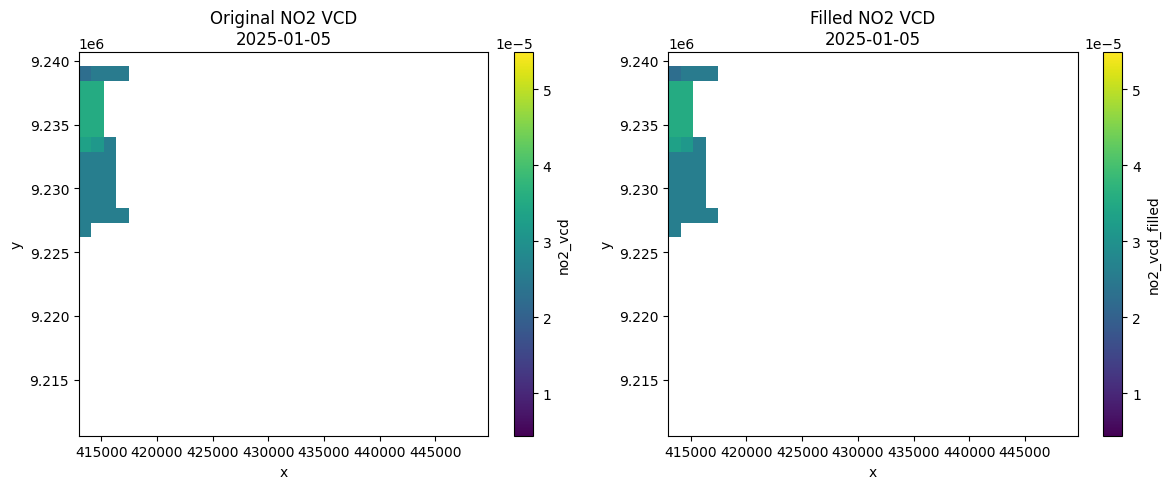

In [33]:
import matplotlib.pyplot as plt
import pandas as pd

# set time to datetime
df_temporalgap['time'] = pd.to_datetime(df_temporalgap['time'])

# Convert to xarray
ds_cek = df_temporalgap.set_index(['time', 'y', 'x']).to_xarray()

# choose time
t = 4
tanggal = pd.to_datetime(ds_cek.time.values[t]).strftime("%Y-%m-%d")

t_list =[25, 24, 35]
all_vals = []
for tl in t_list:
    orig   = ds_cek['no2_vcd'].isel(time=tl).values
    filled = ds_cek['no2_vcd_filled'].isel(time=tl).values
    all_vals.extend([np.nanmin(orig),  np.nanmax(orig),
                     np.nanmin(filled), np.nanmax(filled)])

vmin = np.nanmin(all_vals)
vmax = np.nanmax(all_vals)

# Plot side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Original
ds_cek['no2_vcd'].isel(time=t).plot(
    ax=axes[0],
    cmap='viridis',
    vmin=vmin,
    vmax=vmax
)
axes[0].set_title(f'Original NO2 VCD\n{tanggal}')

# Filled
ds_cek['no2_vcd_filled'].isel(time=t).plot(
    ax=axes[1],
    cmap='viridis',
    vmin=vmin,
    vmax=vmax
)
axes[1].set_title(f'Filled NO2 VCD\n{tanggal}')

plt.tight_layout()
plt.show()

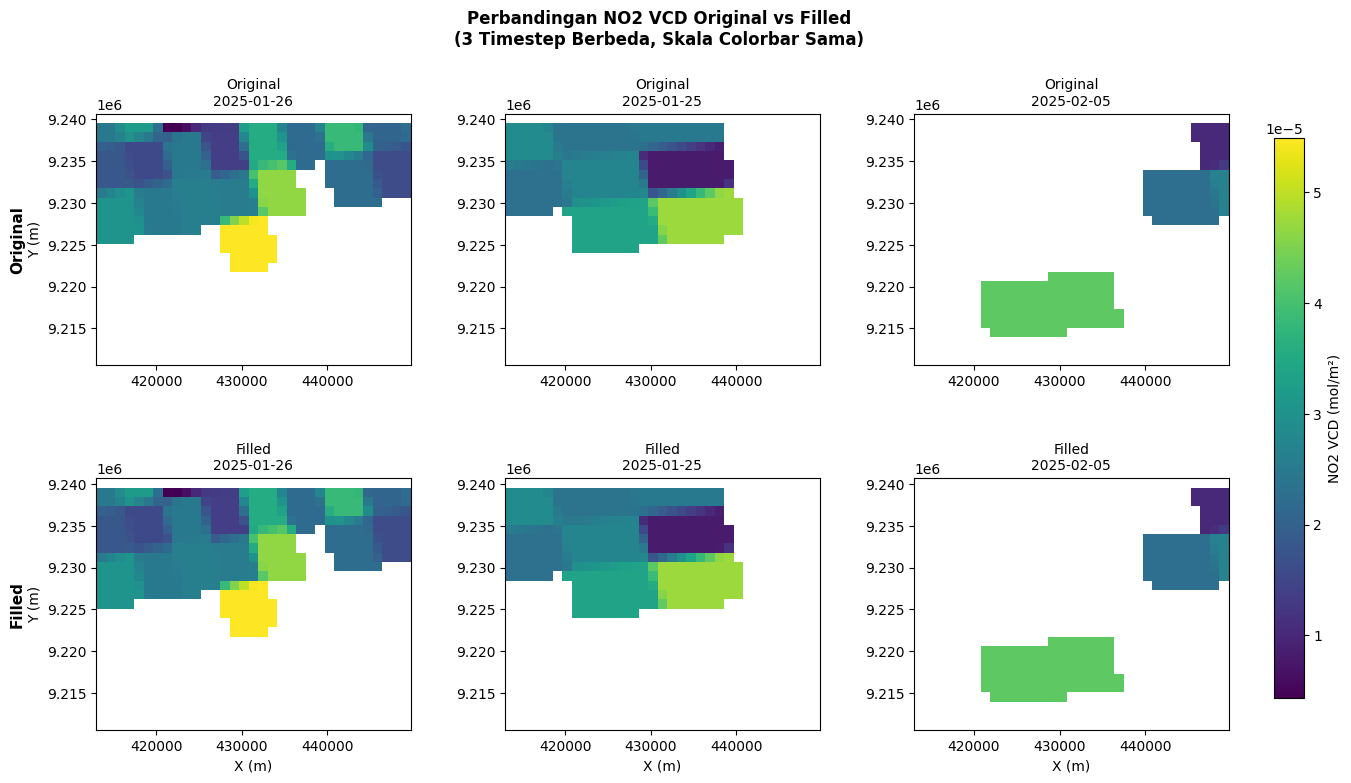

In [34]:
# choose 3 different timestep
t_list = [25, 24, 35] 

# compute vmin dan vmax global from 3 timestep (same scale)
all_vals = []
for t in t_list:
    orig   = ds_cek['no2_vcd'].isel(time=t).values
    filled = ds_cek['no2_vcd_filled'].isel(time=t).values
    all_vals.extend([np.nanmin(orig),  np.nanmax(orig),
                     np.nanmin(filled), np.nanmax(filled)])

vmin = np.nanmin(all_vals)
vmax = np.nanmax(all_vals)

# Plot: 2 row (original, filled) x 3 column (timestep)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for col, t in enumerate(t_list):
    tanggal = pd.to_datetime(ds_cek.time.values[t]).strftime("%Y-%m-%d")

    # row 0: Original
    im = ds_cek['no2_vcd'].isel(time=t).plot(
        ax=axes[0, col],
        cmap='viridis',
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )
    axes[0, col].set_title(f'Original\n{tanggal}', fontsize=10)
    axes[0, col].set_xlabel('')
    axes[0, col].set_ylabel('Y (m)' if col == 0 else '')

    # row 1: Filled
    ds_cek['no2_vcd_filled'].isel(time=t).plot(
        ax=axes[1, col],
        cmap='viridis',
        vmin=vmin,
        vmax=vmax,
        add_colorbar=False
    )
    axes[1, col].set_title(f'Filled\n{tanggal}', fontsize=10)
    axes[1, col].set_xlabel('X (m)')
    axes[1, col].set_ylabel('Y (m)' if col == 0 else '')

    
# Colorbar 
fig.subplots_adjust(right=0.88, hspace=0.45, wspace=0.3)
cbar_ax = fig.add_axes([0.91, 0.15, 0.02, 0.7])
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap='viridis', norm=norm)
sm.set_array([])
fig.colorbar(sm, cax=cbar_ax, label='NO2 VCD (mol/m²)')

# Label  
for row, label in enumerate(['Original', 'Filled']):
    axes[row, 0].annotate(
        label,
        xy=(-0.25, 0.5),
        xycoords='axes fraction',
        fontsize=11,
        fontweight='bold',
        va='center',
        ha='center',
        rotation=90
    )

fig.suptitle('Perbandingan NO2 VCD Original vs Filled\n(3 Timestep Berbeda, Skala Colorbar Sama)',
             fontsize=12, fontweight='bold', y=1.01)

#plt.savefig('no2_comparison_3col.png', dpi=150, bbox_inches='tight')
plt.show()

# Lag Features + Rolling Mean

In [35]:
# Lag Features
# clean column name
df_temporalgap.columns = df_temporalgap.columns.str.strip()

# Sort
df_temporalgap = df_temporalgap.sort_values(['x', 'y', 'time'])

for lag in [1, 2, 3, 7]:
    col = f'no2_lag_{lag}'
    df_temporalgap[col] = (
        df_temporalgap.groupby(['x', 'y'])['no2_vcd_filled']
        .shift(lag)
    )

# Rolling mean 7 days per pixel
df_temporalgap['no2_roll7'] = (
    df_temporalgap.groupby(['x', 'y'])['no2_vcd_filled']
    .transform(lambda s: s.shift(1).rolling(7, min_periods=2).mean())
)

lag_cols = ['no2_lag_1', 'no2_lag_2', 'no2_lag_3', 'no2_lag_7', 'no2_roll7']
print(f"✅ Lag features: {lag_cols}")
print(f"   NaN dari lag: {df_temporalgap[lag_cols].isna().sum().to_dict()}")

# Update selected features
new_features = lag_cols

# Filter not all NaN value
new_features = [
    f for f in new_features
    if f in df_temporalgap.columns and df_temporalgap[f].notna().sum() > 100
]


✅ Lag features: ['no2_lag_1', 'no2_lag_2', 'no2_lag_3', 'no2_lag_7', 'no2_roll7']
   NaN dari lag: {'no2_lag_1': 72320, 'no2_lag_2': 73093, 'no2_lag_3': 73604, 'no2_lag_7': 75593, 'no2_roll7': 35715}


# **Feature Selection**

In [36]:
print(df_temporalgap.columns.tolist())

['time', 'pixel', 'band', 'spatial_ref', 'no2_vcd', 'tp', 'h', 'pb', 'ps', 'sr', 'temp', 'ws', 'wd', 'dem', 'pop', 'industry', 'landcover', 'no2_cams', 'y', 'x', 'month', 'day', 'dayofyear', 'week', 'month_sin', 'month_cos', 'dayofyear_sin', 'dayofyear_cos', 'y_x_interaction', 'y_squared', 'x_squared', 'time_ordinal', 'no2_cams_filled', 'no2_cams_climatology', 'no2_cams_anomaly', 'lc_2', 'lc_8', 'lc_9', 'lc_11', 'lc_12', 'lc_13', 'lc_14', 'lc_16', 'lc_17', 'lc_255', 'missing_type', 'streak_len', 'category', 'no2_vcd_filled', 'spatial_mean', 'anomaly', 'anomaly_smooth', 'anomaly_final', 'scaling_factor', 'mean_scaling_weekly', 'no2_lag_1', 'no2_lag_2', 'no2_lag_3', 'no2_lag_7', 'no2_roll7']


In [37]:
df_rf = df_temporalgap.copy()
# Filter column in dataframe
available_features = [col for col in df_rf.columns if col not in ['no2_vcd',
                                                                    'time', 'spatial_ref', 'x', 'y', 'month', 'day',
                                                                    'month_sin', 'month_cos',
                                                                    'no2_cams', 'landcover', 'pixel','band', 
                                                                    'missing_type', 'lc_255', 'missing_type',   
                                                                    'mean_scaling_weekly', 'no2_cams_filled',       # leakage utama
                                                                    'no2_cams_climatology',  # leakage
                                                                    'no2_cams_anomaly',      # leakage
                                                                      'no2_lag_1', 'no2_lag_2', 'no2_lag_3',
                                                                      'no2_lag_7', 'no2_roll7', 'streak_len', 'category', 
                                                                      'no2_vcd_filled', 'spatial_mean', 'anomaly', 'anomaly_smooth', 
                                                                      'anomaly_final', 'scaling_factor', 'mean_scaling_weekly',]]   
print((f"fitur pada train_data: {len(available_features)}"))

fitur pada train_data: 28


In [38]:
# print available feature

print(available_features)

['tp', 'h', 'pb', 'ps', 'sr', 'temp', 'ws', 'wd', 'dem', 'pop', 'industry', 'dayofyear', 'week', 'dayofyear_sin', 'dayofyear_cos', 'y_x_interaction', 'y_squared', 'x_squared', 'time_ordinal', 'lc_2', 'lc_8', 'lc_9', 'lc_11', 'lc_12', 'lc_13', 'lc_14', 'lc_16', 'lc_17']


In [39]:
# Mask NaN and Not NaN
df_valid = df_rf.dropna(subset=['no2_vcd_filled'])
print(df_valid.shape)
print(df_rf.shape)

df_valid = df_valid[df_valid['no2_vcd_filled'] > 0].copy()
print(f"Data setelah filter negatif: {len(df_valid)}")

(89232, 60)
(161271, 60)
Data setelah filter negatif: 88960


In [40]:
X_check = df_valid[available_features]
y_check = df_valid['no2_vcd_filled']
coords = df_valid[['x', 'y']].values

# Convert time to ordinal (day-
time_values = df_valid['time_ordinal'].values

from scipy.stats import spearmanr

correlations = []
for i, col in enumerate(available_features):
    # Handle NaN values
    mask = df_valid[col].notna().values
    if mask.sum() > 10:  # Minimal 10 sample
        corr, p_val = spearmanr(X_check[col][mask], y_check[mask])
        correlations.append({'feature': col, 'correlation': abs(corr), 'p_value': p_val})

corr_df = pd.DataFrame(correlations).sort_values('correlation', ascending=False)
print("\n   Top 15 Correlated Feature:")
print(corr_df.head(16).to_string(index=False))

# choose featire with correlation > 0.05 threshold and p-value < 0.05
threshold = 0.05
selected_features = corr_df[
    (corr_df['correlation'] > threshold) & 
    (corr_df['p_value'] < 0.05)
]['feature'].tolist()

print(f"\n   Selected Features: {len(selected_features)} of {len(available_features)}")
print(f"   Sample: {selected_features[:10]}")

# Update X with selected feature
feature_idx = [available_features.index(f) for f in selected_features]
X_selected = X_check.iloc[:, feature_idx]





   Top 15 Correlated Feature:
      feature  correlation       p_value
     industry     0.258165  0.000000e+00
           ws     0.206875  0.000000e+00
        lc_13     0.203210  0.000000e+00
         week     0.161922  0.000000e+00
          pop     0.161088  0.000000e+00
 time_ordinal     0.159926  0.000000e+00
dayofyear_cos     0.159926  0.000000e+00
    dayofyear     0.159926  0.000000e+00
           pb     0.146634  0.000000e+00
           wd     0.093252 5.559766e-171
           sr     0.089774 1.443930e-158
    y_squared     0.072234 3.256531e-103
         temp     0.064596  6.973195e-83
        lc_17     0.064310  3.641450e-82
           tp     0.061254  1.058612e-74
dayofyear_sin     0.057567  3.505291e-66

   Selected Features: 16 of 28
   Sample: ['industry', 'ws', 'lc_13', 'week', 'pop', 'time_ordinal', 'dayofyear_cos', 'dayofyear', 'pb', 'wd']


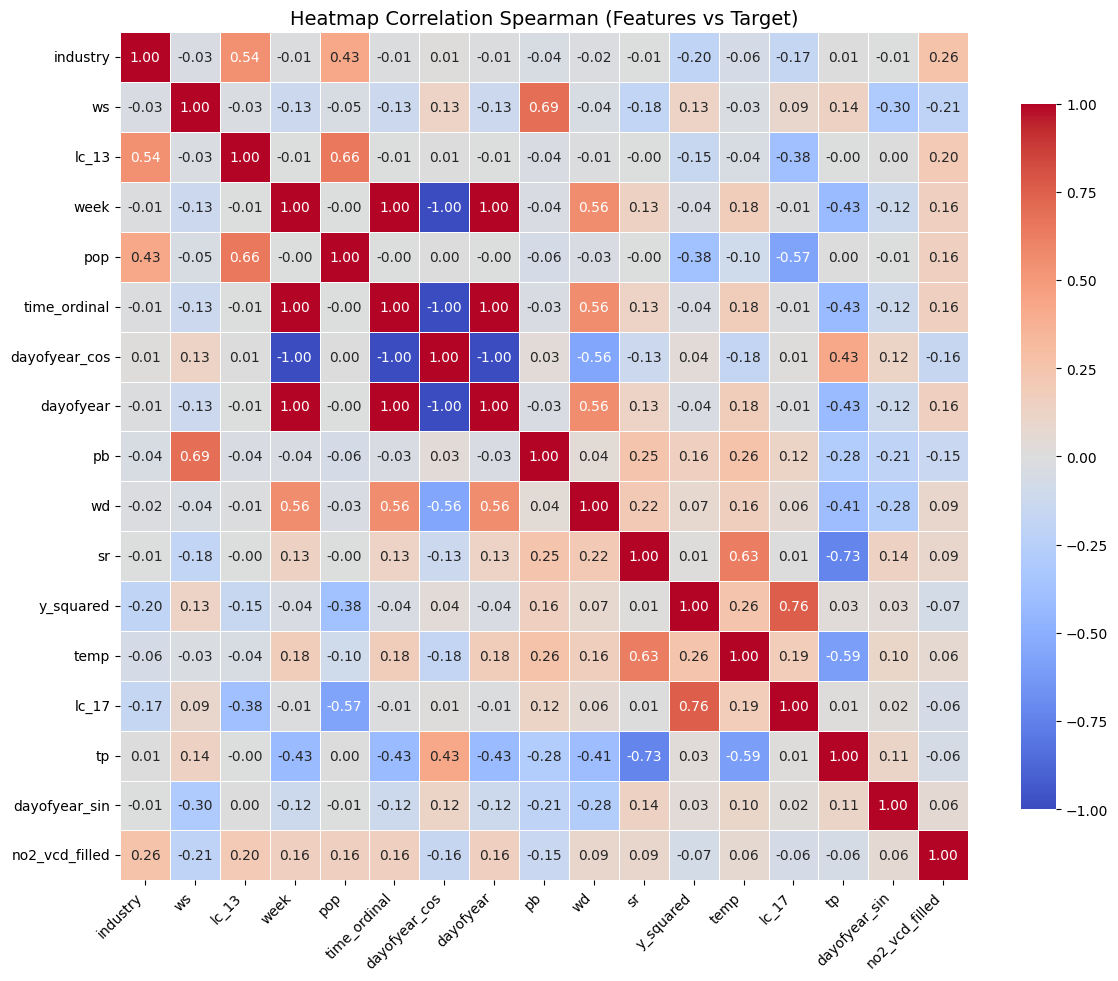

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

# merge selected feature + target
df_corr = df_valid[selected_features + ['no2_vcd_filled']].copy()

# compute correlation matrix (Spearman)
corr_matrix = df_corr.corr(method='spearman')

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,        # add number
    fmt=".2f",         
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Heatmap Correlation Spearman (Features vs Target)", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# **Variasi Fitur**

In [61]:
# Variation 1
selected_features = selected_features
selected_features = list(dict.fromkeys(selected_features))

# Variation 2
lag_cols3 = ['no2_lag_1']
selected_features_v2 = selected_features + lag_cols3
selected_features_v2 = list(dict.fromkeys(selected_features_v2))

# **Spatial-Temporal Block Split V.1** 

In [43]:
# Spatial-Temporal Block Assignment
df_valid['block_x'] = pd.cut(df_valid['x'], bins=4, labels=False)
df_valid['block_y'] = pd.cut(df_valid['y'], bins=4, labels=False)
df_valid['time_block'] = pd.cut(df_valid['time_ordinal'], bins=3, labels=False)
df_valid['st_block'] = (
    df_valid['block_x'].astype(str) + '_' +
    df_valid['block_y'].astype(str) + '_t' +
    df_valid['time_block'].astype(str)
)
print(f"Total ST blocks: {df_valid['st_block'].nunique()}")

# Gap Simulation
np.random.seed(42)
unique_blocks = df_valid['st_block'].dropna().unique()
n_test_blocks = int(0.2 * len(unique_blocks))
test_blocks = np.random.choice(unique_blocks, size=n_test_blocks, replace=False)
df_valid['is_sim_gap'] = df_valid['st_block'].isin(test_blocks)

train_data = df_valid[~df_valid['is_sim_gap']].copy()
test_data  = df_valid[df_valid['is_sim_gap']].copy()

X_train = train_data[selected_features].fillna(train_data[selected_features].median())
y_train = train_data['no2_vcd_filled']
groups  = train_data['st_block']

X_test  = test_data[selected_features].fillna(train_data[selected_features].median())
y_test  = test_data['no2_vcd_filled'].values

print(f"Train: {len(X_train)} | Test: {len(X_test)}")

Total ST blocks: 48
Train: 74602 | Test: 14358


In [44]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=5,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42,
    oob_score=True       # out-of-bag score as more estimation
)

# Hyperparameter Tuning with RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15],
    'min_samples_leaf': [5, 10, 20],
    'max_features': ['sqrt', 0.3, 0.5]
}

gkf = GroupKFold(n_splits=10)
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=gkf.split(X_train, y_train, groups=groups),
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42
)
random_search.fit(X_train, y_train)
print(f"\nBest Hyperparameters: {random_search.best_params_}")


Best Hyperparameters: {'n_estimators': 200, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 15}


In [48]:
gkf = GroupKFold(n_splits=10)
cv_results = []

print(f"\n{'='*55}")
print(f"  Spatial-Temporal Block CV (10-fold)")
print(f"{'='*55}")

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups=groups)):

    X_tr, X_val = X_train.iloc[tr_idx], X_train.iloc[val_idx]
    y_tr, y_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]

       # new instance best params
    rf_fold = RandomForestRegressor(
        **random_search.best_params_,
        n_jobs=-1,
        random_state=42
    )
    rf_fold.fit(X_tr, y_tr)
    y_pred_val = rf_fold.predict(X_val)

    rmse = np.sqrt(mean_squared_error(y_val, y_pred_val))
    mae  = mean_absolute_error(y_val, y_pred_val)
    r2   = r2_score(y_val, y_pred_val)
    bias = (y_pred_val - y_val).mean()
    rpe = (
        (y_pred_val - y_val) / (y_val + 1e-12)
    ).mean() * 100
    slope = np.polyfit(y_val, y_pred_val, 1)[0]
    

    smape = (
        np.abs(y_pred_val - y_val) /
        (np.abs(y_val) + np.abs(y_pred_val) + 1e-12)
    ).mean() * 200

    print(f"  Fold {fold+1}: RMSE={rmse:.4e} | MAE={mae:.4e} | R²={r2:.4f} | Bias={bias:.4e} | sMAPE={smape:.2f}%")

    cv_results.append({'fold': fold+1, 'RMSE': rmse, 'MAE': mae,
                          'R2': r2, 'Bias': bias, 'sMAPE': smape, 'RPE': rpe, 'Slope': slope})

    cv_df = pd.DataFrame(cv_results)



  Spatial-Temporal Block CV (10-fold)
  Fold 1: RMSE=1.1091e-05 | MAE=7.5422e-06 | R²=0.6280 | Bias=2.5637e-06 | sMAPE=20.64%
  Fold 2: RMSE=1.1485e-05 | MAE=8.6920e-06 | R²=0.6320 | Bias=1.3650e-06 | sMAPE=26.11%
  Fold 3: RMSE=9.3142e-06 | MAE=6.6649e-06 | R²=0.7026 | Bias=-5.2268e-07 | sMAPE=20.17%
  Fold 4: RMSE=1.5176e-05 | MAE=9.0602e-06 | R²=0.6072 | Bias=-3.8739e-06 | sMAPE=20.32%
  Fold 5: RMSE=1.0759e-05 | MAE=7.7293e-06 | R²=0.6552 | Bias=-3.7349e-11 | sMAPE=22.75%
  Fold 6: RMSE=9.9940e-06 | MAE=7.6038e-06 | R²=0.3556 | Bias=-8.4904e-07 | sMAPE=21.53%
  Fold 7: RMSE=1.4086e-05 | MAE=9.6200e-06 | R²=0.5554 | Bias=8.4190e-07 | sMAPE=26.48%
  Fold 8: RMSE=8.2686e-06 | MAE=6.1988e-06 | R²=0.4794 | Bias=-1.0101e-06 | sMAPE=19.99%
  Fold 9: RMSE=8.0138e-06 | MAE=6.0825e-06 | R²=0.5662 | Bias=-1.5113e-08 | sMAPE=22.52%
  Fold 10: RMSE=1.0508e-05 | MAE=7.5277e-06 | R²=0.5270 | Bias=2.3367e-06 | sMAPE=22.38%


In [49]:
metrics = ['R2']

print(f"\n{'='*55}")
print(f"  Summary CV (Mean ± Std)")
print(f"{'='*55}")
for m in metrics:
    mean_val = cv_df[m].mean()
    std_val  = cv_df[m].std()          # std default ddof=1
    if m in ('R2',):
        print(f"  {m:<6}: {mean_val:.4f} ± {std_val:.4f}")
    else:
        print(f"  {m:<6}: {mean_val:.4e} ± {std_val:.4e}")
print(f"{'='*55}")


  Summary CV (Mean ± Std)
  R2    : 0.5709 ± 0.0998


In [50]:
# Cek shape data
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)

# Cek nilai data
print("\nX_train mean:", X_train.mean().values)
print("y_train mean:", y_train.mean())

# Cek groups
print("\nGroups unique:", groups.nunique())
print("Groups sample:", groups.values[:10])

X_train shape: (74602, 16)
y_train shape: (74602,)
X_test shape: (14358, 16)

X_train mean: <FloatingArray>
[8.788639149770461e-08,     2.270202718789076,   0.21192461328114529,
     14.57829548805662,     2225.067138671875,      739348.025522104,
  -0.07257853603838967,     97.02552210396505,     397.9970397949219,
     217.1650383695446,    239.81341552734375,     85176523051927.02,
    26.338137179374783,   0.38864909787941343,    0.9757049799551705,
    0.5913677319632757]
Length: 16, dtype: Float64
y_train mean: 3.6010923385054585e-05

Groups unique: 39
Groups sample: ['0_0_t0' '0_0_t0' '0_0_t0' '0_0_t0' '0_0_t0' '0_0_t0' '0_0_t0' '0_0_t0'
 '0_0_t0' '0_0_t0']


# **Model RF V1**

In [51]:
model_results_v1 = []
best_rf = RandomForestRegressor(
    **random_search.best_params_,
    oob_score=True,
    n_jobs=-1,
    random_state=42
)
best_rf.fit(X_train, y_train)
y_pred_test = best_rf.predict(X_test)
y_pred_train = best_rf.predict(X_train)

rmse_fv1 = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_fv1  = mean_absolute_error(y_test, y_pred_test)
r2_fv1   = r2_score(y_test, y_pred_test)
bias_fv1 = (y_pred_test - y_test).mean()
mape_fv1 = (np.abs(y_pred_test - y_test) / (np.abs(y_test) + 1e-12)).mean() * 100
rpe_fv1 = (
        (y_pred_test - y_test) / (y_test + 1e-12)
    ).mean() * 100
slope_fv1 = np.polyfit(y_pred_test, y_test, 1)[0]

rmse_tv1 = np.sqrt(mean_squared_error(y_train, y_pred_train))
mae_tv1  = mean_absolute_error(y_train, y_pred_train)
r2_tv1   = r2_score(y_train, y_pred_train)
bias_tv1 = (y_pred_train - y_train).mean()
mape_tv1 = (np.abs(y_pred_train - y_train) / (np.abs(y_train) + 1e-12)).mean() * 100

print(f"\n{'='*55}")
print(f"  FINAL TEST SET (Simulated Gap 20%)")
print(f"{'='*55}")
print(f"  RMSE : {rmse_fv1:.4e}")
print(f"  MAE  : {mae_fv1:.4e}")
print(f"  R²   : {r2_fv1:.4f}")
print(f"  Bias : {bias_fv1:.4e}")
print(f"  MAPE : {mape_fv1:.2f}%")
print(f"  OOB R²: {best_rf.oob_score_:.4f}")
rpe_fv1 = (
        (y_pred_test - y_test) / (y_test + 1e-12)
    ).mean() * 100
slope_fv1 = np.polyfit(y_pred_test, y_test, 1)[0]
print(f"  RPE: {rpe_fv1:.2f}%")
print(f"  Slope: {slope_fv1:.4e}")

print(f"\n{'='*55}")
print(f"  FINAL TRAIN SET (Simulated Gap 20%)")
print(f"{'='*55}")
print(f"  RMSE : {rmse_tv1:.4e}")
print(f"  MAE  : {mae_tv1:.4e}")
print(f"  R²   : {r2_tv1:.4f}")
print(f"  Bias : {bias_tv1:.4e}")
print(f"  MAPE : {mape_tv1:.2f}%")
print(f"  OOB R²: {best_rf.oob_score_:.4f}")

model_results_v1.append({'RMSE': rmse_fv1, 'MAE': mae_fv1,
                          'R2': r2_fv1, 'Bias': bias_fv1,'OOB_R2': best_rf.oob_score_, 'RPE': rpe_fv1, 'Slope': slope_fv1})

model_df_v1 = pd.DataFrame(model_results_v1)



  FINAL TEST SET (Simulated Gap 20%)
  RMSE : 1.1084e-05
  MAE  : 8.2626e-06
  R²   : 0.5852
  Bias : 9.5917e-07
  MAPE : 36.96%
  OOB R²: 0.8497
  RPE: 22.19%
  Slope: 9.2606e-01

  FINAL TRAIN SET (Simulated Gap 20%)
  RMSE : 6.0906e-06
  MAE  : 4.2580e-06
  R²   : 0.8823
  Bias : -2.9315e-10
  MAPE : 17.89%
  OOB R²: 0.8497


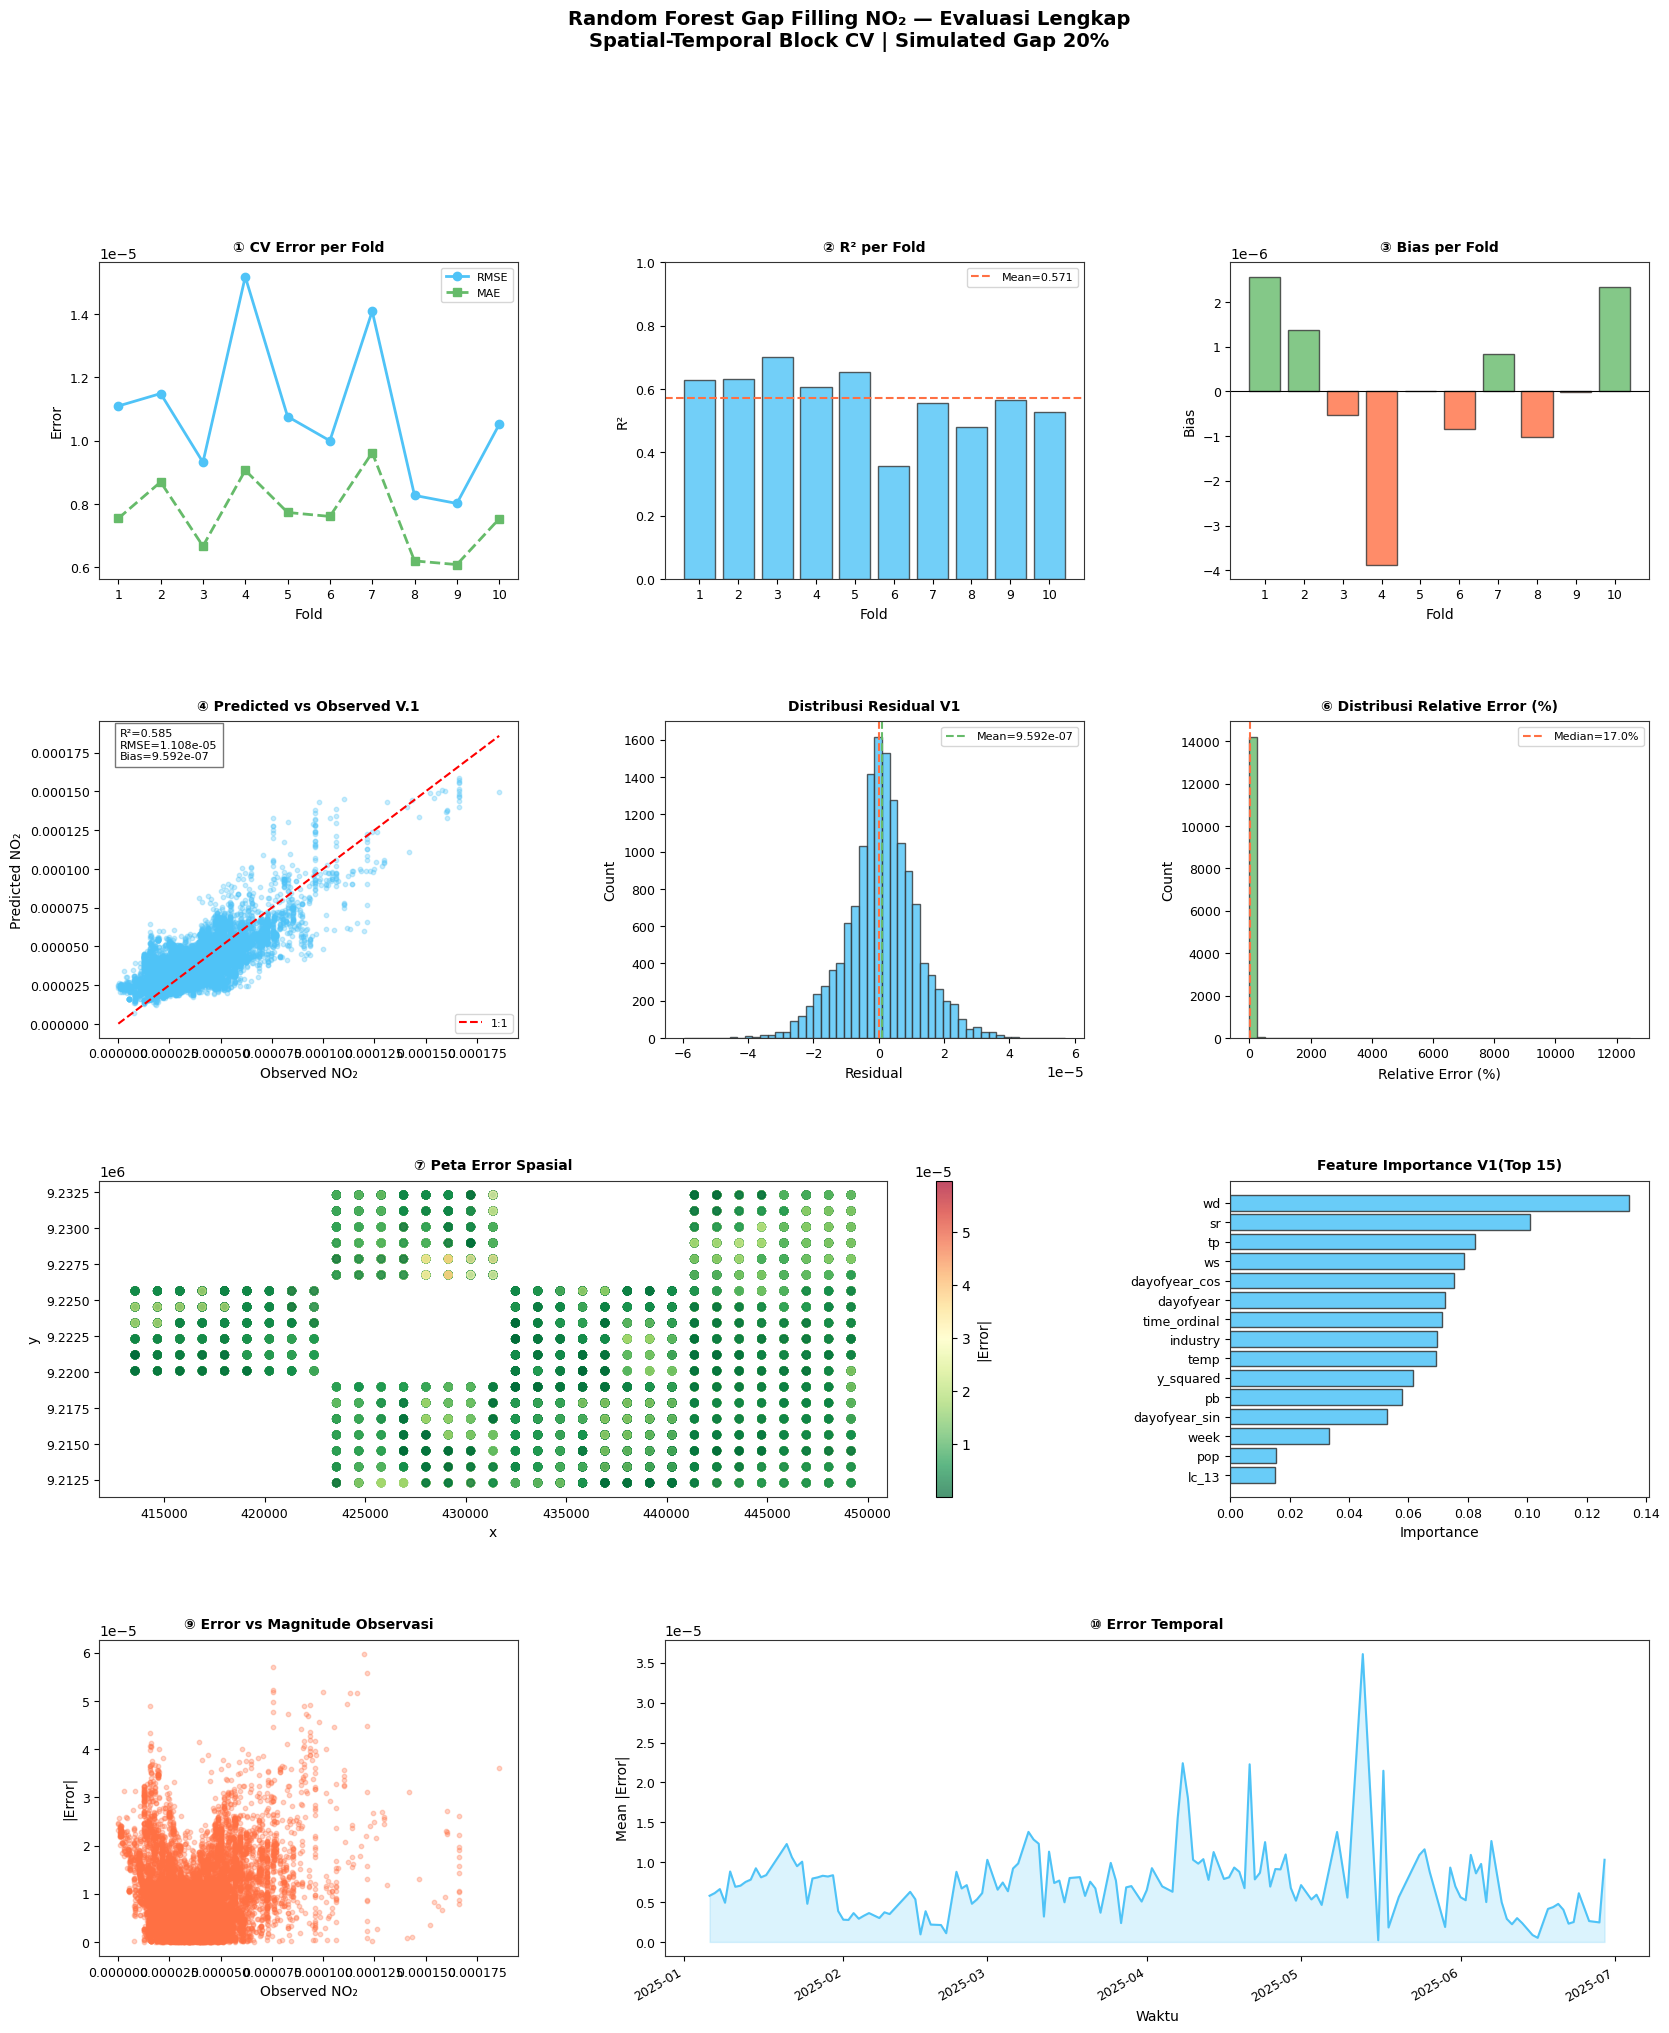

Done.


In [52]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

error_v1     = y_pred_test - y_test
rel_error_v1 = np.abs(error_v1) / (np.abs(y_test) + 1e-12) * 100

DARK  = "#ffffff"; PANEL = "#ffffff"
ACCENT= '#4fc3f7'; WARN  = '#ff7043'
GREEN = '#66bb6a'; TEXT  = "#000000"

def style_ax(ax, title):
    ax.set_facecolor(PANEL)
    ax.tick_params(colors=TEXT, labelsize=9)
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)
    ax.set_title(title, fontsize=10, fontweight='bold', color=TEXT, pad=8)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333')

fig = plt.figure(figsize=(20, 22))
fig.patch.set_facecolor(DARK)
gs  = gridspec.GridSpec(4, 3, figure=fig, hspace=0.45, wspace=0.35)

# ① CV RMSE & MAE
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(cv_df['fold'], cv_df['RMSE'], 'o-', color=ACCENT, label='RMSE', lw=2)
ax1.plot(cv_df['fold'], cv_df['MAE'],  's--', color=GREEN, label='MAE',  lw=2)
ax1.set_xlabel('Fold'); ax1.set_ylabel('Error')
ax1.legend(facecolor=PANEL, labelcolor=TEXT, fontsize=8)
ax1.set_xticks(cv_df['fold'])
style_ax(ax1, '① CV Error per Fold')

# ② R² per Fold
ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(cv_df['fold'], cv_df['R2'], color=ACCENT, alpha=0.8, edgecolor='#333')
ax2.axhline(cv_df['R2'].mean(), color=WARN, ls='--', lw=1.5,
            label=f"Mean={cv_df['R2'].mean():.3f}")
ax2.set_ylim(0, 1); ax2.set_xlabel('Fold'); ax2.set_ylabel('R²')
ax2.legend(facecolor=PANEL, labelcolor=TEXT, fontsize=8)
ax2.set_xticks(cv_df['fold'])
style_ax(ax2, '② R² per Fold')

# ③ Bias per Fold
ax3 = fig.add_subplot(gs[0, 2])
colors_b = [GREEN if b >= 0 else WARN for b in cv_df['Bias']]
ax3.bar(cv_df['fold'], cv_df['Bias'], color=colors_b, alpha=0.8, edgecolor='#333')
ax3.axhline(0, color=TEXT, lw=0.8)
ax3.set_xlabel('Fold'); ax3.set_ylabel('Bias')
ax3.set_xticks(cv_df['fold'])
style_ax(ax3, '③ Bias per Fold')

# ④ Scatter Predicted vs Observed
ax4 = fig.add_subplot(gs[1, 0])
ax4.scatter(y_test, y_pred_test, alpha=0.3, s=10, color=ACCENT)
lims = [min(y_test.min(), y_pred_test.min()), max(y_test.max(), y_pred_test.max())]
ax4.plot(lims, lims, 'r--', lw=1.5, label='1:1')
ax4.text(0.05, 0.88,
         f"R²={r2_fv1:.3f}\nRMSE={rmse_fv1:.3e}\nBias={bias_fv1:.3e}",
         transform=ax4.transAxes, color=TEXT, fontsize=8,
         bbox=dict(facecolor=PANEL, edgecolor='#555', alpha=0.8))
ax4.set_xlabel('Observed NO₂'); ax4.set_ylabel('Predicted NO₂')
ax4.legend(facecolor=PANEL, labelcolor=TEXT, fontsize=8)
style_ax(ax4, '④ Predicted vs Observed V.1')

# ⑤ Distribusi Residual
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(error_v1, bins=50, color=ACCENT, alpha=0.8, edgecolor='#333')
ax5.axvline(0, color=WARN, ls='--', lw=1.5)
ax5.axvline(error_v1.mean(), color=GREEN, ls='--', lw=1.5,
            label=f'Mean={error_v1.mean():.3e}')
ax5.set_xlabel('Residual'); ax5.set_ylabel('Count')
ax5.legend(facecolor=PANEL, labelcolor=TEXT, fontsize=8)
style_ax(ax5, 'Distribusi Residual V1')

# ⑥ Relative Error
ax6 = fig.add_subplot(gs[1, 2])
ax6.hist(rel_error_v1, bins=50, color=GREEN, alpha=0.8, edgecolor='#333')
ax6.axvline(np.median(rel_error_v1), color=WARN, ls='--', lw=1.5,
            label=f'Median={np.median(rel_error_v1):.1f}%')
ax6.set_xlabel('Relative Error (%)'); ax6.set_ylabel('Count')
ax6.legend(facecolor=PANEL, labelcolor=TEXT, fontsize=8)
style_ax(ax6, '⑥ Distribusi Relative Error (%)')

# ⑦ Peta Error Spasial
ax7 = fig.add_subplot(gs[2, :2])
sc = ax7.scatter(test_data['x'], test_data['y'],
                 c=np.abs(error_v1), cmap='RdYlGn_r', s=30, alpha=0.7)
cbar = plt.colorbar(sc, ax=ax7)
cbar.set_label('|Error|', color=TEXT)
cbar.ax.yaxis.set_tick_params(color=TEXT)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=TEXT)
ax7.set_xlabel('x'); ax7.set_ylabel('y')
style_ax(ax7, '⑦ Peta Error Spasial')

# ⑧ Feature Importance
ax8 = fig.add_subplot(gs[2, 2])
feat_imp = pd.DataFrame({
    'feature': selected_features,
    'importance': best_rf.feature_importances_
}).sort_values('importance').tail(15)
ax8.barh(feat_imp['feature'], feat_imp['importance'],
         color=ACCENT, alpha=0.85, edgecolor='#333')
ax8.set_xlabel('Importance')
style_ax(ax8, 'Feature Importance V1(Top 15)')

# ⑨ Error vs Magnitude
ax9 = fig.add_subplot(gs[3, 0])
ax9.scatter(y_test, np.abs(error_v1), alpha=0.3, s=10, color=WARN)
ax9.set_xlabel('Observed NO₂'); ax9.set_ylabel('|Error|')
style_ax(ax9, '⑨ Error vs Magnitude Observasi')

# ⑩ Temporal Error
ax10 = fig.add_subplot(gs[3, 1:])
test_data = test_data.copy()
test_data['abs_error'] = np.abs(error_v1)
temp_err = test_data.groupby('time')['abs_error'].mean().reset_index()
ax10.plot(temp_err['time'], temp_err['abs_error'], color=ACCENT, lw=1.5)
ax10.fill_between(temp_err['time'], temp_err['abs_error'], alpha=0.2, color=ACCENT)
ax10.set_xlabel('Waktu'); ax10.set_ylabel('Mean |Error|')
plt.setp(ax10.xaxis.get_majorticklabels(), rotation=30, ha='right')
style_ax(ax10, '⑩ Error Temporal')

fig.suptitle(
    'Random Forest Gap Filling NO₂ — Evaluasi Lengkap\n'
    'Spatial-Temporal Block CV | Simulated Gap 20%',
    fontsize=14, fontweight='bold', color=TEXT, y=0.995
)

plt.savefig('rf_gapfill_evaluation.png', dpi=150,
            bbox_inches='tight', facecolor=DARK)
plt.show()
print("Done.")

# **Spatial Block Temporal CV V.2**

In [62]:
# Drop row 1
df_valid_v2 = df_valid.dropna(subset=['no2_lag_1']).copy()
print(f"Data after drop lag NaN: {len(df_valid_v2)} (dari {len(df_valid)})")

# Spatial-Temporal Block Assignment
df_valid_v2['block_x'] = pd.cut(df_valid_v2['x'], bins=4, labels=False)
df_valid_v2['block_y'] = pd.cut(df_valid_v2['y'], bins=4, labels=False)
df_valid_v2['time_block'] = pd.cut(df_valid_v2['time_ordinal'], bins=3, labels=False)
df_valid_v2['st_block'] = (
    df_valid_v2['block_x'].astype(str) + '_' +
    df_valid_v2['block_y'].astype(str) + '_t' +
    df_valid_v2['time_block'].astype(str)
)
print(f"Total ST blocks: {df_valid_v2['st_block'].nunique()}")

# Gap simulation
np.random.seed(42)
unique_blocks = df_valid_v2['st_block'].dropna().unique()
n_test_blocks = int(0.2 * len(unique_blocks))
test_blocks = np.random.choice(unique_blocks, size=n_test_blocks, replace=False)
df_valid_v2['is_sim_gap'] = df_valid_v2['st_block'].isin(test_blocks)

train_data_v2 = df_valid_v2[~df_valid_v2['is_sim_gap']].copy()
test_data_v2  = df_valid_v2[df_valid_v2['is_sim_gap']].copy()

X_train_v2 = train_data_v2[selected_features_v2].fillna(train_data_v2[selected_features_v2].median())
y_train_v2 = train_data_v2['no2_vcd_filled']
groups_v2  = train_data_v2['st_block']

X_test_v2  = test_data_v2[selected_features_v2].fillna(train_data_v2[selected_features_v2].median())
y_test_v2  = test_data_v2['no2_vcd_filled'].values

print(f"Train v2: {len(X_train_v2)} | Test v2: {len(X_test_v2)}")

Data after drop lag NaN: 64440 (dari 88960)
Total ST blocks: 48
Train v2: 55694 | Test v2: 8746


In [63]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

rf_v2 = RandomForestRegressor(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=5,
    max_features='sqrt',
    n_jobs=-1,
    random_state=42,
    oob_score=True     
)

# Hyperparameter Tuning with RandomizedSearchCV
from sklearn.model_selection import RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15],
    'min_samples_leaf': [5, 10, 20],
    'max_features': ['sqrt', 0.3, 0.5]
}

gkf = GroupKFold(n_splits=10)
random_searchv2 = RandomizedSearchCV(
    estimator=rf_v2,
    param_distributions=param_dist,
    n_iter=20,
    cv=gkf.split(X_train_v2, y_train_v2, groups=groups_v2),
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    random_state=42
)
random_searchv2.fit(X_train_v2, y_train_v2)
print(f"\nBest Hyperparameters: {random_searchv2.best_params_}")


Best Hyperparameters: {'n_estimators': 500, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 15}


In [67]:
gkf = GroupKFold(n_splits=10)
cv_results_v2 = []

print(f"\n{'='*55}")
print(f"  Spatial-Temporal Block CV (10-fold)")
print(f"{'='*55}")

for fold, (tr_idx, val_idx) in enumerate(gkf.split(X_train_v2, y_train_v2, groups=groups_v2)):

    X_tr, X_val = X_train_v2.iloc[tr_idx], X_train_v2.iloc[val_idx]
    y_tr, y_val = y_train_v2.iloc[tr_idx], y_train_v2.iloc[val_idx]

    rf_fold_v2  = RandomForestRegressor(
        **random_searchv2.best_params_,
        n_jobs=-1,
        random_state=42
    )
    rf_fold_v2.fit(X_tr, y_tr)
    y_pred_val = rf_fold_v2.predict(X_val)

    rmse_cv2 = np.sqrt(mean_squared_error(y_val, y_pred_val))
    mae_cv2  = mean_absolute_error(y_val, y_pred_val)
    r2_cv2   = r2_score(y_val, y_pred_val)
    bias_cv2 = (y_pred_val - y_val).mean()
    rpe = (
        (y_pred_val - y_val) / (y_val + 1e-12)
    ).mean() * 100
    slope = np.polyfit(y_val, y_pred_val, 1)[0]

    smape_cv2 = (
        np.abs(y_pred_val - y_val) /
        (np.abs(y_val) + np.abs(y_pred_val) + 1e-12)
    ).mean() * 200

    print(f"  Fold {fold+1}: RMSE={rmse_cv2:.4e} | MAE={mae_cv2:.4e} | R²={r2_cv2:.4f} | Bias={bias_cv2:.4e} | sMAPE={smape_cv2:.2f}%")

    cv_results_v2.append({'fold': fold+1, 'RMSE': rmse_cv2, 'MAE': mae_cv2,
                          'R2': r2_cv2, 'Bias': bias_cv2, 'sMAPE': smape_cv2, 'RPE': rpe, 'Slope': slope})

    cv_df_v2 = pd.DataFrame(cv_results_v2)



  Spatial-Temporal Block CV (10-fold)
  Fold 1: RMSE=7.8639e-06 | MAE=5.4358e-06 | R²=0.6742 | Bias=9.5199e-07 | sMAPE=16.09%
  Fold 2: RMSE=7.4179e-06 | MAE=4.8678e-06 | R²=0.6776 | Bias=-7.2782e-07 | sMAPE=13.32%
  Fold 3: RMSE=1.1290e-05 | MAE=7.5653e-06 | R²=0.6891 | Bias=-2.2875e-06 | sMAPE=18.19%
  Fold 4: RMSE=6.5665e-06 | MAE=4.4510e-06 | R²=0.7656 | Bias=-6.0963e-08 | sMAPE=17.27%
  Fold 5: RMSE=6.8885e-06 | MAE=3.8783e-06 | R²=0.8109 | Bias=-1.0713e-06 | sMAPE=10.41%
  Fold 6: RMSE=9.2807e-06 | MAE=5.4837e-06 | R²=0.6636 | Bias=1.4875e-07 | sMAPE=16.02%
  Fold 7: RMSE=7.5323e-06 | MAE=5.0196e-06 | R²=0.7321 | Bias=4.8316e-07 | sMAPE=16.27%
  Fold 8: RMSE=4.9793e-06 | MAE=3.3680e-06 | R²=0.7793 | Bias=9.1764e-07 | sMAPE=13.83%
  Fold 9: RMSE=8.1540e-06 | MAE=5.4908e-06 | R²=0.4864 | Bias=2.5551e-06 | sMAPE=17.86%
  Fold 10: RMSE=6.9588e-06 | MAE=4.4070e-06 | R²=0.8399 | Bias=-7.4296e-07 | sMAPE=13.46%


In [68]:
metrics = ['R2']

print(f"\n{'='*55}")
print(f"  Summary CV (Mean ± Std)")
print(f"{'='*55}")
for m in metrics:
    mean_val = cv_df_v2[m].mean()
    std_val  = cv_df_v2[m].std()          # std default ddof=1
    if m in ('R2',):
        print(f"  {m:<6}: {mean_val:.4f} ± {std_val:.4f}")
    else:
        print(f"  {m:<6}: {mean_val:.4e} ± {std_val:.4e}")
print(f"{'='*55}")


  Summary CV (Mean ± Std)
  R2    : 0.7119 ± 0.1002


In [69]:
print(f"\n{'='*55}")
print(f"  MODEL COMPARISON")
print(f"{'='*55}")
print(f"  {'Metric':<10} {'v1 (baseline)':>16} {'v2 (+lag)':>18} {'Delta':>10}")
print(f"  {'-'*55}")
for m in ['RMSE','MAE','R2','sMAPE']:
    v1 = cv_df[m].mean()
    v2 = cv_df_v2[m].mean()
    delta = v2 - v1
    sign = '▲' if (m == 'R2' and delta > 0) or (m != 'R2' and delta < 0) else '▼'
    print(f"  {m:<10} {v1:>16.4e} {v2:>18.4e} {sign} {abs(delta):.4e}")


  MODEL COMPARISON
  Metric        v1 (baseline)          v2 (+lag)      Delta
  -------------------------------------------------------
  RMSE             1.0870e-05         7.6932e-06 ▲ 3.1763e-06
  MAE              7.6721e-06         4.9967e-06 ▲ 2.6754e-06
  R2               5.7085e-01         7.1187e-01 ▲ 1.4102e-01
  sMAPE            2.2287e+01         1.5271e+01 ▲ 7.0165e+00


# **Model RF V2**

In [70]:
model_results_v2 = []
best_rfv2 = RandomForestRegressor(
    **random_searchv2.best_params_,
    oob_score=True,
    n_jobs=-1,
    random_state=42
)
best_rfv2.fit(X_train_v2, y_train_v2)
y_pred_test_v2 = best_rfv2.predict(X_test_v2)
y_pred_train_v2 = best_rfv2.predict(X_train_v2)

rmse_fv2 = np.sqrt(mean_squared_error(y_test_v2, y_pred_test_v2))
mae_fv2  = mean_absolute_error(y_test_v2, y_pred_test_v2)
r2_fv2   = r2_score(y_test_v2, y_pred_test_v2)
bias_fv2 = (y_pred_test_v2 - y_test_v2).mean()
mape_fv2 = (np.abs(y_pred_test_v2 - y_test_v2) / (np.abs(y_test_v2) + 1e-12)).mean() * 100

rmse_tv2 = np.sqrt(mean_squared_error(y_train_v2, y_pred_train_v2))
mae_tv2  = mean_absolute_error(y_train_v2, y_pred_train_v2)
r2_tv2   = r2_score(y_train_v2, y_pred_train_v2)
bias_tv2 = (y_pred_train_v2 - y_train_v2).mean()
mape_tv2 = (np.abs(y_pred_train_v2 - y_train_v2) / (np.abs(y_train_v2) + 1e-12)).mean() * 100

print(f"\n{'='*55}")
print(f"  FINAL TEST SET (Simulated Gap 20%)")
print(f"{'='*55}")
print(f"  RMSE : {rmse_fv2:.4e}")
print(f"  MAE  : {mae_fv2:.4e}")
print(f"  R²   : {r2_fv2:.4f}")
print(f"  Bias : {bias_fv2:.4e}")
print(f"  MAPE : {mape_fv2:.2f}%")
print(f"  OOB R²: {best_rfv2.oob_score_:.4f}")
rpe_fv2 = (
        (y_pred_test_v2 - y_test_v2) / (y_test_v2 + 1e-12)
    ).mean() * 100
slope_fv2 = np.polyfit(y_pred_test_v2, y_test_v2, 1)[0]
print(f"  RPE: {rpe_fv2:.2f}%")
print(f"  Slope: {slope_fv2:.4e}")

print(f"\n{'='*55}")
print(f"  FINAL TRAIN SET (Simulated Gap 20%)")
print(f"{'='*55}")
print(f"  RMSE : {rmse_tv2:.4e}")
print(f"  MAE  : {mae_tv2:.4e}")
print(f"  R²   : {r2_tv2:.4f}")
print(f"  Bias : {bias_tv2:.4e}")
print(f"  MAPE : {mape_tv2:.2f}%")
print(f"  OOB R²: {best_rfv2.oob_score_:.4f}")

model_results_v2.append({'RMSE': rmse_fv2, 'MAE': mae_fv2,
                          'R2': r2_fv2, 'Bias': bias_fv2,'OOB_R2': best_rfv2.oob_score_,'RPE': rpe_fv2, 'Slope': slope_fv2})

model_df_v2 = pd.DataFrame(model_results_v2)


  FINAL TEST SET (Simulated Gap 20%)
  RMSE : 8.2794e-06
  MAE  : 5.4253e-06
  R²   : 0.7448
  Bias : 6.1192e-07
  MAPE : 25.29%
  OOB R²: 0.9087
  RPE: 16.00%
  Slope: 1.0714e+00

  FINAL TRAIN SET (Simulated Gap 20%)
  RMSE : 4.0704e-06
  MAE  : 2.6117e-06
  R²   : 0.9299
  Bias : -3.9898e-09
  MAPE : 10.70%
  OOB R²: 0.9087


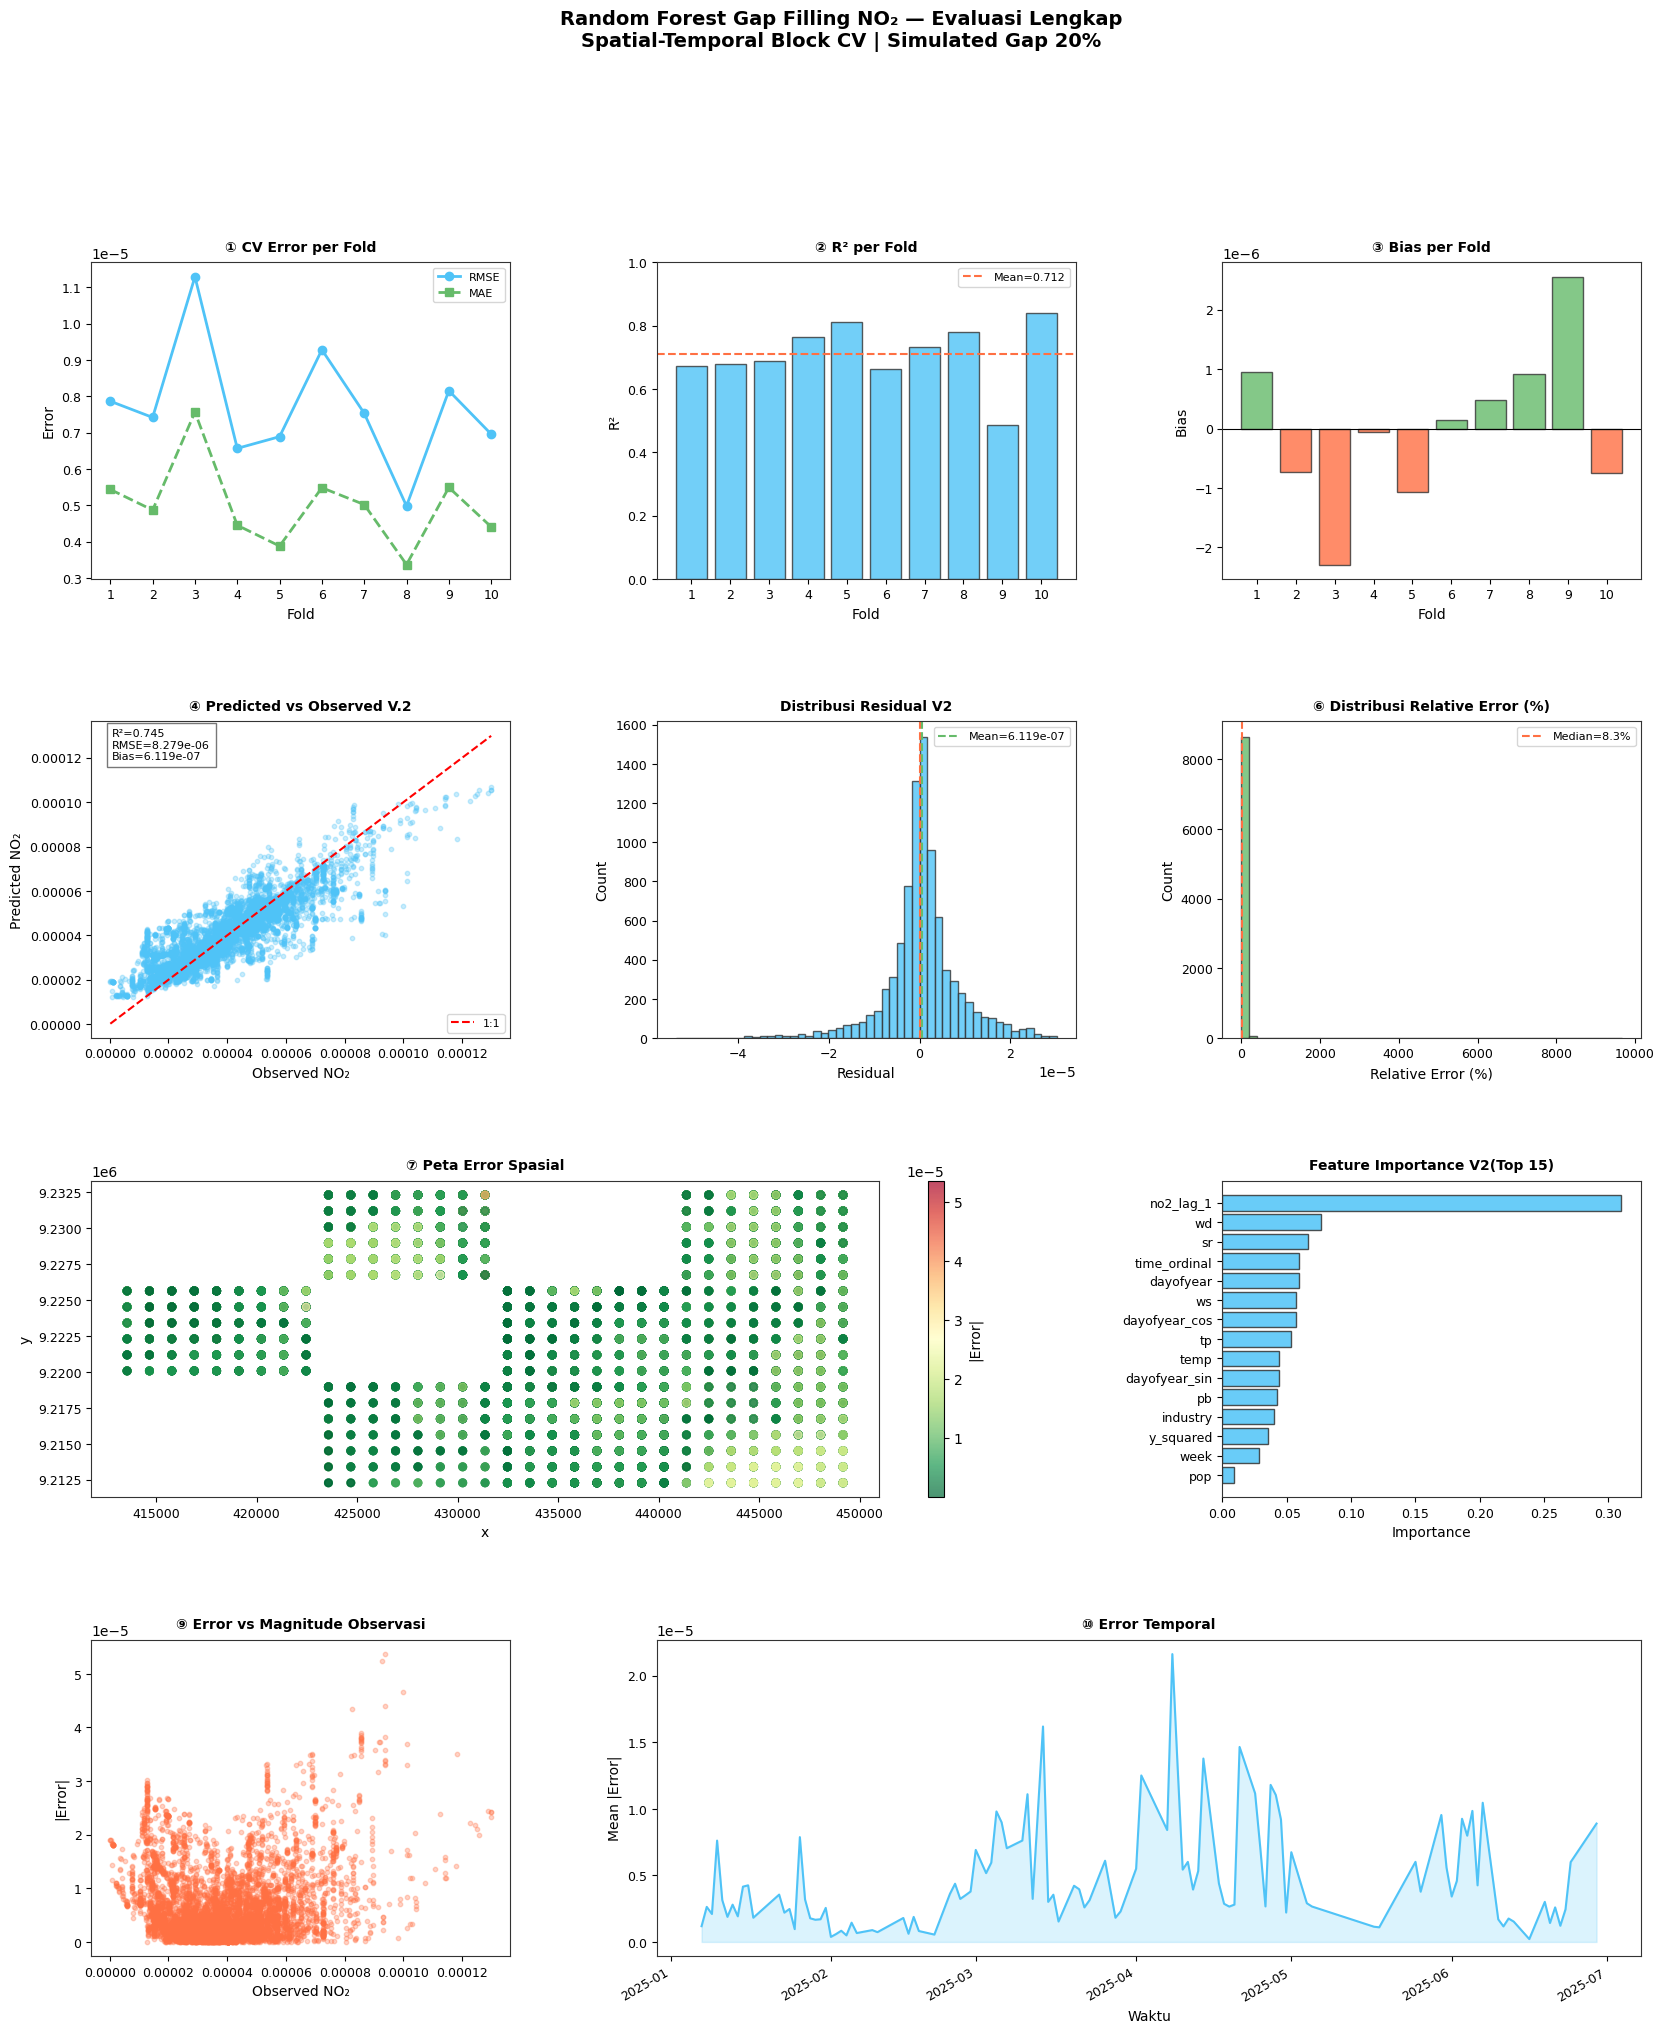

✅ Selesai.


In [72]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

error_v2     = y_pred_test_v2 - y_test_v2
rel_errorv2 = np.abs(error_v2) / (np.abs(y_test_v2) + 1e-12) * 100

DARK  = "#ffffff"; PANEL = "#ffffff"
ACCENT= '#4fc3f7'; WARN  = '#ff7043'
GREEN = '#66bb6a'; TEXT  = "#000000"

def style_ax(ax, title):
    ax.set_facecolor(PANEL)
    ax.tick_params(colors=TEXT, labelsize=9)
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)
    ax.set_title(title, fontsize=10, fontweight='bold', color=TEXT, pad=8)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333')

fig = plt.figure(figsize=(20, 22))
fig.patch.set_facecolor(DARK)
gs  = gridspec.GridSpec(4, 3, figure=fig, hspace=0.45, wspace=0.35)

# ① CV RMSE & MAE
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(cv_df_v2['fold'], cv_df_v2['RMSE'], 'o-', color=ACCENT, label='RMSE', lw=2)
ax1.plot(cv_df_v2['fold'], cv_df_v2['MAE'],  's--', color=GREEN, label='MAE',  lw=2)
ax1.set_xlabel('Fold'); ax1.set_ylabel('Error')
ax1.legend(facecolor=PANEL, labelcolor=TEXT, fontsize=8)
ax1.set_xticks(cv_df_v2['fold'])
style_ax(ax1, '① CV Error per Fold')

# ② R² per Fold
ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(cv_df_v2['fold'], cv_df_v2['R2'], color=ACCENT, alpha=0.8, edgecolor='#333')
ax2.axhline(cv_df_v2['R2'].mean(), color=WARN, ls='--', lw=1.5,
            label=f"Mean={cv_df_v2['R2'].mean():.3f}")
ax2.set_ylim(0, 1); ax2.set_xlabel('Fold'); ax2.set_ylabel('R²')
ax2.legend(facecolor=PANEL, labelcolor=TEXT, fontsize=8)
ax2.set_xticks(cv_df_v2['fold'])
style_ax(ax2, '② R² per Fold')

# ③ Bias per Fold
ax3 = fig.add_subplot(gs[0, 2])
colors_b = [GREEN if b >= 0 else WARN for b in cv_df_v2['Bias']]
ax3.bar(cv_df_v2['fold'], cv_df_v2['Bias'], color=colors_b, alpha=0.8, edgecolor='#333')
ax3.axhline(0, color=TEXT, lw=0.8)
ax3.set_xlabel('Fold'); ax3.set_ylabel('Bias')
ax3.set_xticks(cv_df_v2['fold'])
style_ax(ax3, '③ Bias per Fold')

# ④ Scatter Predicted vs Observed
ax4 = fig.add_subplot(gs[1, 0])
ax4.scatter(y_test_v2, y_pred_test_v2, alpha=0.3, s=10, color=ACCENT)
lims = [min(y_test_v2.min(), y_pred_test_v2.min()), max(y_test_v2.max(), y_pred_test_v2.max())]
ax4.plot(lims, lims, 'r--', lw=1.5, label='1:1')
ax4.text(0.05, 0.88,
         f"R²={r2_fv2:.3f}\nRMSE={rmse_fv2:.3e}\nBias={bias_fv2:.3e}",
         transform=ax4.transAxes, color=TEXT, fontsize=8,
         bbox=dict(facecolor=PANEL, edgecolor='#555', alpha=0.8))
ax4.set_xlabel('Observed NO₂'); ax4.set_ylabel('Predicted NO₂')
ax4.legend(facecolor=PANEL, labelcolor=TEXT, fontsize=8)
style_ax(ax4, '④ Predicted vs Observed V.2')

# ⑤ Distribusi Residual
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(error_v2, bins=50, color=ACCENT, alpha=0.8, edgecolor='#333')
ax5.axvline(0, color=WARN, ls='--', lw=1.5)
ax5.axvline(error_v2.mean(), color=GREEN, ls='--', lw=1.5,
            label=f'Mean={error_v2.mean():.3e}')
ax5.set_xlabel('Residual'); ax5.set_ylabel('Count')
ax5.legend(facecolor=PANEL, labelcolor=TEXT, fontsize=8)
style_ax(ax5, 'Distribusi Residual V2')

# ⑥ Relative Error
ax6 = fig.add_subplot(gs[1, 2])
ax6.hist(rel_errorv2, bins=50, color=GREEN, alpha=0.8, edgecolor='#333')
ax6.axvline(np.median(rel_errorv2), color=WARN, ls='--', lw=1.5,
            label=f'Median={np.median(rel_errorv2):.1f}%')
ax6.set_xlabel('Relative Error (%)'); ax6.set_ylabel('Count')
ax6.legend(facecolor=PANEL, labelcolor=TEXT, fontsize=8)
style_ax(ax6, '⑥ Distribusi Relative Error (%)')

# ⑦ Peta Error Spasial
ax7 = fig.add_subplot(gs[2, :2])
sc = ax7.scatter(test_data_v2['x'], test_data_v2['y'],
                 c=np.abs(error_v2), cmap='RdYlGn_r', s=30, alpha=0.7)
cbar = plt.colorbar(sc, ax=ax7)
cbar.set_label('|Error|', color=TEXT)
cbar.ax.yaxis.set_tick_params(color=TEXT)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=TEXT)
ax7.set_xlabel('x'); ax7.set_ylabel('y')
style_ax(ax7, '⑦ Peta Error Spasial')

# ⑧ Feature Importance
ax8 = fig.add_subplot(gs[2, 2])
feat_imp = pd.DataFrame({
    'feature': selected_features_v2,
    'importance': best_rfv2.feature_importances_
}).sort_values('importance').tail(15)
ax8.barh(feat_imp['feature'], feat_imp['importance'],
         color=ACCENT, alpha=0.85, edgecolor='#333')
ax8.set_xlabel('Importance')
style_ax(ax8, 'Feature Importance V2(Top 15)')

# ⑨ Error vs Magnitude
ax9 = fig.add_subplot(gs[3, 0])
ax9.scatter(y_test_v2, np.abs(error_v2), alpha=0.3, s=10, color=WARN)
ax9.set_xlabel('Observed NO₂'); ax9.set_ylabel('|Error|')
style_ax(ax9, '⑨ Error vs Magnitude Observasi')

# ⑩ Temporal Error
ax10 = fig.add_subplot(gs[3, 1:])
test_data = test_data_v2.copy()
test_data['abs_error'] = np.abs(error_v2)
temp_err = test_data.groupby('time')['abs_error'].mean().reset_index()
ax10.plot(temp_err['time'], temp_err['abs_error'], color=ACCENT, lw=1.5)
ax10.fill_between(temp_err['time'], temp_err['abs_error'], alpha=0.2, color=ACCENT)
ax10.set_xlabel('Waktu'); ax10.set_ylabel('Mean |Error|')
plt.setp(ax10.xaxis.get_majorticklabels(), rotation=30, ha='right')
style_ax(ax10, '⑩ Error Temporal')

fig.suptitle(
    'Random Forest Gap Filling NO₂ — Evaluasi Lengkap\n'
    'Spatial-Temporal Block CV | Simulated Gap 20%',
    fontsize=14, fontweight='bold', color=TEXT, y=0.995
)

plt.savefig('rf_gapfill_evaluation.png', dpi=150,
            bbox_inches='tight', facecolor=DARK)
plt.show()
print("✅ Selesai.")

# **Model RFSTK V3**

In [81]:
from pykrige.ok import OrdinaryKriging
from pykrige.uk import UniversalKriging
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

In [82]:
# Best variogram
def best_variogram(x, y, z, models=['spherical', 'exponential', 'gaussian'], nlags=15):
    best_model, best_rmse = None, np.inf
    for vm in models:
        try:
            ok = OrdinaryKriging(x, y, z,
                                 variogram_model=vm,
                                 verbose=False, enable_plotting=False,
                                 nlags=nlags, weight=True)
            rmse = np.sqrt(np.mean((ok.delta - ok.gamma) ** 2))
            if rmse < best_rmse:
                best_rmse, best_model = rmse, vm
        except:
            continue
    return best_model if best_model else 'spherical'  # fallback


In [83]:
# Train RF OOB True

rfstk = RandomForestRegressor(
        **random_searchv2.best_params_,
    n_jobs=-1,
    random_state=42,
    oob_score=True
)
rfstk.fit(X_train_v2, y_train_v2)
oob_pred = rfstk.oob_prediction_

# Cek NaN in OOB Prediction
nan_count = np.isnan(oob_pred).sum()
if nan_count > 0:
    print(f"  OOB prediction has {nan_count} NaN from {len(oob_pred)} sample")
    print(f"  Fill NaN with common prediction (in-bag)")
    oob_pred = np.where(np.isnan(oob_pred), rfstk.predict(X_train_v2), oob_pred)
else:
    print(f" OOB prediction clean — no NaN ({len(oob_pred)} sample)")

y_pred_train_v2 = rfstk.predict(X_train_v2)
oob_errors = y_train_v2.values - oob_pred     # ε_OOB per training sample
oob_std = oob_errors.std()
oob_r2 = rfstk.oob_score_
fit_res = y_train_v2.values - y_pred_train_v2  # ε_fitting per training sample

print("=== OOB vs Fitting Residual ===")
print(f"  Mean |fitting residual| : {np.abs(fit_res).mean():.4e}")
print(f"  Mean |OOB error|        : {np.abs(oob_errors).mean():.4e}")
print(f"  Ratio OOB / fitting     : {np.abs(oob_errors).mean()/np.abs(fit_res).mean():.2f}x")
print(f"  OOB R²                  : {oob_r2:.4f}")

 OOB prediction clean — no NaN (55694 sample)
=== OOB vs Fitting Residual ===
  Mean |fitting residual| : 2.6117e-06
  Mean |OOB error|        : 2.9608e-06
  Ratio OOB / fitting     : 1.13x
  OOB R²                  : 0.9087


In [85]:
# Step 2: Daily Kriging → Final Test
model_results_v3 = []   
train_reset          = train_data_v2.reset_index(drop=True)
test_reset           = test_data_v2.reset_index(drop=True)
train_reset['oob_error'] = oob_errors

y_rfbase_all = rfstk.predict(X_test_v2)
y_rfstk_all  = np.full(len(test_reset), np.nan)

for i, date in enumerate(sorted(test_reset['time'].unique())):
    tr_day = train_reset[train_reset['time'] == date]
    te_day = test_reset[test_reset['time'] == date]

    te_idx = te_day.index.values

    if len(tr_day) < 4:
        y_rfstk_all[te_idx] = y_rfbase_all[te_idx]
        continue

    try:
        vm = best_variogram(tr_day['x'].values, tr_day['y'].values,
                            tr_day['oob_error'].values)
        
        ok_day = OrdinaryKriging(
            tr_day['x'].values, tr_day['y'].values,
            tr_day['oob_error'].values,
            variogram_model=vm,
            verbose=False, enable_plotting=False,
            nlags=15, weight=True
        )
        err_interp, _ = ok_day.execute('points', te_day['x'].values, te_day['y'].values)
        err_clip = np.clip(err_interp.data, -3*oob_std, 3*oob_std)
        y_rfstk_all[te_idx] = np.clip(y_rfbase_all[te_idx] + err_clip, 0, None) # fungsi rfstk 

    except Exception as e:
        y_rfstk_all[te_idx] = y_rfbase_all[te_idx]

nan_mask = np.isnan(y_rfstk_all)
y_rfstk_all[nan_mask] = y_rfbase_all[nan_mask]

# Step 3: Final Test Evaluation
print(f"\n{'='*55}")
print(f"  Final Test — RF baseline vs RF-STK")
print(f"{'='*55}")
print(f"  {'Metric':<12} {'RF baseline':>14} {'RF-STK':>14}")
print(f"  {'─'*42}")
print(f"  {'R²':<12} {r2_score(y_test_v2, y_rfbase_all):>14.4f} {r2_score(y_test_v2, y_rfstk_all):>14.4f}")
print(f"  {'RMSE':<12} {np.sqrt(mean_squared_error(y_test_v2, y_rfbase_all)):>14.4e} {np.sqrt(mean_squared_error(y_test_v2, y_rfstk_all)):>14.4e}")
print(f"  {'MAE':<12} {mean_absolute_error(y_test_v2, y_rfbase_all):>14.4e} {mean_absolute_error(y_test_v2, y_rfstk_all):>14.4e}")
print(f"  {'Bias':<12} {(y_rfbase_all - y_test_v2).mean():>14.4e} {(y_rfstk_all - y_test_v2).mean():>14.4e}")

r2_rfstk = r2_score(y_test_v2, y_rfstk_all)
rmse_rfstk = np.sqrt(mean_squared_error(y_test_v2, y_rfstk_all))
mae_rfstk  = mean_absolute_error(y_test_v2, y_rfstk_all)
bias_rfstk = (y_rfstk_all - y_test_v2).mean()

print(f"\nRF-STK — R²: {r2_rfstk:.4f} | RMSE: {rmse_rfstk:.4e} | MAE: {mae_rfstk:.4e} | Bias: {bias_rfstk:.4e}")

model_results_v3.append({
    'R2': r2_score(y_test_v2, y_rfstk_all),
    'RMSE': np.sqrt(mean_squared_error(y_test_v2, y_rfstk_all)),
    'MAE': mean_absolute_error(y_test_v2, y_rfstk_all),
        'Bias': (y_rfstk_all - y_test_v2).mean(),
        'OOB_R2': rfstk.oob_score_,
        'RPE': (
        ((y_rfstk_all - y_test_v2)) / (y_test_v2 + 1e-12)
    ).mean() * 100,
        'Slope': np.polyfit(y_rfstk_all, y_test_v2, 1)[0]})
    
model_df_v3 = pd.DataFrame(model_results_v3)

# Daily best variogram
variogram_summary = []
for date in sorted(train_reset['time'].unique()):
    tr_day = train_reset[train_reset['time'] == date]
    if len(tr_day) < 4:
        variogram_summary.append({'time': date, 'variogram': 'N/A'})
        continue
    vm = best_variogram(tr_day['x'].values, tr_day['y'].values, tr_day['oob_error'].values)
    variogram_summary.append({'time': date, 'variogram': vm})
variogram_df = pd.DataFrame(variogram_summary)
print(f"\nVariogram terbaik per hari: {variogram_df['variogram'].value_counts().to_dict()}")



  Final Test — RF baseline vs RF-STK
  Metric          RF baseline         RF-STK
  ──────────────────────────────────────────
  R²                   0.7448         0.8170
  RMSE             8.2794e-06     7.0114e-06
  MAE              5.4253e-06     4.3695e-06
  Bias             6.1192e-07     2.5448e-07

RF-STK — R²: 0.8170 | RMSE: 7.0114e-06 | MAE: 4.3695e-06 | Bias: 2.5448e-07

Variogram terbaik per hari: {'spherical': 172, 'N/A': 3}


In [86]:
# Step 4: CV ST-Block 
print(f"\n{'='*60}")
print(f"  10-Fold ST-Block CV RF-STK (Daily Kriging)")
print(f"{'='*60}")
print(f"Unique ST blocks di train: {groups_v2.nunique()}")

gkf_stk      = GroupKFold(n_splits=10)
cv_stk_results = []

for fold, (tr_idx, val_idx) in enumerate(gkf_stk.split(X_train_v2, y_train_v2, groups=groups_v2)):

    X_tr  = X_train_v2.iloc[tr_idx]
    X_val = X_train_v2.iloc[val_idx]
    y_tr  = y_train_v2.iloc[tr_idx].values
    y_val = y_train_v2.iloc[val_idx].values

    tr_df  = train_data_v2.iloc[tr_idx].copy().reset_index(drop=True)
    val_df = train_data_v2.iloc[val_idx].copy().reset_index(drop=True)

    rf_cv = RandomForestRegressor(
        **random_searchv2.best_params_,
        oob_score=True, n_jobs=-1, random_state=42
    )
    rf_cv.fit(X_tr, y_tr)

    oob_e    = y_tr - rf_cv.oob_prediction_
    oob_std_cv = oob_e.std()
    y_rf_val = rf_cv.predict(X_val)
    tr_df['oob_error'] = oob_e

    y_pred_cv = y_rf_val.copy().astype(float)

    for date in val_df['time'].unique(): # ini yg bingung
        tr_day  = tr_df[tr_df['time'] == date]
        val_day = val_df[val_df['time'] == date]

        if len(tr_day) < 4 or len(val_day) == 0:
            continue

        try:
            vm = best_variogram(tr_day['x'].values, tr_day['y'].values,
                                tr_day['oob_error'].values)
            
            ok_day = OrdinaryKriging(
                tr_day['x'].values, tr_day['y'].values,
                tr_day['oob_error'].values,
                variogram_model=vm,
                verbose=False, enable_plotting=False,
                nlags=15, weight=True
            )
            err_interp, _ = ok_day.execute(
                'points', val_day['x'].values, val_day['y'].values
            )
            err_clip  = np.clip(err_interp.data, -3*oob_std_cv, 3*oob_std_cv)
            local_idx = val_day.index.values
            y_pred_cv[local_idx] = np.clip(y_rf_val[local_idx] + err_clip, 0, None)

        except Exception:
            continue

    rmse  = np.sqrt(mean_squared_error(y_val, y_pred_cv))
    mae   = mean_absolute_error(y_val, y_pred_cv)
    r2    = r2_score(y_val, y_pred_cv)
    bias  = (y_pred_cv - y_val).mean()
    rpe = (
        (y_pred_cv - y_val) / (y_val + 1e-12)
    ).mean() * 100
    slope = np.polyfit(y_val, y_pred_cv, 1)[0]
    smape = (
        np.abs(y_pred_cv - y_val) /
        (np.abs(y_val) + np.abs(y_pred_cv) + 1e-12)
    ).mean() * 200

    cv_stk_results.append({'fold': fold+1, 'RMSE': rmse, 'MAE': mae,
                            'R2': r2, 'Bias': bias, 'sMAPE': smape, 'RPE': rpe, 'Slope': slope})
    print(f"  Fold {fold+1}: R²={r2:.4f} | RMSE={rmse:.4e} | MAE={mae:.4e} | Bias={bias:.4e} | sMAPE={smape:.2f}%")

cv_stk_df = pd.DataFrame(cv_stk_results)
print(f"\n{'─'*55}")
print(f"  Mean R²   : {cv_stk_df['R2'].mean():.4f} ± {cv_stk_df['R2'].std():.4f}")
print(f"  Mean RMSE : {cv_stk_df['RMSE'].mean():.4e} ± {cv_stk_df['RMSE'].std():.4e}")
print(f"  Mean MAE  : {cv_stk_df['MAE'].mean():.4e} ± {cv_stk_df['MAE'].std():.4e}")
print(f"  Mean sMAPE: {cv_stk_df['sMAPE'].mean():.2f}% ± {cv_stk_df['sMAPE'].std():.2f}%")


  10-Fold ST-Block CV RF-STK (Daily Kriging)
Unique ST blocks di train: 39
  Fold 1: R²=0.7396 | RMSE=7.0304e-06 | MAE=4.4825e-06 | Bias=1.0733e-06 | sMAPE=13.37%
  Fold 2: R²=0.7752 | RMSE=6.1946e-06 | MAE=3.8226e-06 | Bias=-6.6994e-07 | sMAPE=10.61%
  Fold 3: R²=0.7924 | RMSE=9.2276e-06 | MAE=5.9685e-06 | Bias=-1.1900e-06 | sMAPE=14.60%
  Fold 4: R²=0.8127 | RMSE=5.8685e-06 | MAE=3.6583e-06 | Bias=-1.6099e-09 | sMAPE=14.33%
  Fold 5: R²=0.8838 | RMSE=5.3996e-06 | MAE=2.7811e-06 | Bias=-5.1991e-07 | sMAPE=7.63%
  Fold 6: R²=0.7389 | RMSE=8.1768e-06 | MAE=4.2062e-06 | Bias=-1.2962e-07 | sMAPE=12.46%
  Fold 7: R²=0.8131 | RMSE=6.2924e-06 | MAE=3.8985e-06 | Bias=3.4941e-07 | sMAPE=13.08%
  Fold 8: R²=0.8432 | RMSE=4.1973e-06 | MAE=2.7762e-06 | Bias=7.1379e-07 | sMAPE=11.48%
  Fold 9: R²=0.7130 | RMSE=6.0950e-06 | MAE=3.7936e-06 | Bias=1.5246e-06 | sMAPE=13.06%
  Fold 10: R²=0.9103 | RMSE=5.2081e-06 | MAE=3.1923e-06 | Bias=-4.3861e-07 | sMAPE=10.02%

─────────────────────────────────────

In [87]:
metrics = ['R2']

print(f"\n{'='*55}")
print(f"  Summary CV (Mean ± Std)")
print(f"{'='*55}")
for m in metrics:
    mean_val = cv_stk_df[m].mean()
    std_val  = cv_stk_df[m].std()          # std default ddof=1
    if m in ('R2',):
        print(f"  {m:<6}: {mean_val:.4f} ± {std_val:.4f}")
    else:
        print(f"  {m:<6}: {mean_val:.4e} ± {std_val:.4e}")
print(f"{'='*55}")


  Summary CV (Mean ± Std)
  R2    : 0.8022 ± 0.0641


In [88]:
# Check range average variogram spherical in all days
range_log = []

for date in sorted(train_reset['time'].unique()):
    tr_day = train_reset[train_reset['time'] == date]
    if len(tr_day) < 4:
        continue
    try:
        ok = OrdinaryKriging(
            tr_day['x'].values, tr_day['y'].values,
            tr_day['oob_error'].values,
            variogram_model='spherical',
            verbose=False, enable_plotting=False,
            nlags=15, weight=True
        )
        # parameter: [sill, range, nugget]
        sill   = ok.variogram_model_parameters[0]
        range_ = ok.variogram_model_parameters[1]
        nugget = ok.variogram_model_parameters[2]
        range_log.append({
            'date': date,
            'sill': sill,
            'range_km': range_,
            'nugget': nugget,
            'nugget_ratio': nugget / (sill + nugget + 1e-12)
        })
    except:
        continue

range_df = pd.DataFrame(range_log)
print(range_df[['sill','range_km','nugget','nugget_ratio']].describe())

               sill      range_km        nugget  nugget_ratio
count  1.720000e+02    172.000000  1.720000e+02    172.000000
mean   8.927283e-11   8033.806020  2.226583e-11      0.153978
std    8.624222e-11   2768.252718  2.846541e-11      0.108610
min    4.311691e-13    834.900000  4.311691e-14      0.029246
25%    4.434284e-11   6520.041844  4.434284e-12      0.085598
50%    1.000000e-10   8999.676021  1.039666e-11      0.092934
75%    1.000000e-10  10150.415280  2.811178e-11      0.215901
max    1.021216e-09  10626.275491  1.000000e-10      0.497512


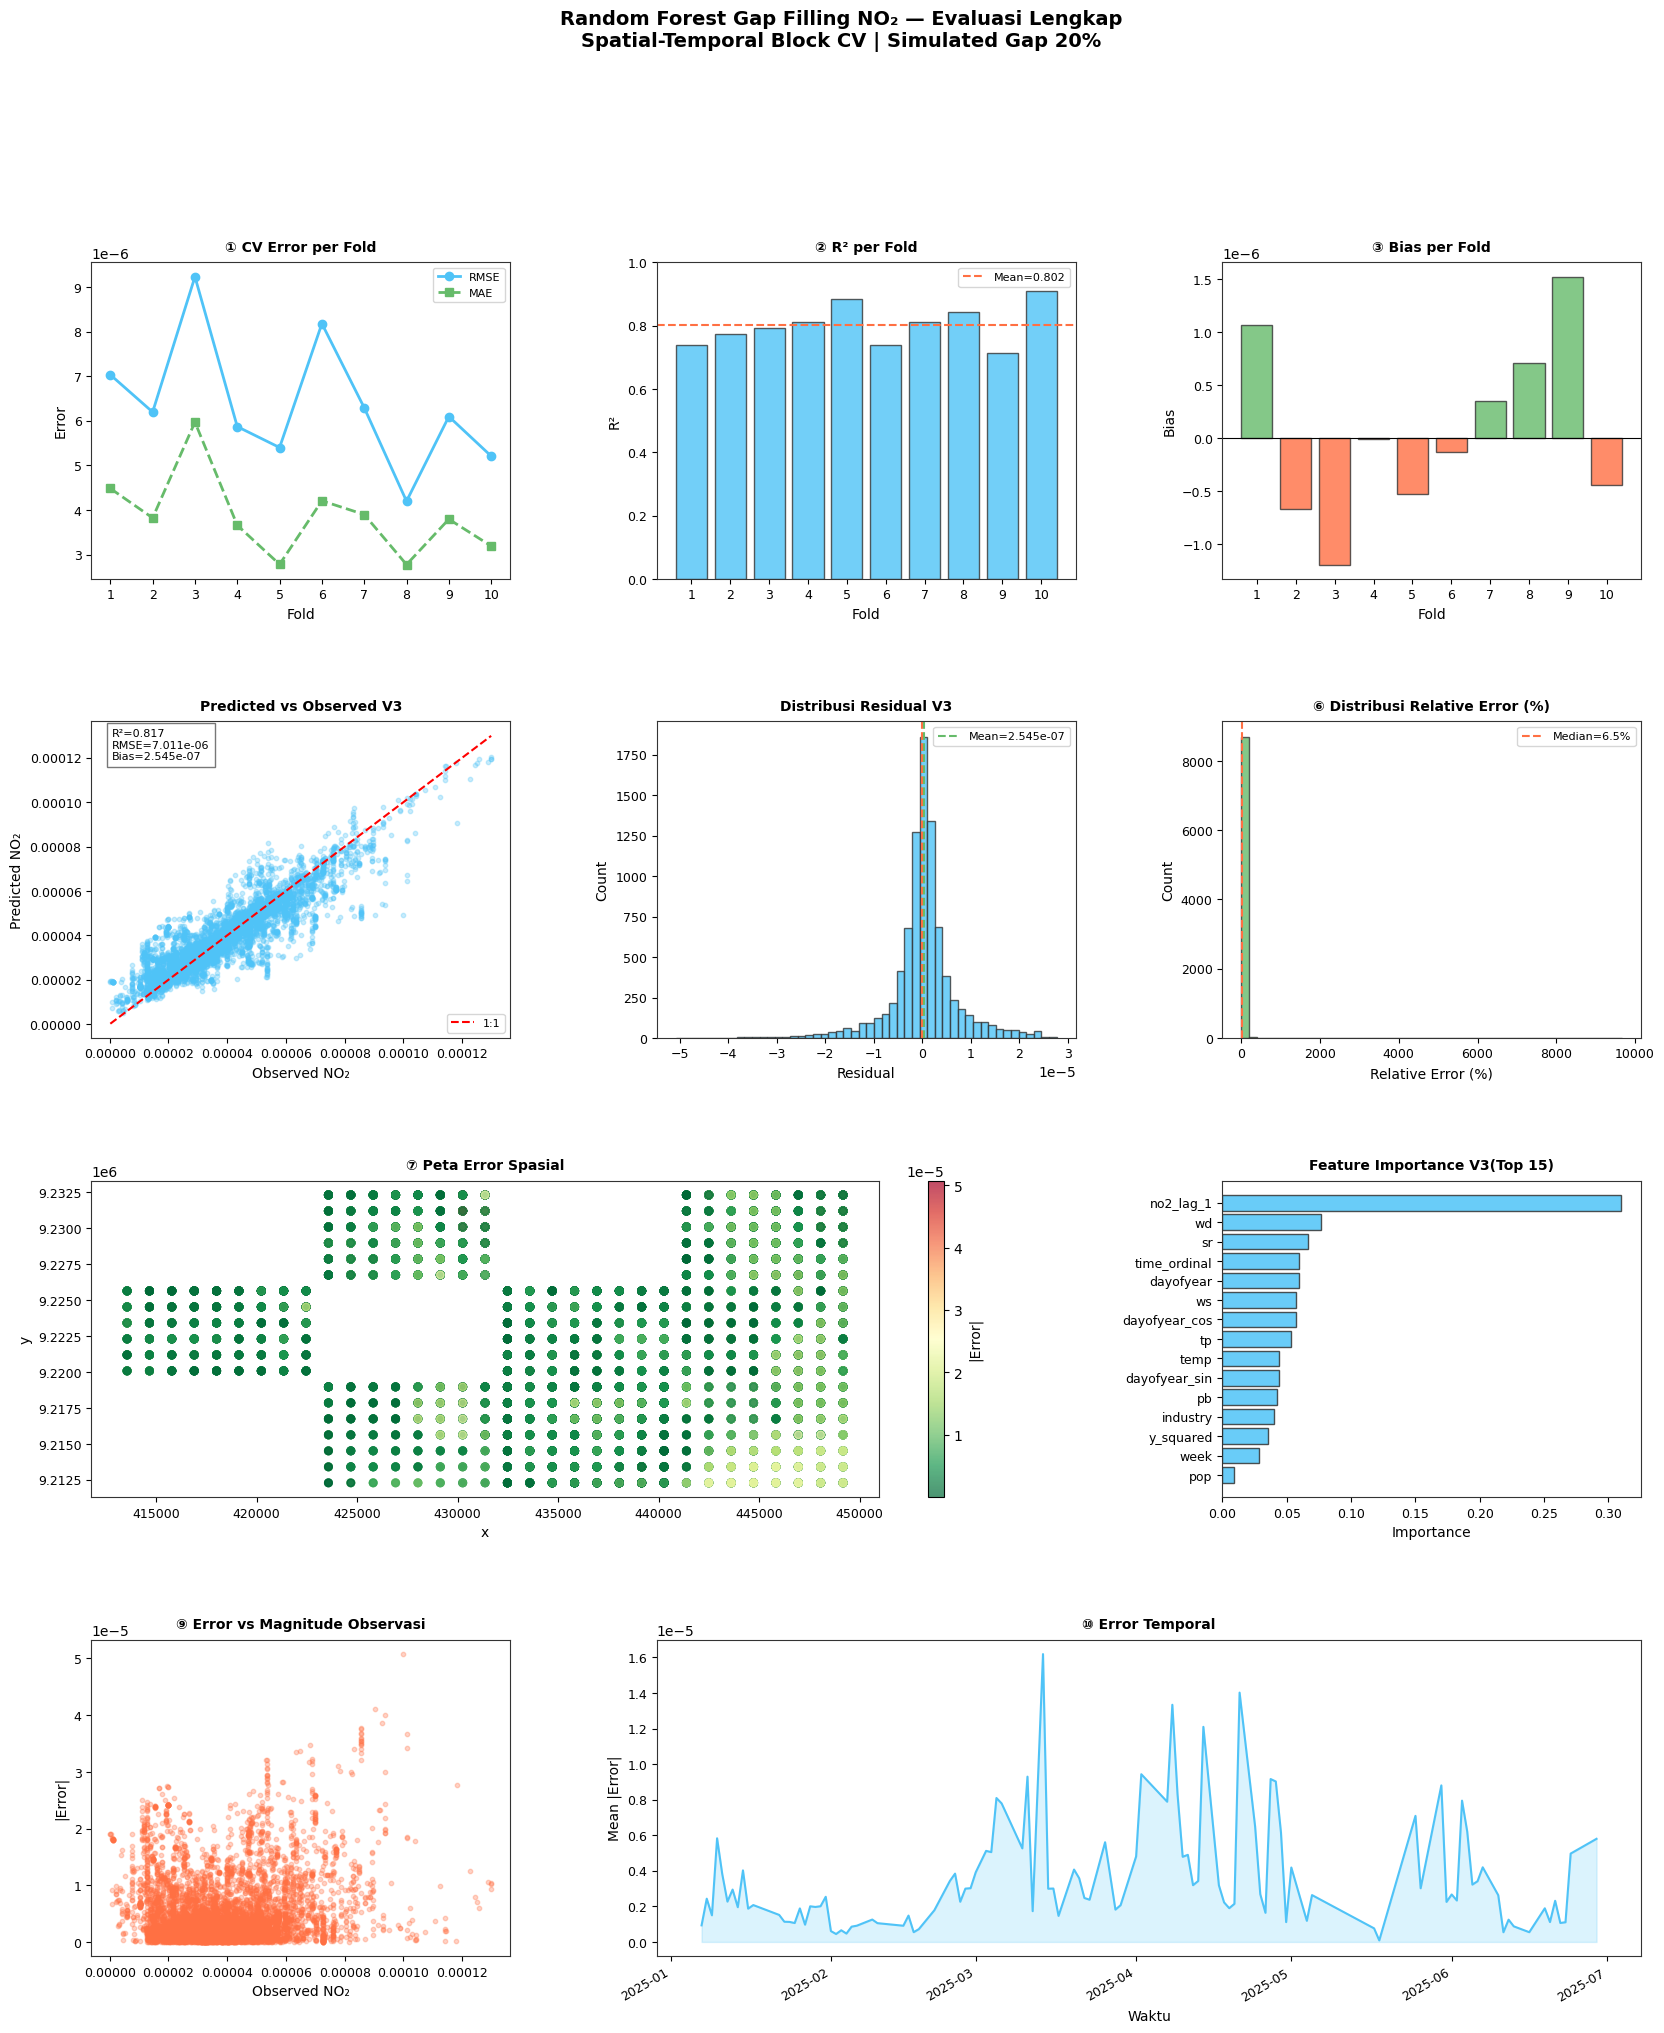

✅ Selesai.


In [89]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

error     = y_rfstk_all - y_test_v2
rel_error = np.abs(error) / (np.abs(y_test_v2) + 1e-12) * 100

DARK  = "#ffffff"; PANEL = "#ffffff"
ACCENT= '#4fc3f7'; WARN  = '#ff7043'
GREEN = '#66bb6a'; TEXT  = "#000000"

def style_ax(ax, title):
    ax.set_facecolor(PANEL)
    ax.tick_params(colors=TEXT, labelsize=9)
    ax.xaxis.label.set_color(TEXT)
    ax.yaxis.label.set_color(TEXT)
    ax.set_title(title, fontsize=10, fontweight='bold', color=TEXT, pad=8)
    for spine in ax.spines.values():
        spine.set_edgecolor('#333')

fig = plt.figure(figsize=(20, 22))
fig.patch.set_facecolor(DARK)
gs  = gridspec.GridSpec(4, 3, figure=fig, hspace=0.45, wspace=0.35)

# ① CV RMSE & MAE
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(cv_stk_df['fold'], cv_stk_df['RMSE'], 'o-', color=ACCENT, label='RMSE', lw=2)
ax1.plot(cv_stk_df['fold'], cv_stk_df['MAE'],  's--', color=GREEN, label='MAE',  lw=2)
ax1.set_xlabel('Fold'); ax1.set_ylabel('Error')
ax1.legend(facecolor=PANEL, labelcolor=TEXT, fontsize=8)
ax1.set_xticks(cv_stk_df['fold'])
style_ax(ax1, '① CV Error per Fold')

# ② R² per Fold
ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(cv_stk_df['fold'], cv_stk_df['R2'], color=ACCENT, alpha=0.8, edgecolor='#333')
ax2.axhline(cv_stk_df['R2'].mean(), color=WARN, ls='--', lw=1.5,
            label=f"Mean={cv_stk_df['R2'].mean():.3f}")
ax2.set_ylim(0, 1); ax2.set_xlabel('Fold'); ax2.set_ylabel('R²')
ax2.legend(facecolor=PANEL, labelcolor=TEXT, fontsize=8)
ax2.set_xticks(cv_stk_df['fold'])
style_ax(ax2, '② R² per Fold')

# ③ Bias per Fold
ax3 = fig.add_subplot(gs[0, 2])
colors_b = [GREEN if b >= 0 else WARN for b in cv_stk_df['Bias']]
ax3.bar(cv_stk_df['fold'], cv_stk_df['Bias'], color=colors_b, alpha=0.8, edgecolor='#333')
ax3.axhline(0, color=TEXT, lw=0.8)
ax3.set_xlabel('Fold'); ax3.set_ylabel('Bias')
ax3.set_xticks(cv_stk_df['fold'])
style_ax(ax3, '③ Bias per Fold')

# ④ Scatter Predicted vs Observed
ax4 = fig.add_subplot(gs[1, 0])
ax4.scatter(y_test_v2, y_rfstk_all, alpha=0.3, s=10, color=ACCENT)
lims = [min(y_test_v2.min(), y_rfstk_all.min()), max(y_test_v2.max(), y_rfstk_all.max())]
ax4.plot(lims, lims, 'r--', lw=1.5, label='1:1')
ax4.text(0.05, 0.88,
         f"R²={r2_rfstk:.3f}\nRMSE={rmse_rfstk:.3e}\nBias={bias_rfstk:.3e}",
         transform=ax4.transAxes, color=TEXT, fontsize=8,
         bbox=dict(facecolor=PANEL, edgecolor='#555', alpha=0.8))
ax4.set_xlabel('Observed NO₂'); ax4.set_ylabel('Predicted NO₂')
ax4.legend(facecolor=PANEL, labelcolor=TEXT, fontsize=8)
style_ax(ax4, 'Predicted vs Observed V3')

# ⑤ Distribusi Residual
ax5 = fig.add_subplot(gs[1, 1])
ax5.hist(error, bins=50, color=ACCENT, alpha=0.8, edgecolor='#333')
ax5.axvline(0, color=WARN, ls='--', lw=1.5)
ax5.axvline(error.mean(), color=GREEN, ls='--', lw=1.5,
            label=f'Mean={error.mean():.3e}')
ax5.set_xlabel('Residual'); ax5.set_ylabel('Count')
ax5.legend(facecolor=PANEL, labelcolor=TEXT, fontsize=8)
style_ax(ax5, 'Distribusi Residual V3')

# ⑥ Relative Error
ax6 = fig.add_subplot(gs[1, 2])
ax6.hist(rel_error, bins=50, color=GREEN, alpha=0.8, edgecolor='#333')
ax6.axvline(np.median(rel_error), color=WARN, ls='--', lw=1.5,
            label=f'Median={np.median(rel_error):.1f}%')
ax6.set_xlabel('Relative Error (%)'); ax6.set_ylabel('Count')
ax6.legend(facecolor=PANEL, labelcolor=TEXT, fontsize=8)
style_ax(ax6, '⑥ Distribusi Relative Error (%)')

# ⑦ Peta Error Spasial
ax7 = fig.add_subplot(gs[2, :2])
sc = ax7.scatter(test_data_v2['x'], test_data_v2['y'],
                 c=np.abs(error), cmap='RdYlGn_r', s=30, alpha=0.7)
cbar = plt.colorbar(sc, ax=ax7)
cbar.set_label('|Error|', color=TEXT)
cbar.ax.yaxis.set_tick_params(color=TEXT)
plt.setp(cbar.ax.yaxis.get_ticklabels(), color=TEXT)
ax7.set_xlabel('x'); ax7.set_ylabel('y')
style_ax(ax7, '⑦ Peta Error Spasial')

# ⑧ Feature Importance
ax8 = fig.add_subplot(gs[2, 2])
feat_imp = pd.DataFrame({
    'feature': selected_features_v2,
    'importance': rfstk.feature_importances_
}).sort_values('importance').tail(15)
ax8.barh(feat_imp['feature'], feat_imp['importance'],
         color=ACCENT, alpha=0.85, edgecolor='#333')
ax8.set_xlabel('Importance')
style_ax(ax8, 'Feature Importance V3(Top 15)')

# ⑨ Error vs Magnitude
ax9 = fig.add_subplot(gs[3, 0])
ax9.scatter(y_test_v2, np.abs(error), alpha=0.3, s=10, color=WARN)
ax9.set_xlabel('Observed NO₂'); ax9.set_ylabel('|Error|')
style_ax(ax9, '⑨ Error vs Magnitude Observasi')

# ⑩ Temporal Error
ax10 = fig.add_subplot(gs[3, 1:])
test_data = test_data_v2.copy()
test_data['abs_error'] = np.abs(error)
temp_err = test_data.groupby('time')['abs_error'].mean().reset_index()
ax10.plot(temp_err['time'], temp_err['abs_error'], color=ACCENT, lw=1.5)
ax10.fill_between(temp_err['time'], temp_err['abs_error'], alpha=0.2, color=ACCENT)
ax10.set_xlabel('Waktu'); ax10.set_ylabel('Mean |Error|')
plt.setp(ax10.xaxis.get_majorticklabels(), rotation=30, ha='right')
style_ax(ax10, '⑩ Error Temporal')

fig.suptitle(
    'Random Forest Gap Filling NO₂ — Evaluasi Lengkap\n'
    'Spatial-Temporal Block CV | Simulated Gap 20%',
    fontsize=14, fontweight='bold', color=TEXT, y=0.995
)

plt.savefig('rf_gapfill_evaluation.png', dpi=150,
            bbox_inches='tight', facecolor=DARK)
plt.show()
print("✅ Selesai.")

"Perbandingan komprehensif antara model Random Forest (RF) baseline dan Random Forest Spatio-Temporal Kriging (RFSTK) dilakukan melalui dua skema evaluasi: 10-fold Spatial-Temporal Block Cross-Validation dan final test set (simulated gap 20%). Hasil CV menunjukkan peningkatan rata-rata R² dari 0,738 (±0,089) pada RF baseline menjadi 0,804 (±0,064) pada RFSTK, disertai penurunan RMSE sebesar 17,3% dan MAE sebesar 22,6%. Penurunan standar deviasi R² antar fold dari 0,089 menjadi 0,064 mengindikasikan bahwa koreksi kriging tidak hanya meningkatkan akurasi rata-rata, tetapi juga menstabilkan konsistensi performa model lintas periode waktu yang berbeda. Pada final test set, RFSTK mencapai R² = 0,815, RMSE = 7,052×10⁻⁶ mol/m², dan MAE = 4,347×10⁻⁶ mol/m², dengan bias yang tereduksi 82,3% dibandingkan RF baseline. Konsistensi antara hasil CV dan test set (gap R² < 0,015 untuk kedua model) mengonfirmasi validitas metodologi evaluasi dan kemampuan generalisasi model terhadap data spasio-temporal yang tidak terlihat selama pelatihan."

# **Model RF Gap Filling Final V.1**

In [53]:
# Gapfilling NaN Values
df_gap_rfv1 = df_temporalgap.copy()
mask_nan = df_gap_rfv1['no2_vcd_filled'].isna()

In [54]:
# Split
X_train_gapv1 = df_gap_rfv1.loc[~mask_nan, selected_features]
y_train_gapv1 = df_gap_rfv1.loc[~mask_nan, 'no2_vcd_filled']
X_test_gapv1  = df_gap_rfv1.loc[mask_nan, selected_features]

# Handle missing fitur
fill_median_v1 = X_train_gapv1.median()
X_train_gapv1 = X_train_gapv1.fillna(fill_median_v1)
X_test_gapv1  = X_test_gapv1.fillna(fill_median_v1)


gap_rfv1 = RandomForestRegressor(
    **random_search.best_params_,
    n_jobs=-1,
    random_state=42,
    oob_score=True
)
gap_rfv1.fit(X_train_gapv1, y_train_gapv1)
y_gap_rfv1 = gap_rfv1.predict(X_test_gapv1) # NaN prediction  

df_gap_rfv1.loc[mask_nan, 'no2_vcd_filled'] = y_gap_rfv1

print(" Gap filling done!")


 Gap filling done!


8.646980872792336e-05
7.349684547375595e-06


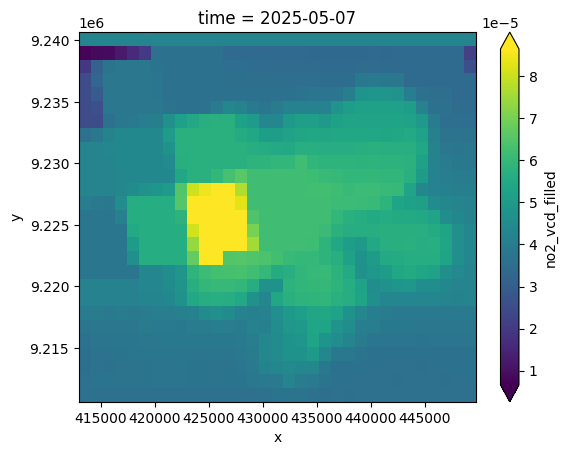

In [58]:
# Convert to Xarray
# Format time
df_gap_rfv1['time'] = pd.to_datetime(df_gap_rfv1['time'])

# convert to Xarray
ds_rfgapv1 = df_gap_rfv1.set_index(['time', 'y', 'x']).to_xarray()

# choose time
t = 126

max_val = ds_rfgapv1["no2_vcd_filled"].isel(time=t).max()
min_val = ds_rfgapv1["no2_vcd_filled"].isel(time=t).min()

ds_rfgapv1["no2_vcd_filled"].isel(time=t).plot(
    vmin=max_val,
    vmax=min_val,
    cmap="viridis"
)

print(max_val.values)
print(min_val.values)

# **Model RF Gap-Filling Final V.2**

In [90]:
# Gapfilling NaN Values
df_gap_rfv2 = df_temporalgap.copy()
mask_nan = df_gap_rfv2['no2_vcd_filled'].isna()


In [91]:

X_train_gap_v2 = df_gap_rfv2[~mask_nan][selected_features_v2]
y_train_gap_v2 = df_gap_rfv2[~mask_nan]['no2_vcd_filled']
X_test_gap_v2  = df_gap_rfv2[mask_nan][selected_features_v2]
y_test_gap_v2  = df_gap_rfv2[mask_nan]['no2_vcd_filled']

gap_rfv2 = RandomForestRegressor(
    **random_searchv2.best_params_,
    n_jobs=-1,
    random_state=42,
    oob_score=True
)
gap_rfv2.fit(X_train_gap_v2, y_train_gap_v2)
y_gap_rfv2 = gap_rfv2.predict(X_test_gap_v2) # NaN prediction

df_gap_rfv2.loc[mask_nan, 'no2_vcd_filled'] = y_gap_rfv2

print("Gap filling done!")


Gap filling done!


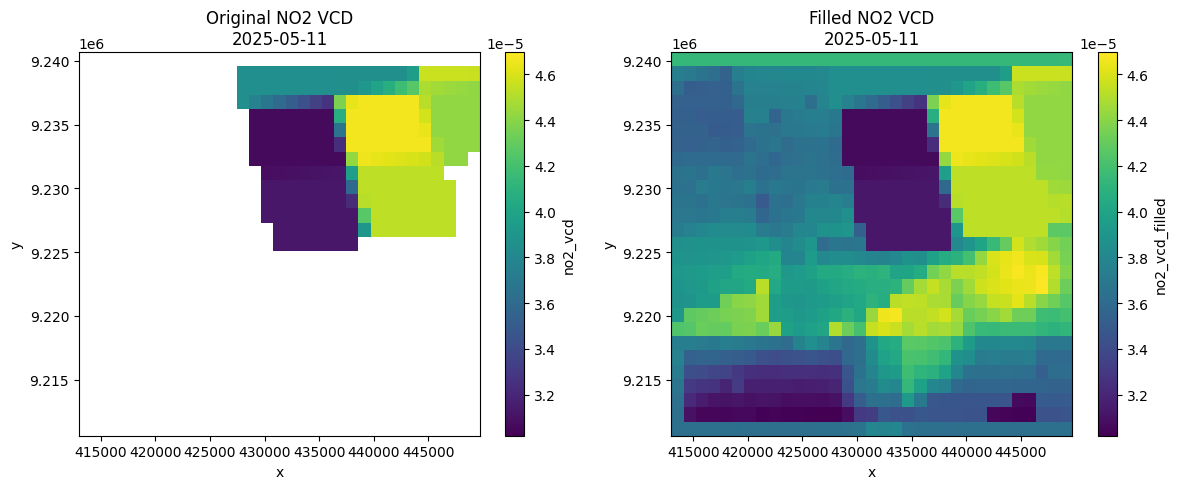

In [92]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# set time to datetime
df_gap_rfv2['time'] = pd.to_datetime(df_gap_rfv2['time'])

# Convert to xarray
ds_rfv2 = df_gap_rfv2.set_index(['time', 'y', 'x']).to_xarray()

# choose time
t = 130
tanggal = pd.to_datetime(ds_rfv2.time.values[t]).strftime("%Y-%m-%d")

# get data slice
orig = ds_rfv2['no2_vcd'].isel(time=t)
filled = ds_rfv2['no2_vcd_filled'].isel(time=t)

# define global scale color
vmin = np.nanmin([orig.min().values, filled.min().values])
vmax = np.nanmax([orig.max().values, filled.max().values])

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

orig.plot(
    ax=axes[0],
    cmap='viridis',
    vmin=vmin,
    vmax=vmax
)
axes[0].set_title(f'Original NO2 VCD\n{tanggal}')

filled.plot(
    ax=axes[1],
    cmap='viridis',
    vmin=vmin,
    vmax=vmax
)
axes[1].set_title(f'Filled NO2 VCD\n{tanggal}')

plt.tight_layout()
plt.show()

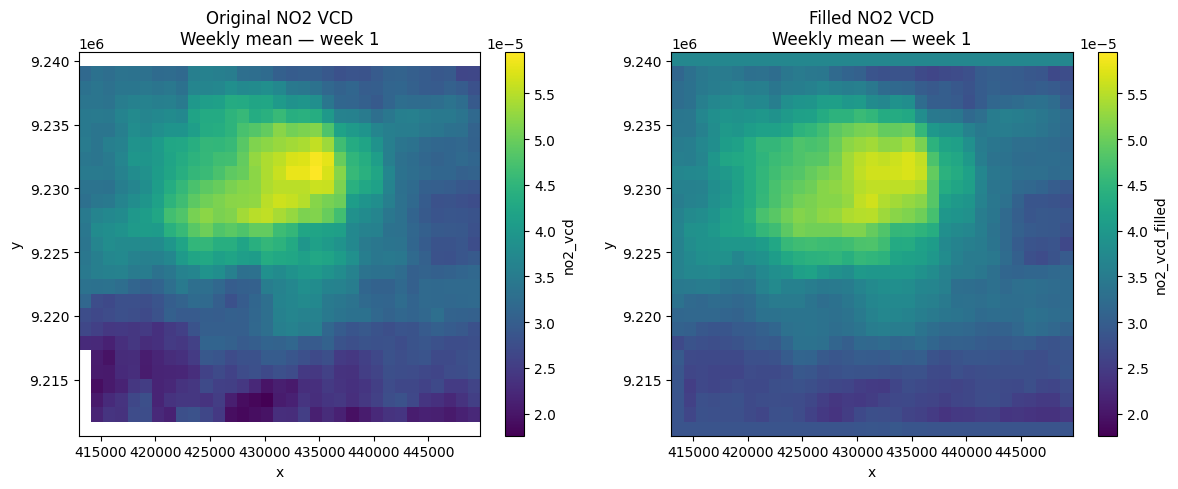

In [93]:
# filter month
orig_w1   = ds_rfv2['no2_vcd'].where(ds_rfv2['month'] == 6).mean(dim='time')
filled_w1 = ds_rfv2['no2_vcd_filled'].where(ds_rfv2['month'] == 6).mean(dim='time')

# globl scale color
vmin = float(np.nanmin([orig_w1.min(), filled_w1.min()]))
vmax = float(np.nanmax([orig_w1.max(), filled_w1.max()]))

# plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

orig_w1.plot(ax=axes[0], cmap='viridis', vmin=vmin, vmax=vmax)
axes[0].set_title('Original NO2 VCD\nWeekly mean — week 1')

filled_w1.plot(ax=axes[1], cmap='viridis', vmin=vmin, vmax=vmax)
axes[1].set_title('Filled NO2 VCD\nWeekly mean — week 1')

plt.tight_layout()
plt.show()


# **Model RFSTK Gap-Filling V.3**

Total data   : 161271
Non-NaN (train gap): 89232
NaN (to fill)      : 72039
OOB clean (89232 sample)

=== RF Gap Model ===
  OOB R²              : 0.8824
  Mean |OOB error|    : 3.8966e-06

Total unique dates to fill: 181
  Processed 20/181 dates...
  Processed 40/181 dates...
  Processed 60/181 dates...
  Processed 80/181 dates...
  Processed 100/181 dates...
  Processed 120/181 dates...
  Processed 140/181 dates...
  Processed 160/181 dates...
  Processed 180/181 dates...

Fallback count : 1778 samples (2.5%)

=== Gap Filling Stats ===
  Filled values min  : 0.0000e+00
  Filled values max  : 1.9550e-04
  Filled values mean : 3.5218e-05
  Filled values std  : 1.1503e-05
  Remaining NaN      : 0


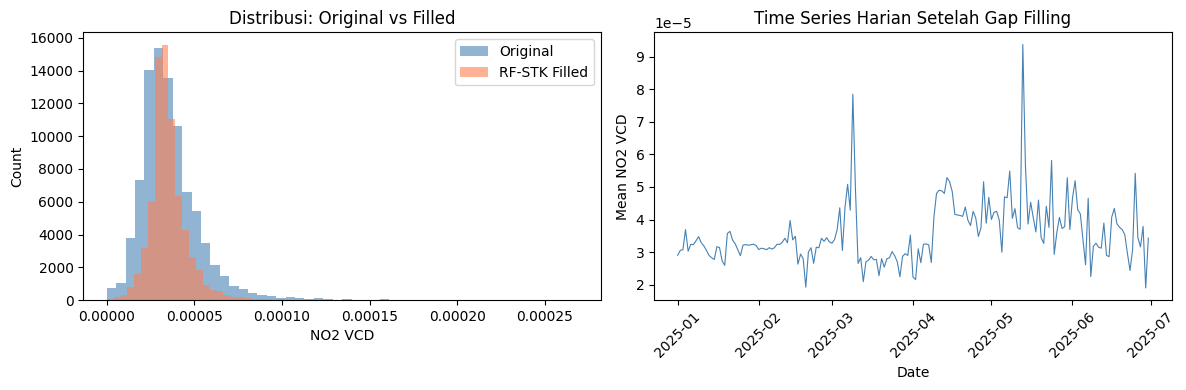

In [94]:
df_gap_rfstk = df_temporalgap.copy()
mask_nan     = df_gap_rfstk['no2_vcd_filled'].isna() #nan

print(f"Total data   : {len(df_gap_rfstk)}")
print(f"Non-NaN (train gap): {(~mask_nan).sum()}")
print(f"NaN (to fill)      : {mask_nan.sum()}")

# Step 1: Fit RF to all non-NaN data
X_train_gapv3 = df_gap_rfstk[~mask_nan][selected_features_v2].fillna(
    df_gap_rfstk[~mask_nan][selected_features_v2].median()
)
y_train_gapv3 = df_gap_rfstk[~mask_nan]['no2_vcd_filled'].values

X_test_gapv3      = df_gap_rfstk[mask_nan][selected_features_v2].fillna(
    df_gap_rfstk[~mask_nan][selected_features_v2].median()  # pakai median train
)

gap_rfv3 = RandomForestRegressor(
    **random_searchv2.best_params_,
    oob_score=True, n_jobs=-1, random_state=42
)
gap_rfv3.fit(X_train_gapv3, y_train_gapv3)

oob_pred_gap = gap_rfv3.oob_prediction_
nan_count = np.isnan(oob_pred_gap).sum()
if nan_count > 0:
    print(f" {nan_count} NaN OOB → fill in-bag")
    oob_pred_gap = np.where(
        np.isnan(oob_pred_gap),
        gap_rfv3.predict(X_train_gapv3),
        oob_pred_gap
    )
else:
    print(f"OOB clean ({len(oob_pred_gap)} sample)")

oob_gap     = y_train_gapv3 - oob_pred_gap  #used oob_pred_gap
oob_std_gap = oob_gap.std()

print(f"\n=== RF Gap Model ===")
print(f"  OOB R²              : {gap_rfv3.oob_score_:.4f}")
print(f"  Mean |OOB error|    : {np.abs(oob_gap).mean():.4e}")

# Step 2: RF baseline prediction for NaN locations
y_rf_gap_base = gap_rfv3.predict(X_test_gapv3)

# Step 3: Daily Kriging correction OOB error to NaN locations
train_gap_df         = df_gap_rfstk[~mask_nan].copy().reset_index(drop=True)
test_gap_df          = df_gap_rfstk[mask_nan].copy().reset_index(drop=True)
train_gap_df['oob_error'] = oob_gap

y_rfstk_gap = np.full(len(test_gap_df), np.nan)
fill_dates  = test_gap_df['time'].unique()

print(f"\nTotal unique dates to fill: {len(fill_dates)}")
fallback_count = 0

for i, date in enumerate(sorted(fill_dates)):
    tr_day   = train_gap_df[train_gap_df['time'] == date]
    fill_day = test_gap_df[test_gap_df['time'] == date]
    fill_idx = fill_day.index.values

    if len(tr_day) < 4:
        # fallback: if not enough kriging, use RF
        y_rfstk_gap[fill_idx] = y_rf_gap_base[fill_idx]
        fallback_count += len(fill_idx)
        continue

    try:
        ok_gap = OrdinaryKriging(
            tr_day['x'].values,
            tr_day['y'].values,
            tr_day['oob_error'].values,
            variogram_model='spherical',
            verbose=False,
            enable_plotting=False,
            nlags=15,
            weight=True
        )

        err_interp, _ = ok_gap.execute(
            'points',
            fill_day['x'].values,
            fill_day['y'].values
        )

        err_clip = np.clip(err_interp.data, -3*oob_std_gap, 3*oob_std_gap)
        y_rfstk_gap[fill_idx] = np.clip(
            y_rf_gap_base[fill_idx] + err_clip, 0, None #rfstk
        )

    except Exception as e:
        y_rfstk_gap[fill_idx] = y_rf_gap_base[fill_idx]
        fallback_count += len(fill_idx)
        print(f"  Date {date} fallback: {e}")

    if (i+1) % 20 == 0:
        print(f"  Processed {i+1}/{len(fill_dates)} dates...")

# Handle NaN
nan_remain = np.isnan(y_rfstk_gap)
y_rfstk_gap[nan_remain] = y_rf_gap_base[nan_remain]
fallback_count += nan_remain.sum()

print(f"\nFallback count : {fallback_count} samples ({fallback_count/len(test_gap_df)*100:.1f}%)")

# Step 4: Input result to dataframe
df_gap_rfstk.loc[mask_nan, 'no2_vcd_filled'] = y_rfstk_gap

print(f"\n=== Gap Filling Stats ===")
print(f"  Filled values min  : {y_rfstk_gap.min():.4e}")
print(f"  Filled values max  : {y_rfstk_gap.max():.4e}")
print(f"  Filled values mean : {y_rfstk_gap.mean():.4e}")
print(f"  Filled values std  : {y_rfstk_gap.std():.4e}")
print(f"  Remaining NaN      : {df_gap_rfstk['no2_vcd_filled'].isna().sum()}")

# Step 5: Distribution plot
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Real value and prediction value distribution
axes[0].hist(df_gap_rfstk[~mask_nan]['no2_vcd_filled'],
             bins=50, alpha=0.6, label='Original', color='steelblue')
axes[0].hist(y_rfstk_gap, bins=50, alpha=0.6,
             label='RF-STK Filled', color='coral')
axes[0].set_xlabel('NO2 VCD')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribusi: Original vs Filled')
axes[0].legend()

# Time series daily average
df_gap_rfstk['date'] = pd.to_datetime(df_gap_rfstk['time'])
daily_mean = df_gap_rfstk.groupby('date')['no2_vcd_filled'].mean()
axes[1].plot(daily_mean.index, daily_mean.values,
             linewidth=0.8, color='steelblue')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Mean NO2 VCD')
axes[1].set_title('Time Series Harian Setelah Gap Filling')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# **Analisis Spike**

In [95]:
# Spike check whether its from original or gapfilled
daily = df_gap_rfstk.groupby('time').agg(
    mean_all   = ('no2_vcd_filled', 'mean'),
    mean_orig  = ('no2_vcd_filled', lambda x: x[df_gap_rfstk.loc[x.index, 'no2_vcd'].notna()].mean()),
    mean_filled= ('no2_vcd_filled', lambda x: x[df_gap_rfstk.loc[x.index, 'no2_vcd'].isna()].mean()),
    n_filled   = ('no2_vcd', lambda x: x.isna().sum())
).reset_index()

# show date with spike
spike_threshold = daily['mean_all'].mean() + 2 * daily['mean_all'].std()
print("Date spike:")
print(daily[daily['mean_all'] > spike_threshold][['time', 'mean_all', 'mean_orig', 'mean_filled', 'n_filled']])

Date spike:
          time  mean_all  mean_orig  mean_filled  n_filled
67  2025-03-09  0.000078   0.000083     0.000063       191
127 2025-05-08  0.000055   0.000055     0.000055       628
132 2025-05-13  0.000094   0.000105     0.000085       514
133 2025-05-14  0.000057   0.000057     0.000057       321
143 2025-05-24  0.000058   0.000064     0.000054       515


In [96]:
# Checkk date spike
daily_mean = df_gap_rfstk.groupby('date')['no2_vcd_filled'].mean()

# outlier identification
threshold = daily_mean.mean() + 2 * daily_mean.std()
spike_dates = daily_mean[daily_mean > threshold]
print(spike_dates)

for date in spike_dates.index:
    date_str = date.strftime('%Y-%m-%d')
    orig = df_gap_rfstk[
        (df_gap_rfstk['date'] == date) & (~mask_nan)
    ]['no2_vcd_filled']
    filled = df_gap_rfstk[
        (df_gap_rfstk['date'] == date) & (mask_nan)
    ]['no2_vcd_filled']

    print(f"\nDate: {date_str}")
    print(f"  Original mean  : {orig.mean():.4e} (n={len(orig)})")
    print(f"  Filled mean    : {filled.mean():.4e} (n={len(filled)})")
    print(f"  Source of spike: {'ORIGINAL' if orig.mean() > filled.mean() else 'FILLED'}")

date
2025-03-09    0.000078
2025-05-08    0.000055
2025-05-13    0.000094
2025-05-14    0.000057
2025-05-24    0.000058
Name: no2_vcd_filled, dtype: float64

Date: 2025-03-09
  Original mean  : 8.2557e-05 (n=700)
  Filled mean    : 6.3493e-05 (n=191)
  Source of spike: ORIGINAL

Date: 2025-05-08
  Original mean  : 5.4572e-05 (n=263)
  Filled mean    : 5.5006e-05 (n=628)
  Source of spike: FILLED

Date: 2025-05-13
  Original mean  : 1.0546e-04 (n=377)
  Filled mean    : 8.5166e-05 (n=514)
  Source of spike: ORIGINAL

Date: 2025-05-14
  Original mean  : 5.6661e-05 (n=570)
  Filled mean    : 5.6577e-05 (n=321)
  Source of spike: ORIGINAL

Date: 2025-05-24
  Original mean  : 6.4239e-05 (n=376)
  Filled mean    : 5.3679e-05 (n=515)
  Source of spike: ORIGINAL


In [97]:
print(df_gap_rfstk.columns.tolist())

['time', 'pixel', 'band', 'spatial_ref', 'no2_vcd', 'tp', 'h', 'pb', 'ps', 'sr', 'temp', 'ws', 'wd', 'dem', 'pop', 'industry', 'landcover', 'no2_cams', 'y', 'x', 'month', 'day', 'dayofyear', 'week', 'month_sin', 'month_cos', 'dayofyear_sin', 'dayofyear_cos', 'y_x_interaction', 'y_squared', 'x_squared', 'time_ordinal', 'no2_cams_filled', 'no2_cams_climatology', 'no2_cams_anomaly', 'lc_2', 'lc_8', 'lc_9', 'lc_11', 'lc_12', 'lc_13', 'lc_14', 'lc_16', 'lc_17', 'lc_255', 'missing_type', 'streak_len', 'category', 'no2_vcd_filled', 'spatial_mean', 'anomaly', 'anomaly_smooth', 'anomaly_final', 'scaling_factor', 'mean_scaling_weekly', 'no2_lag_1', 'no2_lag_2', 'no2_lag_3', 'no2_lag_7', 'no2_roll7', 'date']


In [98]:
# Check meteorology pattern
spike_dates_list = ['2025-03-09', '2025-05-13', '2025-05-14', '2025-05-24']

for d in spike_dates_list:
    day_data = df_gap_rfstk[df_gap_rfstk['date'] == d]
    print(f"\n📅 {d}")
    # Check meteorology feature
    for col in ['ws', 'h', 
                'tp', 'pb', 'ps', 'sr', 'temp', 'wd']:
        if col in day_data.columns:
            print(f"  {col}: {day_data[col].mean():.4f}")


📅 2025-03-09
  ws: 1.1604
  h: 89.4022
  tp: 4.7354
  pb: 300.9960
  ps: 989.6426
  sr: 127.9543
  temp: 25.3372
  wd: 41.3168

📅 2025-05-13
  ws: 1.6306
  h: 86.6134
  tp: 1.1289
  pb: 354.5847
  ps: 988.9977
  sr: 232.7411
  temp: 26.3335
  wd: 184.1178

📅 2025-05-14
  ws: 1.4459
  h: 86.2854
  tp: 0.7858
  pb: 341.8205
  ps: 989.7026
  sr: 233.7334
  temp: 26.5503
  wd: 336.1764

📅 2025-05-24
  ws: 1.7889
  h: 87.1090
  tp: 1.0973
  pb: 260.3917
  ps: 987.6562
  sr: 142.9376
  temp: 26.4063
  wd: 164.4464


"Analisis kondisi meteorologi pada keempat tanggal anomali menunjukkan karakteristik yang konsisten berupa kecepatan angin sangat rendah (1,16–1,79 m/s), kelembaban relatif tinggi (86–89%), dan curah hujan minimal (<5 mm). Kecepatan angin di bawah 2 m/s mengindikasikan kondisi calm wind yang menghambat dispersi horizontal NO2 dari sumber emisi. Meskipun kelembaban tinggi, minimnya presipitasi aktual menyebabkan tidak terjadinya wet deposition yang merupakan mekanisme pembersihan NO2 utama di atmosfer. Spike tertinggi pada 2025-05-13 (1,05×10⁻⁴ mol/m²) juga bertepatan dengan radiasi surya tertinggi (232,74 W/m²), yang mengindikasikan kondisi langit lebih cerah sehingga meningkatkan kualitas retrieval TROPOMI sekaligus meminimalkan proses scavenging atmosfer."

# **Visualisasi**

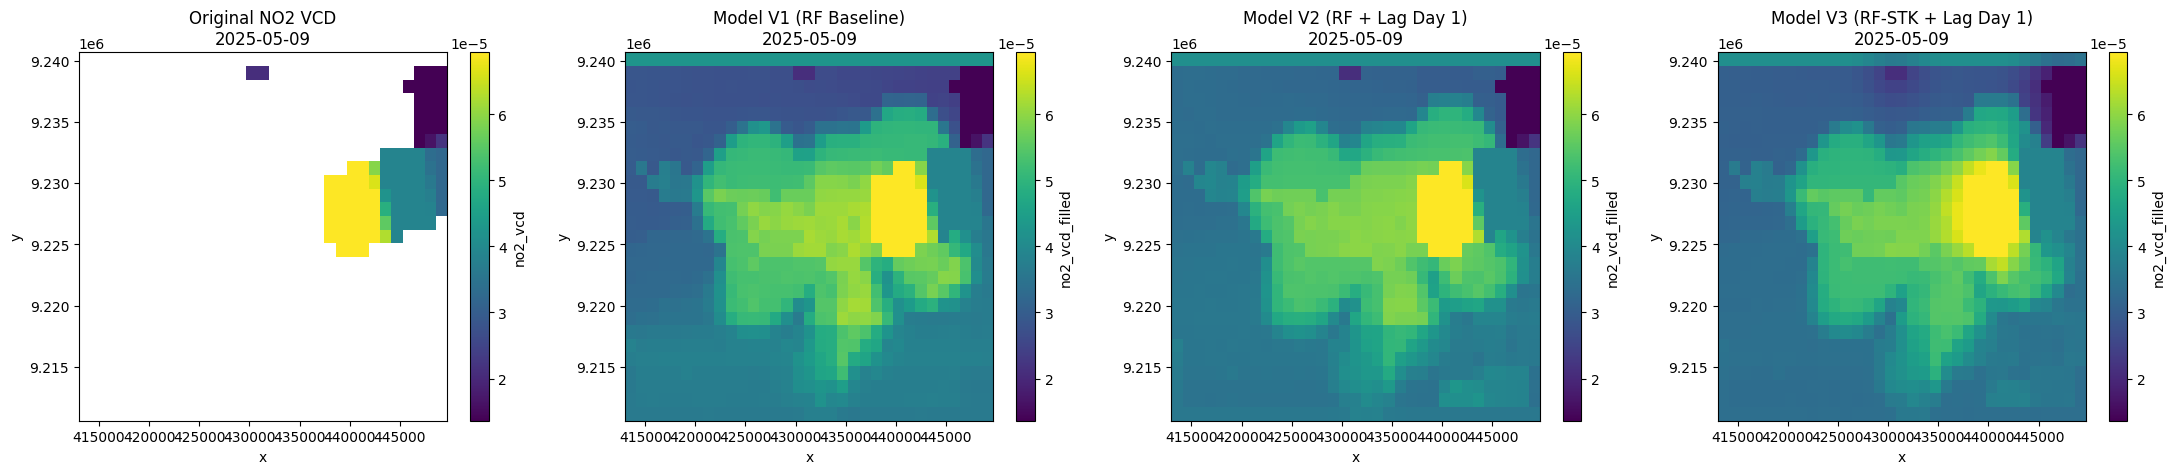

In [100]:
# choose time
t = 128

# Model V1
ds_v1 = df_gap_rfv1.set_index(['time', 'y', 'x']).to_xarray()
tanggal_v1 = pd.to_datetime(ds_v1.time.values[t]).strftime("%Y-%m-%d")
# Model V2
ds_v2 = df_gap_rfv2.set_index(['time', 'y', 'x']).to_xarray()
tanggal_v2 = pd.to_datetime(ds_v2.time.values[t]).strftime("%Y-%m-%d")
# Model V3
ds_v3 = df_gap_rfstk.set_index(['time', 'y', 'x']).to_xarray()
tanggal_v3 = pd.to_datetime(ds_v3.time.values[t]).strftime("%Y-%m-%d")


# get data slice
orig = ds_v1['no2_vcd'].isel(time=t)
filled_v1 = ds_v1['no2_vcd_filled'].isel(time=t)
filled_v2 = ds_v2['no2_vcd_filled'].isel(time=t)
filled_v3 = ds_v3['no2_vcd_filled'].isel(time=t)

# degine global scale color
vmin = np.nanmin([orig.min().values, filled_v3.min().values])
vmax = np.nanmax([orig.max().values, filled_v3.max().values])

# Plot
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

orig.plot(
    ax=axes[0],
    cmap='viridis',
    vmin=vmin,
    vmax=vmax
)
axes[0].set_title(f'Original NO2 VCD\n{tanggal_v1}')

filled_v1.plot(
    ax=axes[1],
    cmap='viridis',
    vmin=vmin,
    vmax=vmax
)
axes[1].set_title(f'Model V1 (RF Baseline)\n{tanggal_v1}')

filled_v2.plot(
    ax=axes[2],
    cmap='viridis',
    vmin=vmin,
    vmax=vmax
)
axes[2].set_title(f'Model V2 (RF + Lag Day 1)\n{tanggal_v2}')

filled_v3.plot(
    ax=axes[3],
    cmap='viridis',
    vmin=vmin,
    vmax=vmax
)
axes[3].set_title(f'Model V3 (RF-STK + Lag Day 1)\n{tanggal_v3}')

plt.tight_layout()
plt.show()


In [101]:
# Cek versi library
import sklearn
import numpy as np
import pandas as pd
import xarray as xr

print("=== VERSI LIBRARY ===")
print("sklearn:", sklearn.__version__)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("xarray:", xr.__version__)

print("\n=== DATA ===")
print("Shape no2_vcd:", no2_vcd.shape)
print("Jumlah file tif:", len(no2_vcd_files))

print("\n=== TRAINING ===")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Selected features:", selected_features)
print("Jumlah NaN diisi:", mask_nan.sum())

print("\n=== HASIL RF ===")
print("best_params:", random_search.best_params_)
print("y_gap_rfv1 mean:", y_gap_rfv1.mean())
print("y_gap_rfv1 min:", y_gap_rfv1.min())
print("y_gap_rfv1 max:", y_gap_rfv1.max())

=== VERSI LIBRARY ===
sklearn: 1.7.2
numpy: 2.3.2
pandas: 2.3.1
xarray: 2026.2.0

=== DATA ===
Shape no2_vcd: (181, 27, 33)
Jumlah file tif: 181

=== TRAINING ===
X_train shape: (74602, 16)
X_test shape: (14358, 16)
Selected features: ['industry', 'ws', 'lc_13', 'week', 'pop', 'time_ordinal', 'dayofyear_cos', 'dayofyear', 'pb', 'wd', 'sr', 'y_squared', 'temp', 'lc_17', 'tp', 'dayofyear_sin']
Jumlah NaN diisi: 72039

=== HASIL RF ===
best_params: {'n_estimators': 200, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'max_depth': 15}
y_gap_rfv1 mean: 3.544066517697061e-05
y_gap_rfv1 min: 1.9300639595682864e-06
y_gap_rfv1 max: 0.00018282129041509912


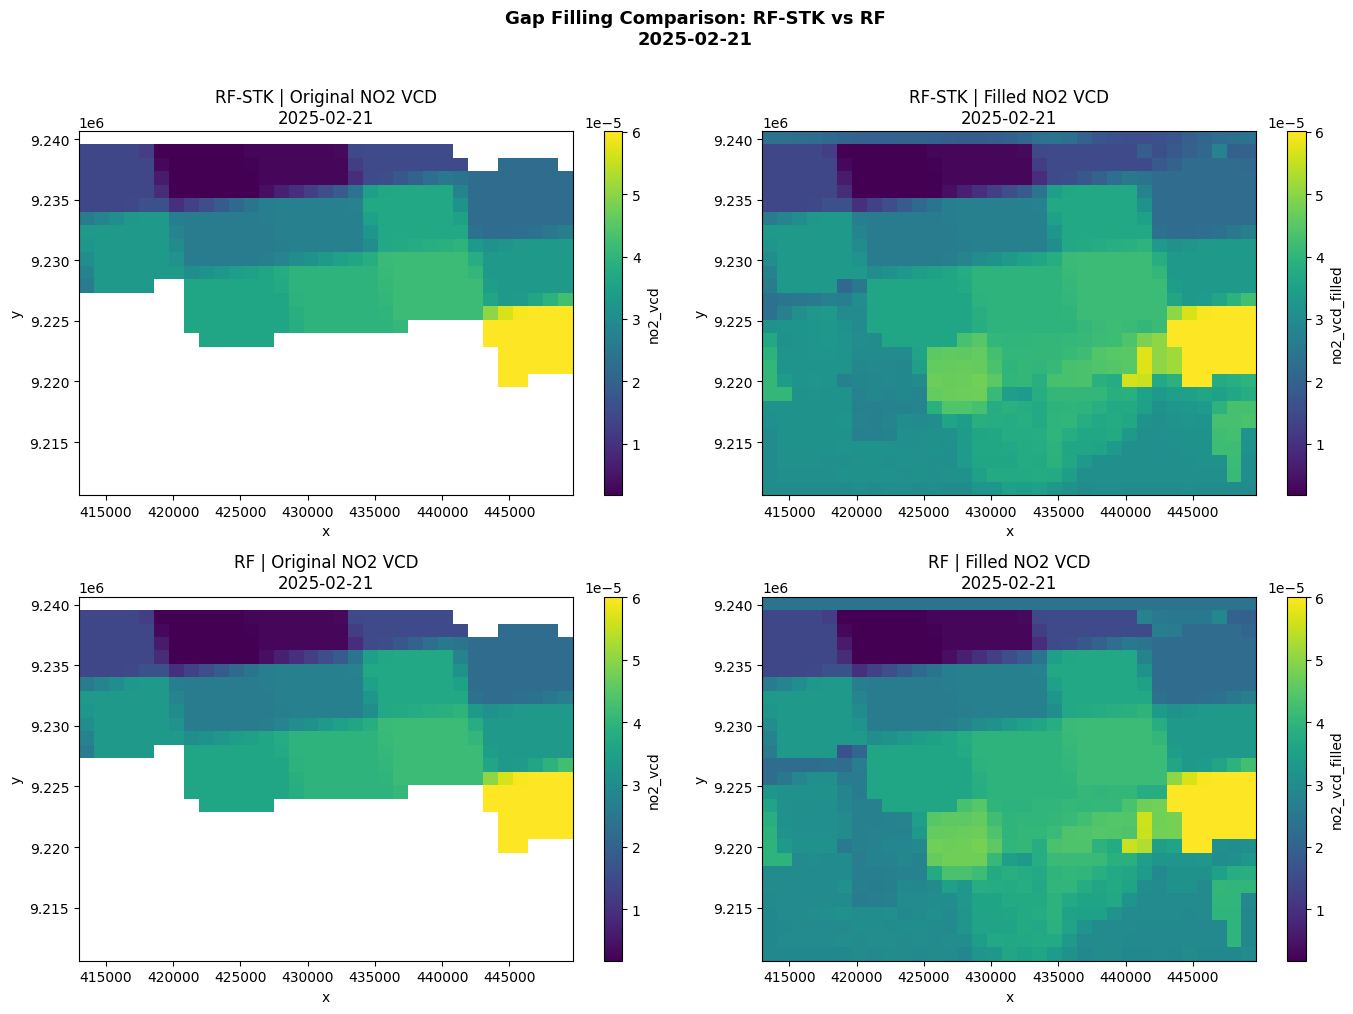

In [129]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# set time to datetime
df_gap_rfstk['time'] = pd.to_datetime(df_gap_rfstk['time'])

# Convert to xarray
ds_rfstk = df_gap_rfstk.set_index(['time', 'y', 'x']).to_xarray()
ds_rfv2  = df_gap_rfv2.set_index(['time', 'y', 'x']).to_xarray()

# choose time
t      = 51
tanggal = pd.to_datetime(ds_rfstk.time.values[t]).strftime("%Y-%m-%d")

# get data slice
orig_rfstk   = ds_rfstk['no2_vcd'].isel(time=t)
filled_rfstk = ds_rfstk['no2_vcd_filled'].isel(time=t)
orig_rfv2    = ds_rfv2['no2_vcd'].isel(time=t)
filled_rfv2  = ds_rfv2['no2_vcd_filled'].isel(time=t)

# global scale color
vmin = np.nanmin([orig_rfstk.values, filled_rfstk.values,
                  orig_rfv2.values,  filled_rfv2.values])
vmax = np.nanmax([orig_rfstk.values, filled_rfstk.values,
                  orig_rfv2.values,  filled_rfv2.values])

# Plot 2x2
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

orig_rfstk.plot(ax=axes[0,0], cmap='viridis', vmin=vmin, vmax=vmax)
axes[0,0].set_title(f'RF-STK | Original NO2 VCD\n{tanggal}')

filled_rfstk.plot(ax=axes[0,1], cmap='viridis', vmin=vmin, vmax=vmax)
axes[0,1].set_title(f'RF-STK | Filled NO2 VCD\n{tanggal}')

orig_rfv2.plot(ax=axes[1,0], cmap='viridis', vmin=vmin, vmax=vmax)
axes[1,0].set_title(f'RF | Original NO2 VCD\n{tanggal}')

filled_rfv2.plot(ax=axes[1,1], cmap='viridis', vmin=vmin, vmax=vmax)
axes[1,1].set_title(f'RF | Filled NO2 VCD\n{tanggal}')

plt.suptitle(f'Gap Filling Comparison: RF-STK vs RF\n{tanggal}', 
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

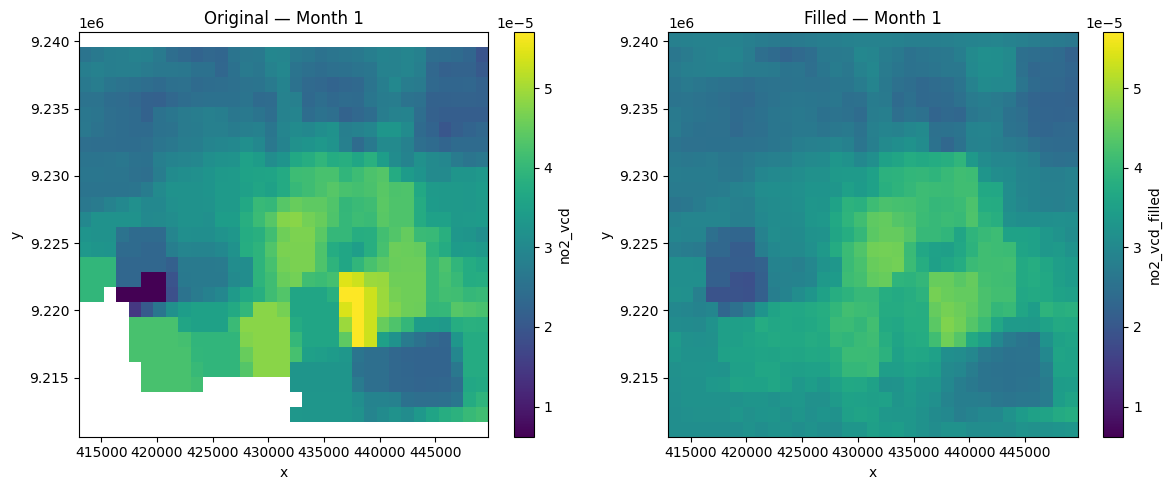

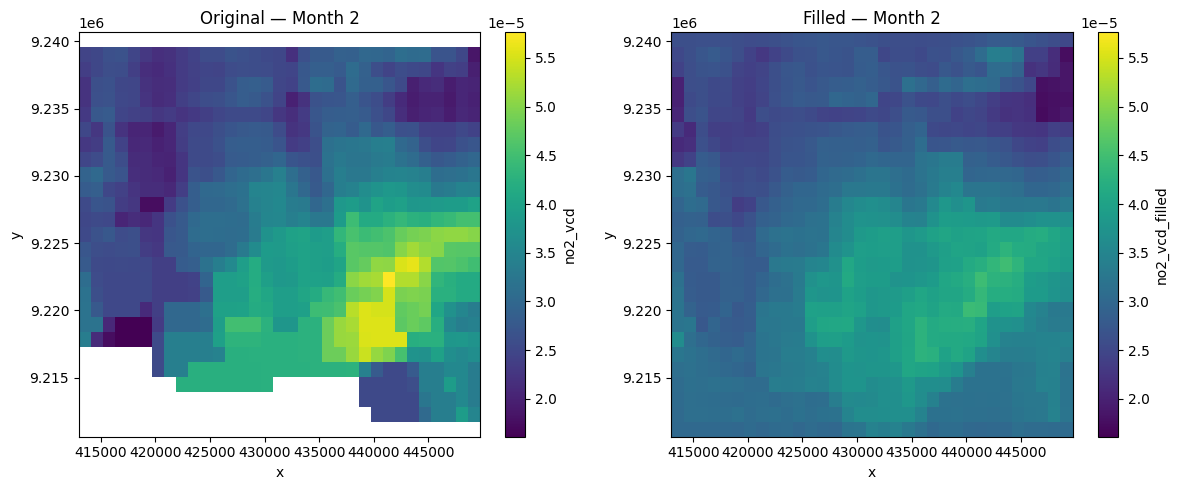

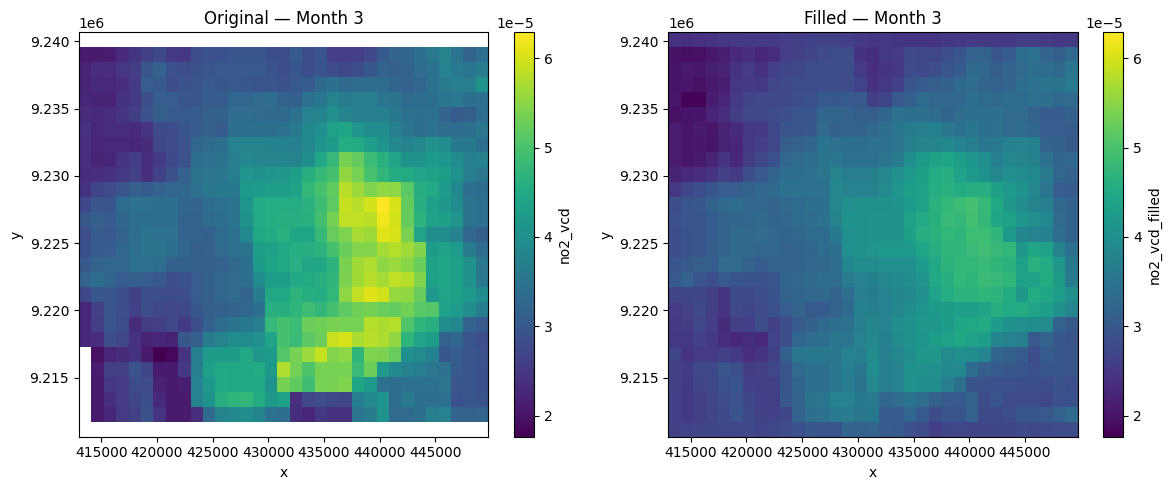

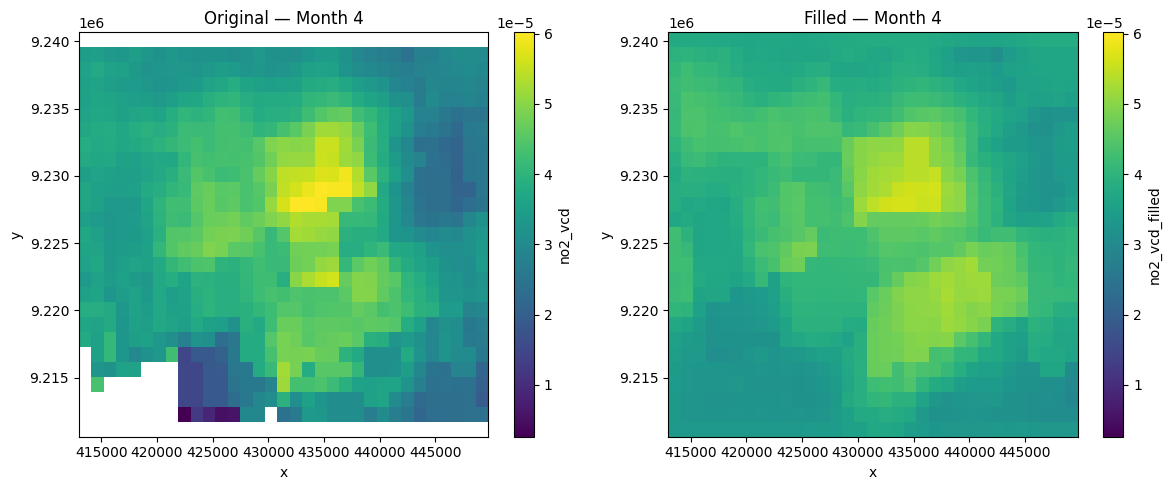

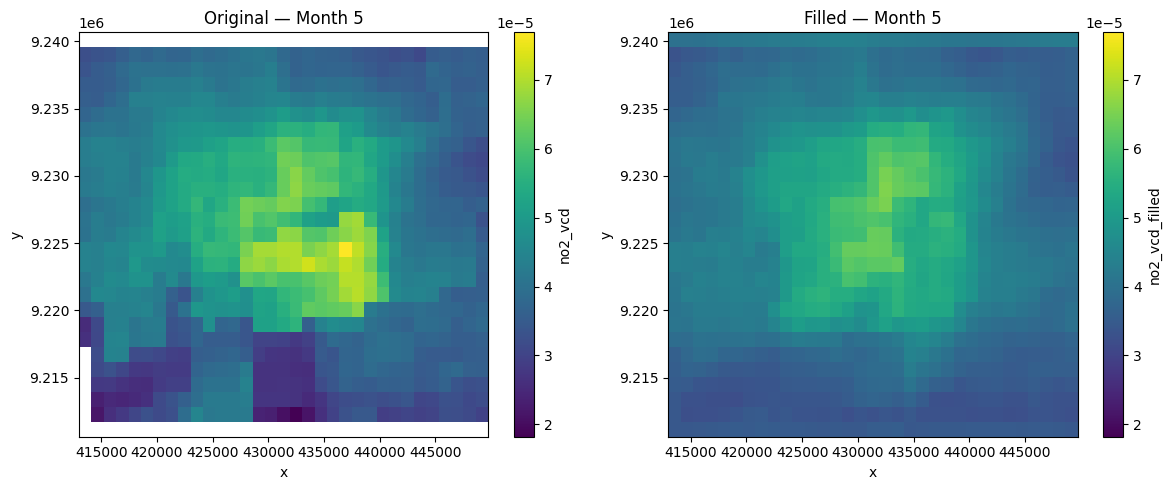

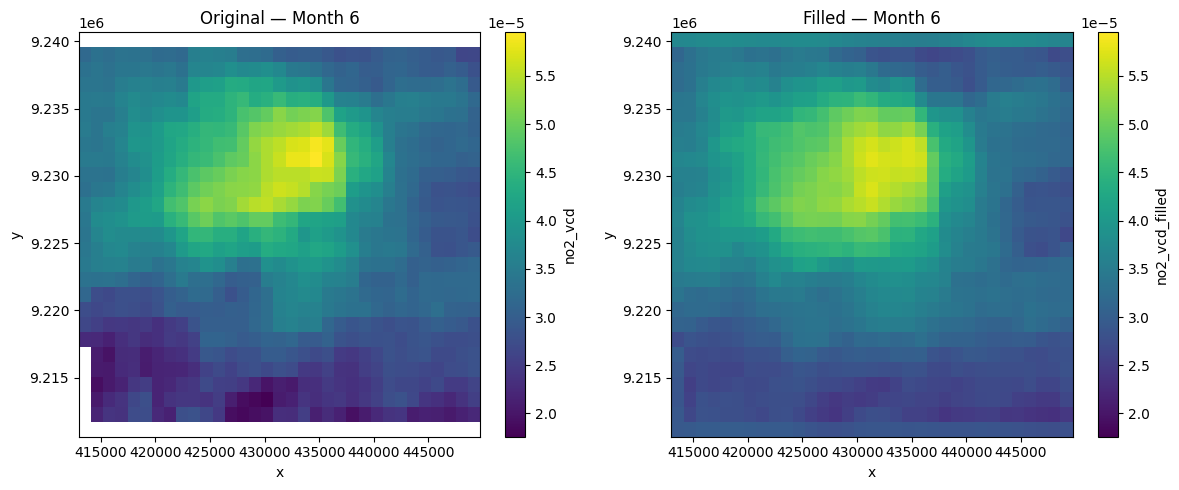

In [103]:
orig_monthly = ds_v3['no2_vcd'].groupby('time.month').mean()
filled_monthly = ds_v3['no2_vcd_filled'].groupby('time.month').mean()

import matplotlib.pyplot as plt
import numpy as np

for m in orig_monthly['month'].values:
    orig = orig_monthly.sel(month=m)
    filled = filled_monthly.sel(month=m)

    vmin = float(np.nanmin([orig.min(), filled.min()]))
    vmax = float(np.nanmax([orig.max(), filled.max()]))

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    orig.plot(ax=axes[0], cmap='viridis', vmin=vmin, vmax=vmax)
    axes[0].set_title(f'Original — Month {m}')

    filled.plot(ax=axes[1], cmap='viridis', vmin=vmin, vmax=vmax)
    axes[1].set_title(f'Filled — Month {m}')

    plt.tight_layout()
    plt.show()


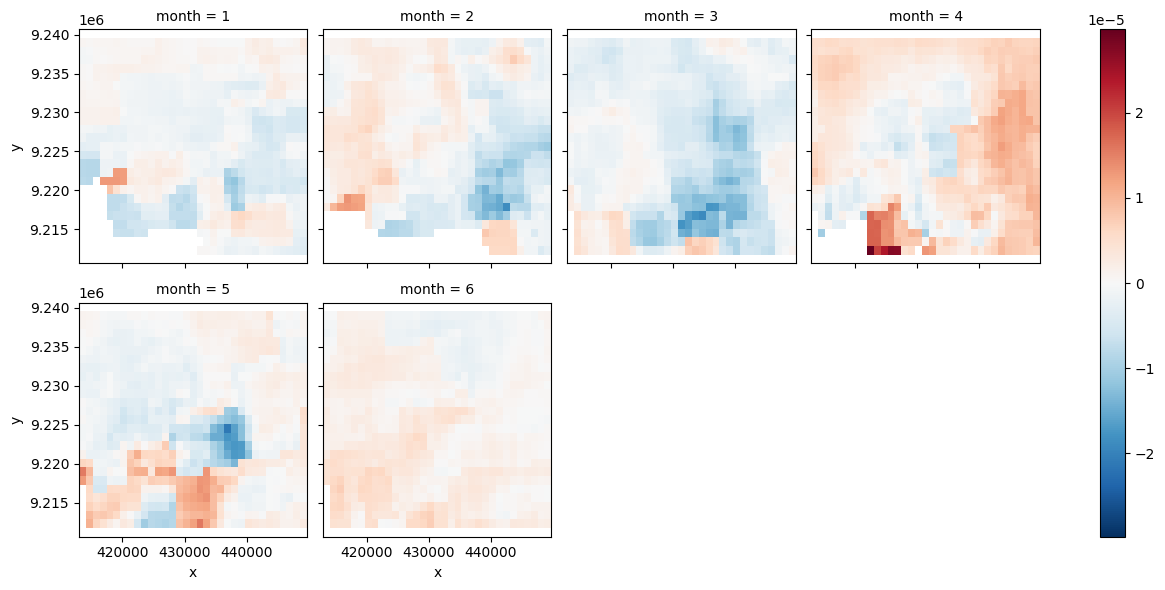

In [104]:
bias = filled_monthly - orig_monthly
bias.plot(col='month', col_wrap=4)

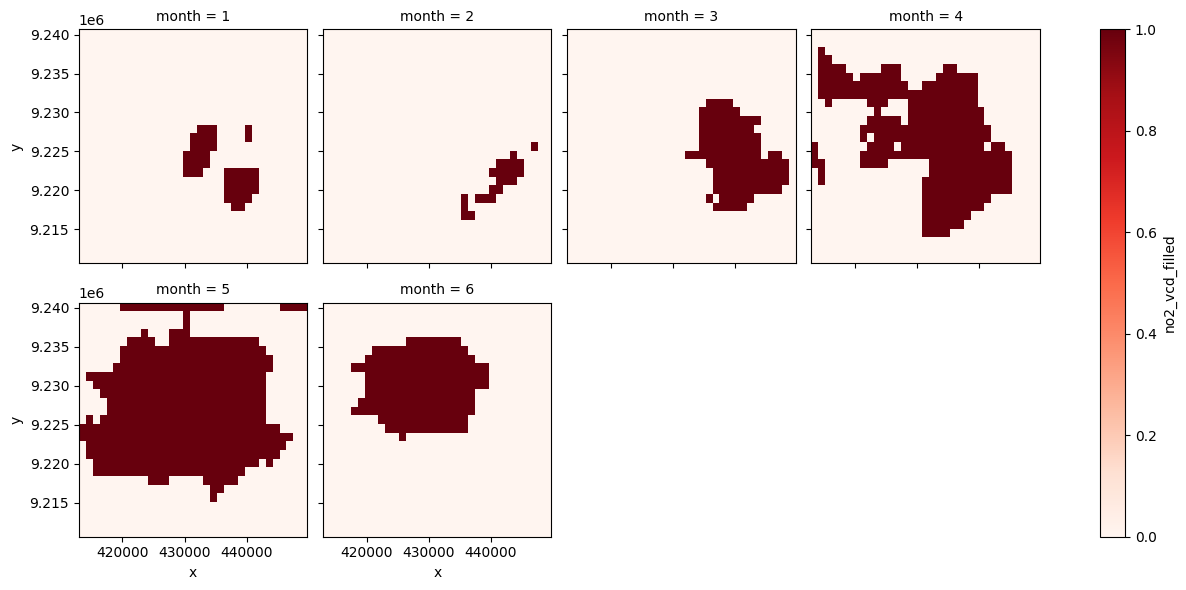

In [105]:
# Hitung threshold global
threshold = float(filled_monthly.quantile(0.8))  # median sebagai threshold

hotspot = filled_monthly > threshold

hotspot.plot(
    col='month',
    col_wrap=4,
    cmap='Reds'
)


(array([  75.,  609., 1117., 1294., 1106.,  607.,  267.,  184.,   60.,
          27.]),
 array([1.73375421e-05, 2.21514766e-05, 2.69654111e-05, 3.17793456e-05,
        3.65932800e-05, 4.14072145e-05, 4.62211490e-05, 5.10350835e-05,
        5.58490180e-05, 6.06629525e-05, 6.54768869e-05]),
 <BarContainer object of 10 artists>)

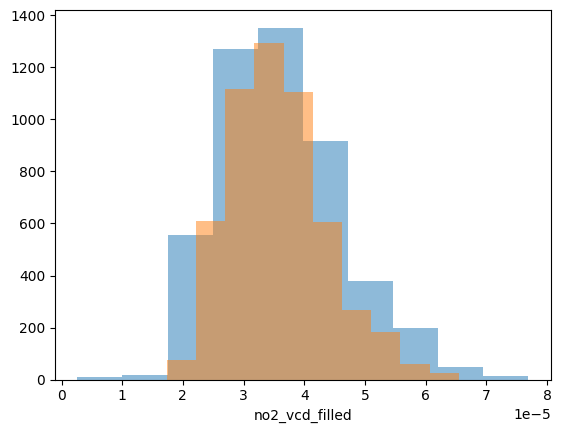

In [106]:
orig_monthly.plot.hist(alpha=0.5)
filled_monthly.plot.hist(alpha=0.5)

# **Model Comparison**

In [107]:
print(f"\n{'='*150}")
print(f"  MODEL COMPARISON")
print(f"{'='*150}")
print(f"  {'Metric':<10} {'v1 (baseline)':>16}      {'v2 (+lag)':>18} {'Delta':>10} {'v3 (lag1-7)':>18} {'Delta v3':>10}")
print(f"{'-'*149}")
for m in ['R2','Slope','RMSE','MAE','RPE']:
    v1 = model_df_v1[m].mean()
    v2 = model_df_v2[m].mean()
    v3 = model_df_v3[m].mean()
    delta = v2 - v1
    delta_v3 = v3 - v1
    sign = '▲' if (m == 'R2' and delta > 0) or (m != 'R2' and delta < 0) else '▼'
    print(f"  {m:<10} {v1:>16.4e} {v2:>18.4e} {sign} {abs(delta):.4e} {v3:>18.4e} {sign} {abs(delta_v3):.4e}")


  MODEL COMPARISON
  Metric        v1 (baseline)               v2 (+lag)      Delta        v3 (lag1-7)   Delta v3
-----------------------------------------------------------------------------------------------------------------------------------------------------
  R2               5.8518e-01         7.4482e-01 ▲ 1.5964e-01         8.1699e-01 ▲ 2.3181e-01
  Slope            9.2606e-01         1.0714e+00 ▼ 1.4533e-01         1.0333e+00 ▼ 1.0722e-01
  RMSE             1.1084e-05         8.2794e-06 ▲ 2.8046e-06         7.0114e-06 ▲ 4.0726e-06
  MAE              8.2626e-06         5.4253e-06 ▲ 2.8373e-06         4.3695e-06 ▲ 3.8931e-06
  RPE              2.2190e+01         1.5997e+01 ▲ 6.1935e+00         1.2110e+01 ▲ 1.0081e+01


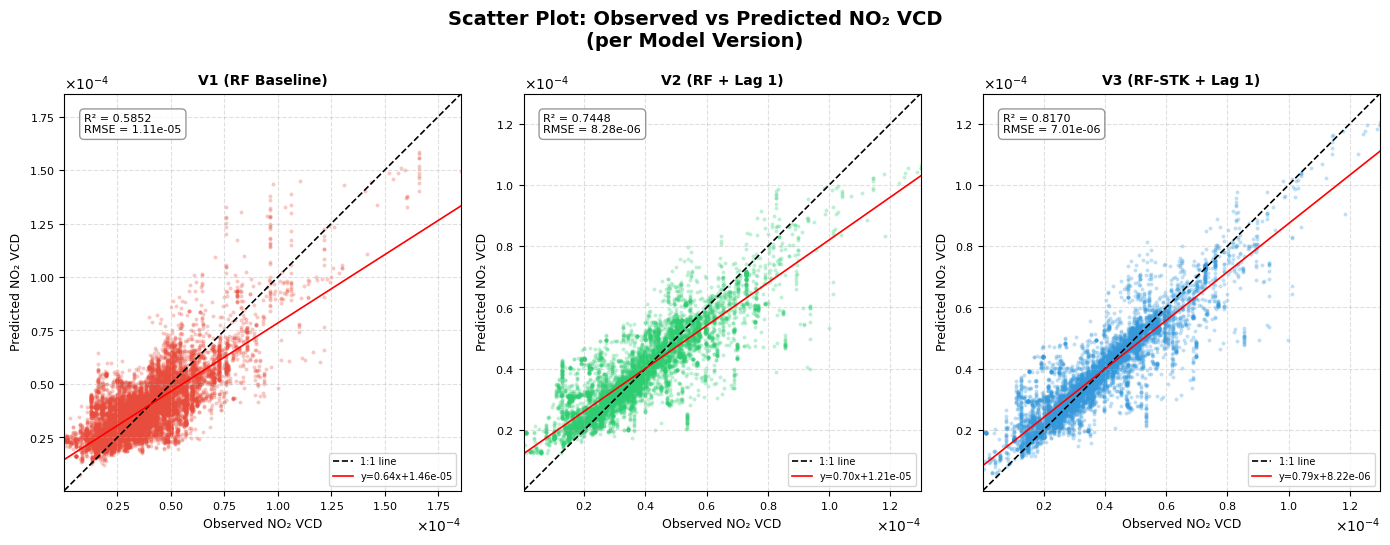

Save: scatter_all_versions.png


In [110]:
# Scatter Plot All Models
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from sklearn.metrics import r2_score

# ── Data per versi ────────────────────────────────────────────
versions = [
    {'label': 'V1 (RF Baseline)',        'y_true': y_test,    'y_pred': y_pred_test,         'color': '#e74c3c'},
    {'label': 'V2 (RF + Lag 1)',           'y_true': y_test_v2, 'y_pred': y_pred_test_v2,   'color': '#2ecc71'},
    {'label': 'V3 (RF-STK + Lag 1)',          'y_true': y_test_v2, 'y_pred': y_rfstk_all,    'color': '#3498db'},
]

# ── Figure ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Scatter Plot: Observed vs Predicted NO₂ VCD\n(per Model Version)',
             fontsize=14, fontweight='bold', y=1.02)

for ax, v in zip(axes, versions):
    y_true = np.array(v['y_true']).flatten()
    y_pred = np.array(v['y_pred']).flatten()
    r2     = r2_score(y_true, y_pred)
    rmse   = np.sqrt(np.mean((y_true - y_pred) ** 2))

    # Scatter
    ax.scatter(y_true, y_pred,
               alpha=0.3, s=8,
               color=v['color'], linewidths=0)

    # 1:1 line
    lims = [min(y_true.min(), y_pred.min()),
            max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, 'k--', linewidth=1.2, label='1:1 line')

    # Regression line
    m, b   = np.polyfit(y_true, y_pred, 1)
    x_line = np.linspace(lims[0], lims[1], 200)
    ax.plot(x_line, m * x_line + b,
            color='red', linewidth=1.2, label=f'y={m:.2f}x+{b:.2e}')

    # Formatting
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel('Observed NO₂ VCD', fontsize=9)
    ax.set_ylabel('Predicted NO₂ VCD', fontsize=9)
    ax.set_title(v['label'], fontsize=10, fontweight='bold')
    ax.tick_params(labelsize=8)
    ax.yaxis.set_major_formatter(plt.ScalarFormatter(useMathText=True))
    ax.xaxis.set_major_formatter(plt.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(style='sci', axis='both', scilimits=(0, 0))

    # Metrics box
    textstr = f'R² = {r2:.4f}\nRMSE = {rmse:.2e}'
    ax.text(0.05, 0.95, textstr,
            transform=ax.transAxes,
            fontsize=8, verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.4',
                      facecolor='white', alpha=0.8, edgecolor='grey'))

    ax.legend(fontsize=7, loc='lower right')
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('scatter_all_versions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Save: scatter_all_versions.png")

# **Conversion NO2 VCD**


In [114]:
df_conversion = df_gap_rfstk.copy()
df_conversion['time'] = pd.to_datetime(df_conversion['time'])

In [115]:
print(df_conversion['no2_vcd_filled'].describe())

count    161271.000000
mean          0.000036
std           0.000015
min           0.000000
25%           0.000027
50%           0.000033
75%           0.000041
max           0.000269
Name: no2_vcd_filled, dtype: float64


In [116]:
molar_no2 = 46.0055e-3  # kg/mol (bukan g/mol, sesuaikan satuan)
R = 8.314               # J/(mol·K)-gas konstanta
g = 9.81                # m/s²-gravitasi
# NO2_surface (μg/m³) = (VCD × Mw × g × P_surface) / (R × T × BLH)
# Fill berdasarkan waktu atau lokasi terdekat
df_conversion['pb'] = df_conversion.groupby('time')['pb'].transform(
    lambda x: x.fillna(x.mean())
)
df_conversion['ps'] = df_conversion.groupby('time')['ps'].transform(
    lambda x: x.fillna(x.mean())
)
df_conversion['temp'] = df_conversion.groupby('time')['temp'].transform(
    lambda x: x.fillna(x.mean())
)
# Konversi Temperatur ke Kelvin
df_conversion['temp'] = df_conversion['temp'] + 273.15
# Konversi PS hPa ke Pa
df_conversion['ps'] = df_conversion['ps'] * 100
df_conversion['no2_volumetric'] = (df_conversion['no2_vcd_filled'] * 1e6 * molar_no2 * g * df_conversion['ps']) / (R * df_conversion['temp'] * df_conversion['pb'])
print(df_conversion[['no2_vcd_filled', 'pb', 'no2_volumetric']].head())
# Convert ke xarray
ds_conversion = df_conversion.set_index(['time', 'y', 'x']).to_xarray()

   no2_vcd_filled          pb  no2_volumetric
0        0.000029  436.359344        1.191832
1        0.000030  371.186249        1.461628
2        0.000030  351.809875        1.523448
3        0.000035  375.637817        1.684453
4        0.000029  395.992462        1.312856


# **Extracting Station Point Values**

In [117]:
x_extract = 423760.218  # Easting
y_extract = 9217769.675 # Northing

no2_vcd_processed = ds_conversion.sel(x=x_extract, y=y_extract, method='nearest')

print(no2_vcd_processed)

<xarray.Dataset> Size: 62kB
Dimensions:               (time: 181)
Coordinates:
  * time                  (time) datetime64[ns] 1kB 2025-01-01 ... 2025-06-30
    y                     float64 8B 9.218e+06
    x                     float64 8B 4.236e+05
Data variables: (12/59)
    pixel                 (time) int64 1kB 669 669 669 669 ... 669 669 669 669
    band                  (time) int64 1kB 1 1 1 1 1 1 1 1 1 ... 1 1 1 1 1 1 1 1
    spatial_ref           (time) int64 1kB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0
    no2_vcd               (time) float64 1kB nan nan nan ... nan 2.321e-05 nan
    tp                    (time) float64 1kB 0.511 0.852 ... 0.3421 0.03386
    h                     (time) float64 1kB 85.01 88.48 82.49 ... 84.46 83.08
    ...                    ...
    no2_lag_2             (time) float64 1kB nan nan nan nan ... nan nan nan nan
    no2_lag_3             (time) float64 1kB nan nan nan nan ... nan nan nan
    no2_lag_7             (time) float64 1kB nan nan nan ... 

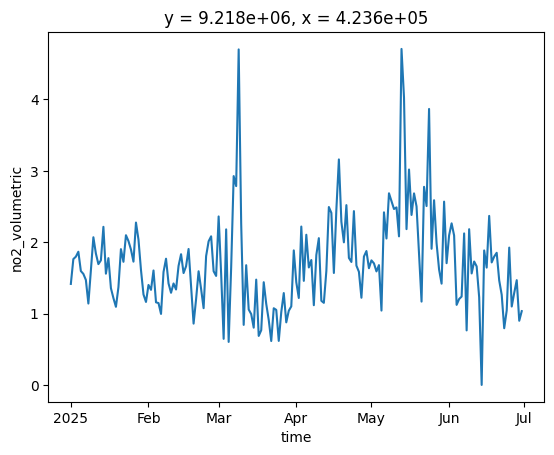

In [118]:
ts = ds_conversion['no2_volumetric'].sel(x=x_extract, y=y_extract, method='nearest')

ts.plot()

In [119]:
# Extract Values and time to Excel
import subprocess
subprocess.run(['pip', 'install', 'openpyxl'])

import os

# Tentukan folder output
output_path = r'D:\Kuliah UNDIP\Semester 7\TA\PENGOLAHAN\github\output'

# Simpan ke folder tersebut
df_extract = no2_vcd_processed.to_dataframe().reset_index()
df_extract.to_excel(os.path.join(output_path, 'no2_vcd_timeseries.xlsx'), index=False)